---
# **FDS Feature Architecture**
---

| Block | Risk Type        | Nature |
| ----- | ---------------- | ------ |
| 1     | Amount           | 거래 강도  |
| 2     | Error            | 실패 행동  |
| 3     | Temporal         | 시간 패턴  |
| 4     | Static           | 구조적 배경 |
| 5     | Card/Channel     | 결제 특성  |
| 6     | MCC              | 업종 리스크 |
| 7     | Merchant Novelty | 상점 변화  |
| 8     | Velocity         | 급격성    |
| 9     | Fraud History    | 과거 전력  |
| 10    | Interaction      | 복합 위험  |


In [1]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.metrics import average_precision_score

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    classification_report
)
pd.set_option("display.max_rows", None)
from statsmodels.tools.sm_exceptions import PerfectSeparationError

LABEL = "fraud"

%matplotlib inline

In [2]:
df = pd.read_parquet("DATA/dataset/train_stage2")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5312525 entries, 0 to 5332978
Data columns (total 53 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   date                      datetime64[ns]
 1   client_id                 int64         
 2   card_id                   int64         
 3   amount                    float32       
 4   merchant_id               int64         
 5   mcc                       object        
 6   fraud                     int8          
 7   has_error                 int8          
 8   err_bad_card_number       int8          
 9   err_bad_expiration        int8          
 10  err_bad_cvv               int8          
 11  err_bad_pin               int8          
 12  err_bad_zipcode           int8          
 13  err_insufficient_balance  int8          
 14  err_technical_glitch      int8          
 15  tx_year                   int16         
 16  tx_month                  int8          
 17  tx_day       

In [ ]:
BASELINE = [
    # 거래 강도
    "log_abs_amount",
    "amount_income_ratio",
    "amount_limit_ratio",

    # 에러
    "has_error",

    # 고객 맥락 최소
    "credit_limit",
    "current_age",

    # 카드 특성
    "is_credit",
    "has_chip",
]

---
# 0. Dataset Overview
## 0.1 Base Schema (Raw Layer)
### Transaction Identity
- date
- client_id
- card_id
- merchant_id
- mcc

### Label
- fraud
---

In [112]:
print("=== DATASET SHAPE ===")
print(df.shape)

print("\n=== MEMORY USAGE (MB) ===")
print(round(df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")

print("\n=== COLUMN INFO ===")
display(df.dtypes)

=== DATASET SHAPE ===
(5312525, 55)

=== MEMORY USAGE (MB) ===
1620.14 MB

=== COLUMN INFO ===


date                             datetime64[ns]
client_id                                 int64
card_id                                   int64
amount                                  float32
merchant_id                               int64
mcc                                      object
fraud                                      int8
has_error                                  int8
err_bad_card_number                        int8
err_bad_expiration                         int8
err_bad_cvv                                int8
err_bad_pin                                int8
err_bad_zipcode                            int8
err_insufficient_balance                   int8
err_technical_glitch                       int8
tx_year                                   int16
tx_month                                   int8
tx_day                                     int8
tx_hour                                    int8
weekday                                   int32
is_refund                               

In [113]:
print("=== FRAUD DISTRIBUTION ===")

label_dist = df["fraud"].value_counts()
label_ratio = df["fraud"].value_counts(normalize=True)

display(pd.concat([label_dist, label_ratio], axis=1)
         .rename(columns={"fraud":"count", "fraud":"ratio"}))

print("\nBase Fraud Rate:", df["fraud"].mean())

=== FRAUD DISTRIBUTION ===


,count,proportion
fraud,,
0,5304837,0.998553
1,7688,0.001447



Base Fraud Rate: 0.0014471461310770302


In [114]:
id_cols = ["client_id", "card_id", "merchant_id", "mcc"]

cardinality = pd.DataFrame({
    "unique_count": [df[col].nunique() for col in id_cols],
    "unique_ratio": [df[col].nunique() / len(df) for col in id_cols]
}, index=id_cols)

display(cardinality)

,unique_count,unique_ratio
client_id,1208,0.000227
card_id,3761,0.000708
merchant_id,53596,0.010089
mcc,109,0.000021


In [115]:
dup_count = df.duplicated().sum()

print("Duplicate rows:", dup_count)
print("Duplicate ratio:", dup_count / len(df))

Duplicate rows: 9
Duplicate ratio: 1.694109674778001e-06


In [116]:
print("=== DATE RANGE ===")
print("Min date:", df["date"].min())
print("Max date:", df["date"].max())

=== DATE RANGE ===
Min date: 2010-01-01 00:01:00
Max date: 2015-12-31 23:59:00


In [117]:
client_card = (
    df.groupby("client_id")["card_id"]
      .nunique()
)

print("Avg cards per client:", client_card.mean())
print("Max cards per client:", client_card.max())

client_merchant = (
    df.groupby("client_id")["merchant_id"]
      .nunique()
)

print("Avg merchants per client:", client_merchant.mean())


Avg cards per client: 3.11341059602649
Max cards per client: 9
Avg merchants per client: 194.77980132450332


In [118]:
card_merchant = (
    df.groupby("card_id")["merchant_id"]
      .nunique()
)

print("Avg merchants per card:", card_merchant.mean())
print("Max merchants per card:", card_merchant.max())

Avg merchants per card: 111.21696357351769
Max merchants per card: 350


In [119]:
top_mcc = df["mcc"].value_counts().head(20)

display(top_mcc)

mcc
5411    635583
5499    585630
5541    572901
5812    399356
5912    308891
4784    258849
5300    241670
4829    237812
5814    199405
4121    196895
5311    190324
7538    190099
5813     99804
5310     99120
4900     96933
5942     92447
4814     87227
5211     69715
7832     56766
5921     51510
Name: count, dtype: int64

In [120]:
mcc_fraud = (
    df.groupby("mcc")["fraud"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

display(mcc_fraud.head(20))

,mean,count
mcc,,
4411,0.658163,196
5733,0.395522,134
3006,0.140000,150
5732,0.107561,2817
3144,0.090164,122
3005,0.085890,163
5045,0.083486,1090
3009,0.076389,144
3007,0.069182,159


---
# 1. Transaction Core Block

> 거래 그 자체의 위험도

## 1.1 Amount Features

- amount
- log_abs_amount

## 1.2 Ratio Features (Contextualized Amount)

- amount_income_ratio
- amount_limit_ratio
- log_amount_income_ratio
- log_amount_limit_ratio

## 1.3 Refund Indicator
- is_refund

## 1.4 Statistical Validation

---

### **1.1 Amount Features**

**amount**

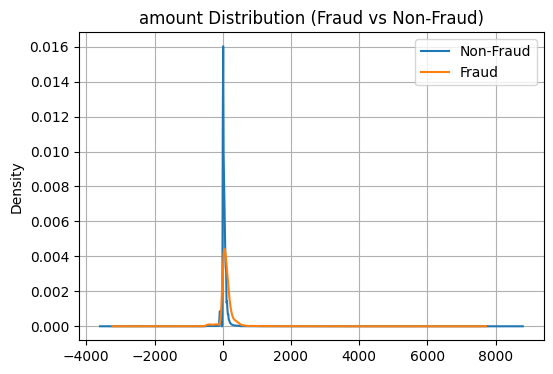

In [4]:
plt.figure(figsize=(6,4))

df[df["fraud"] == 0]["amount"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"] == 1]["amount"].plot(kind="kde", label="Fraud")

plt.title("amount Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

**log_abs_amount**

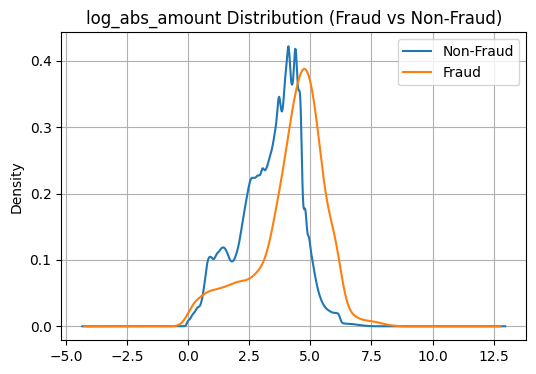

In [5]:
plt.figure(figsize=(6,4))

df[df["fraud"] == 0]["log_abs_amount"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"] == 1]["log_abs_amount"].plot(kind="kde", label="Fraud")

plt.title("log_abs_amount Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

### **1.2 Ratio Features**

**amount_income_ratio**

In [8]:
non_refund = df.loc[df["is_refund"] == 0].copy()
non_refund["log_amount_income_ratio"] = np.log1p(
    non_refund["amount_income_ratio"].values
)

In [9]:
non_refund["log_amount_income_ratio"].describe()

count    5.046287e+06
mean     2.181674e-03
std      4.439899e-02
min      0.000000e+00
25%      2.571618e-04
50%      7.493865e-04
75%      1.596254e-03
max      5.081403e+00
Name: log_amount_income_ratio, dtype: float64

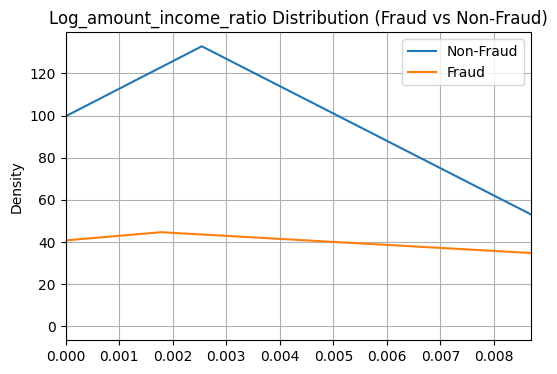

In [10]:
xmax = non_refund["log_amount_income_ratio"].quantile(0.99)
plt.figure(figsize=(6,4))
non_refund[non_refund["fraud"]==0]["log_amount_income_ratio"].plot(kind="kde", label="Non-Fraud")
non_refund[non_refund["fraud"]==1]["log_amount_income_ratio"].plot(kind="kde", label="Fraud")
plt.title(f"Log_amount_income_ratio Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.xlim(0, xmax)
plt.grid(True)
plt.show()

In [11]:
refund = df.loc[df["is_refund"]==1].copy()
refund["log_refund_income_ratio"] = np.log1p(refund["amount_income_ratio"].abs().values)

In [12]:
refund["log_refund_income_ratio"].describe()

count    2.662380e+05
mean     2.759371e-03
std      1.125277e-02
min      2.243007e-07
25%      1.382920e-03
50%      1.895017e-03
75%      2.637568e-03
max      5.272999e+00
Name: log_refund_income_ratio, dtype: float64

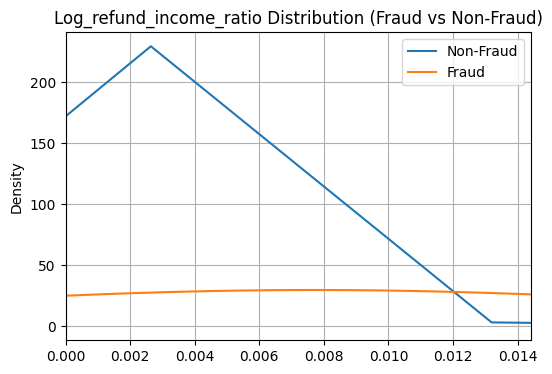

In [13]:
xmax = refund["log_refund_income_ratio"].quantile(0.99)
plt.figure(figsize=(6,4))
refund[refund["fraud"]==0]["log_refund_income_ratio"].plot(kind="kde", label="Non-Fraud")
refund[refund["fraud"]==1]["log_refund_income_ratio"].plot(kind="kde", label="Fraud")
plt.title(f"Log_refund_income_ratio Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.xlim(0, xmax)
plt.grid(True)
plt.show()

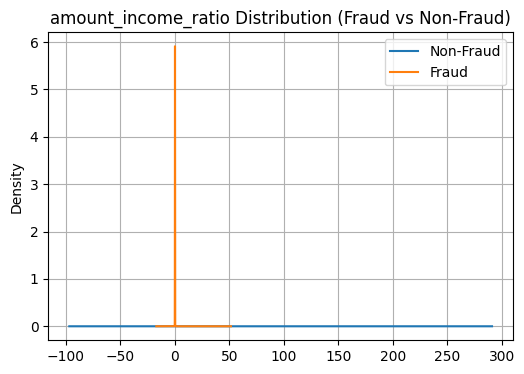

In [14]:
plt.figure(figsize=(6,4))

df[df["fraud"] == 0]["amount_income_ratio"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"] == 1]["amount_income_ratio"].plot(kind="kde", label="Fraud")

plt.title("amount_income_ratio Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_925824/2381857282.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_rate = df.groupby("ratio_bin")["fraud"].mean()


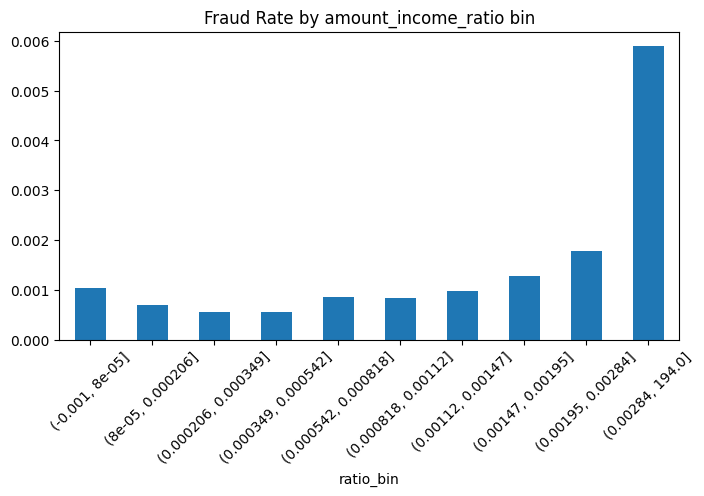

In [15]:
df["ratio_bin"] = pd.qcut(df["amount_income_ratio"], 10, duplicates="drop")

bin_rate = df.groupby("ratio_bin")["fraud"].mean()

bin_rate.plot(kind="bar", figsize=(8,4))
plt.title("Fraud Rate by amount_income_ratio bin")
plt.xticks(rotation=45)
plt.show()

> **소득 대비 매우 큰 결제일 때 fraud 확률 급상승**

**amount_limit_ratio**

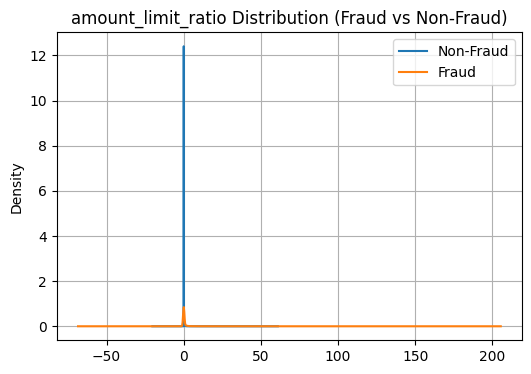

In [16]:
plt.figure(figsize=(6,4))

df[df["fraud"] == 0]["amount_limit_ratio"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"] == 1]["amount_limit_ratio"].plot(kind="kde", label="Fraud")

plt.title("amount_limit_ratio Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_925824/294743172.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_rate = df.groupby("limit_ratio_bin")["fraud"].mean()


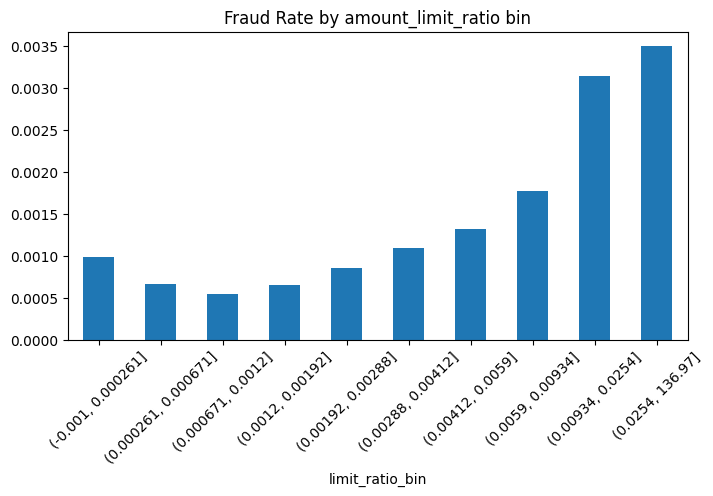

In [17]:
df["limit_ratio_bin"] = pd.qcut(df["amount_limit_ratio"], 10, duplicates="drop")

bin_rate = df.groupby("limit_ratio_bin")["fraud"].mean()

bin_rate.plot(kind="bar", figsize=(8,4))
plt.title("Fraud Rate by amount_limit_ratio bin")
plt.xticks(rotation=45)
plt.show()

> **한도 대비 과도한 사용 리스크 구조**

**is_refund**

In [19]:
df.groupby("is_refund")[LABEL].mean()

is_refund
0    0.001460
1    0.001194
Name: fraud, dtype: float64

In [20]:
df.groupby("fraud")["is_refund"].mean()

fraud
0    0.050128
1    0.041363
Name: is_refund, dtype: float64

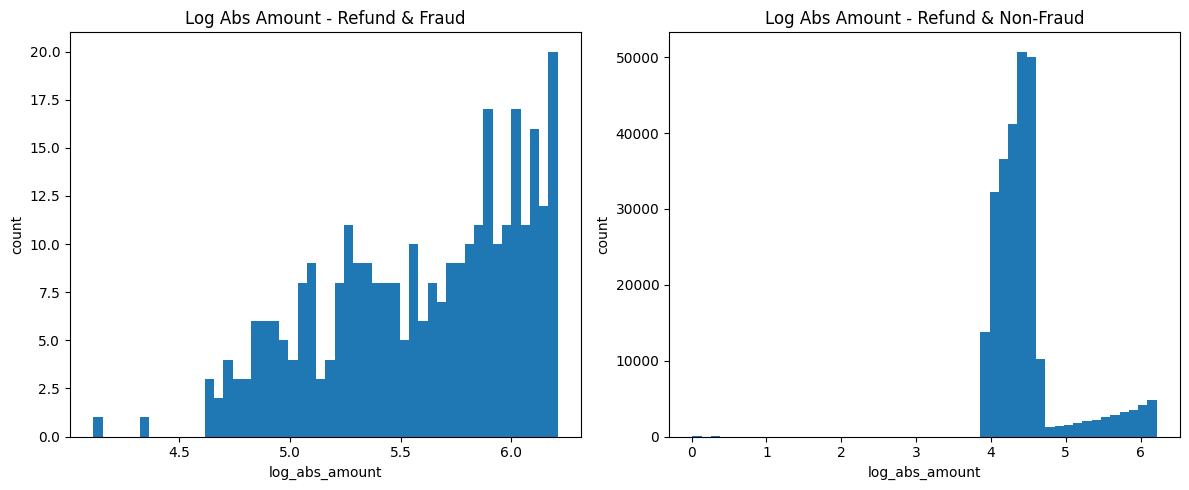

Mean amount (refund+fraud): -293.47485
Mean amount (refund+nonfraud): -102.138275


In [21]:
df_rf = df[(df["is_refund"] == 1) & (df["fraud"] == 1)]
df_rn = df[(df["is_refund"] == 1) & (df["fraud"] == 0)]

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.hist(np.log1p(np.abs(df_rf["amount"])), bins=50)
plt.title("Log Abs Amount - Refund & Fraud")
plt.xlabel("log_abs_amount")
plt.ylabel("count")

plt.subplot(1, 2, 2)
plt.hist(np.log1p(np.abs(df_rn["amount"])), bins=50)
plt.title("Log Abs Amount - Refund & Non-Fraud")
plt.xlabel("log_abs_amount")
plt.ylabel("count")

plt.tight_layout()
plt.show()

print("Mean amount (refund+fraud):", df_rf["amount"].mean())
print("Mean amount (refund+nonfraud):", df_rn["amount"].mean())


> y축 scale 다름 주의 

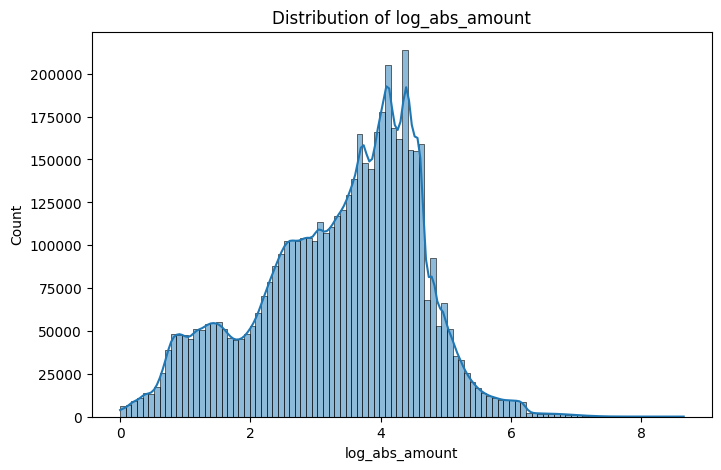

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["log_abs_amount"], bins=100, kde=True)
plt.title("Distribution of log_abs_amount")
plt.show()


/tmp/ipykernel_925824/3721917751.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("amt_bin")["fraud"]


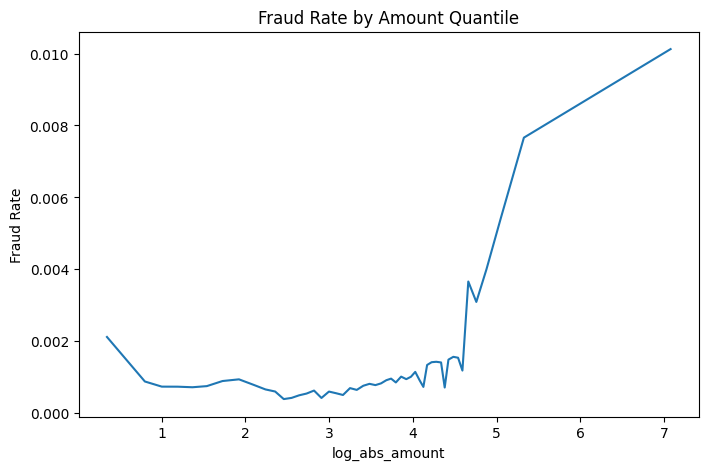

In [24]:
tmp = df.copy()

# 더 촘촘하게 자르기
tmp["amt_bin"] = pd.qcut(tmp["log_abs_amount"], q=50, duplicates="drop")

rate_table = (
    tmp.groupby("amt_bin")["fraud"]
       .agg(["mean","count"])
)

rate_table["mid"] = rate_table.index.map(lambda x: x.mid)

plt.figure(figsize=(8,5))
plt.plot(rate_table["mid"], rate_table["mean"])
plt.xlabel("log_abs_amount")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Amount Quantile")
plt.show()


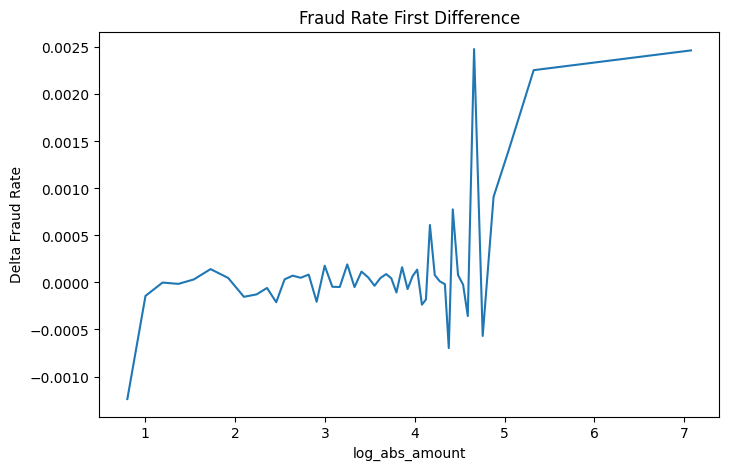

In [25]:
rate_table = rate_table.sort_values("mid")

rate_table["delta"] = rate_table["mean"].diff()

plt.figure(figsize=(8,5))
plt.plot(rate_table["mid"], rate_table["delta"])
plt.title("Fraud Rate First Difference")
plt.xlabel("log_abs_amount")
plt.ylabel("Delta Fraud Rate")
plt.show()


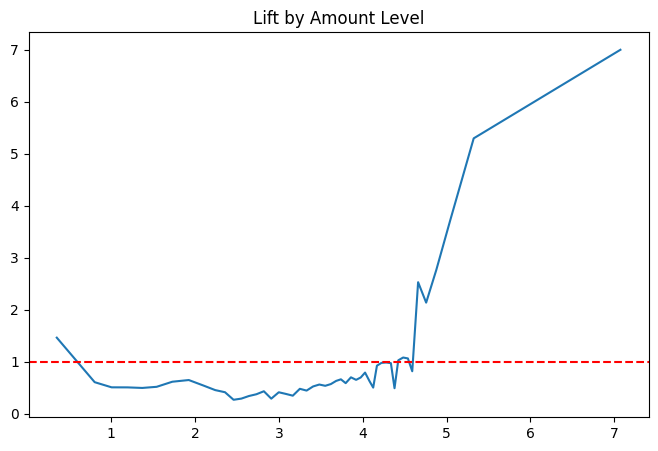

In [26]:
base_rate = df["fraud"].mean()

rate_table["lift"] = rate_table["mean"] / base_rate

plt.figure(figsize=(8,5))
plt.plot(rate_table["mid"], rate_table["lift"])
plt.axhline(1, color="red", linestyle="--")
plt.title("Lift by Amount Level")
plt.show()


In [27]:
lift_thr = 2

candidate = rate_table[rate_table["lift"] >= lift_thr]

if len(candidate) > 0:
    cutoff_mid = candidate.iloc[0]["mid"]
    print("Lift >= 2 최초 지점:", cutoff_mid)
else:
    print("조건 만족 구간 없음")


Lift >= 2 최초 지점: 4.661


In [28]:
thr_value = 4.661

percentile = (df["log_abs_amount"] <= thr_value).mean()
print("해당 값의 분위:", percentile)

해당 값의 분위: 0.8928846452487282


In [29]:
thr_struct = 4.661
thr_q90 = df["log_abs_amount"].quantile(0.9)

print("구조 threshold:", thr_struct)
print("0.9 분위 threshold:", thr_q90)

구조 threshold: 4.661
0.9 분위 threshold: 4.707275390625


In [30]:
thresholds = {
    "struct": 4.661,
    "q90": df["log_abs_amount"].quantile(0.9)
}

base = df["fraud"].mean()

for name, thr in thresholds.items():
    mask = df["log_abs_amount"] >= thr
    lift = df.loc[mask, "fraud"].mean() / base
    share = mask.mean()
    print(name, " | lift:", lift, "| 비율:", share)


struct  | lift: 4.086203236478472 | 비율: 0.10711535475127176
q90  | lift: 4.184258197220414 | 비율: 0.10000442350859526


In [31]:
thr = df["log_abs_amount"].quantile(0.9) # 위의 과정 바탕 0.9 사용
df["refund_high_amount"] = (
    (df["is_refund"] == 1) & (df["log_abs_amount"] > thr)
).astype("int8")

### **Statistical Validation (Quantitative Validation Layer)**

In [32]:
CANDIDATES = [
    "amount", 
    "log_abs_amount",
    "refund_high_amount"
]


def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

rows_uni = []

for col in CANDIDATES:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,log_abs_amount,0.661671,1.938029,0.000000e+00,0.006055,4.184258,531276
1,amount,0.002696,1.002700,0.000000e+00,0.005698,3.937212,531265
2,refund_high_amount,1.954172,7.058073,5.797729e-246,0.001447,1.000000,5312525


In [ ]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in CANDIDATES:
    if col in BASELINE:
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)



=== BASELINE ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006117612512305813, 'top_decile_lift': 4.227363347026202, 'thr': 0.002807587535846678, 'top_n': 531253}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,refund_high_amount,OK,0.741447,2.098971,2.099722e-33,0.001447,0.006089,4.207852,-0.000028,-0.019511,531253.0
1,amount,OK,0.001088,1.001088,4.295782e-72,0.001447,0.006050,4.180537,-0.000068,-0.046826,531253.0
2,log_abs_amount,SKIP (already in BASELINE),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


[High]

| feature        | OR   | p_value  | Top Decile Lift | 해석                               |
| -------------- | ---- | -------- | --------------- | -------------------------------- |
| log_abs_amount | 1.94 | 0.000000 | 4.184258        | 로그 스케일 금액이 가장 안정적이고 강한 금액 리스크 신호 |

금액 자체를 로그 변환했을 때 lift가 가장 높고 안정적이다. Baseline 금액 축의 핵심 변수다.

[Mid]

| feature | OR     | p_value  | Top Decile Lift | 해석                                   |
| ------- | ------ | -------- | --------------- | ------------------------------------ |
| amount  | 1.0027 | 0.000000 | 3.937212        | 원시 금액, 정보는 있으나 log_abs_amount에 비해 약함 |

원시 금액은 통계적으로 유의하지만 로그 변환 변수에 대부분 흡수된다. 둘 중 하나만 선택하는 것이 적절하다.

[Low]

| feature            | OR   | p_value   | Top Decile Lift | 해석              |
| ------------------ | ---- | --------- | --------------- | --------------- |
| refund_high_amount | 7.06 | 5.80e-246 | 1.000000        | 상위 10%에서 구분력 없음 |

refund_high_amount는 OR는 크지만 상위 10% lift가 1로, 실제 랭킹 성능 개선에 기여하지 못한다. 실질적 모델 성능 측면에서는 제거하는 것이 합리적이다.


---
# 2. Error Behavior Block

> 실패/에러 기반 이상행동 탐지

## 2.1 Error Presence

- has_error

## 2.2 Error Type Breakdown

- err_bad_card_number

- err_bad_expiration

- err_bad_cvv

- err_bad_pin

- err_bad_zipcode

- err_insufficient_balance

- err_technical_glitch

## 2.3 Error Interaction / Burst (파생)

- error_count

- error_high_amount

- client_error_last1

- client_error_last3

- card_error_last1

- card_error_last3

- client_hist_x_error

## 2.4 Statistical Validation

---

### **2.1 Error Presence**
**has_error**

In [121]:
df.groupby("has_error")["fraud"].value_counts()

has_error  fraud
0          0        5220606
           1           7349
1          0          84231
           1            339
Name: count, dtype: int64

In [122]:
error_ratio = (
    df
    .groupby("has_error")["fraud"]
    .mean()
)
error_ratio

has_error
0    0.001406
1    0.004009
Name: fraud, dtype: float64

> has error의 비율이 더 높음 _ error fraud 비례 가설 적중

### **2.2 Error Type Breakdown**

- `err_bad_card_number`
- `err_bad_expiration`
- `err_bad_cvv`
- `err_bad_pin`
- `err_bad_zipcode`
- `err_insufficient_balance`
- `err_technical_glitch`

In [124]:
err_cols = [
    "err_bad_card_number",
    "err_bad_expiration",
    "err_bad_cvv",
    "err_bad_pin",
    "err_bad_zipcode",
    "err_insufficient_balance",
    "err_technical_glitch"
]

err_ratio = (
    df.groupby("fraud")[err_cols]
      .mean()
      .T
)

err_ratio

fraud,0,1
err_bad_card_number,0.000585,0.005983
err_bad_expiration,0.000462,0.004683
err_bad_cvv,0.000442,0.013918
err_bad_pin,0.002445,0.003772
err_bad_zipcode,0.000089,0.000000
err_insufficient_balance,0.009916,0.013528
err_technical_glitch,0.002011,0.002732


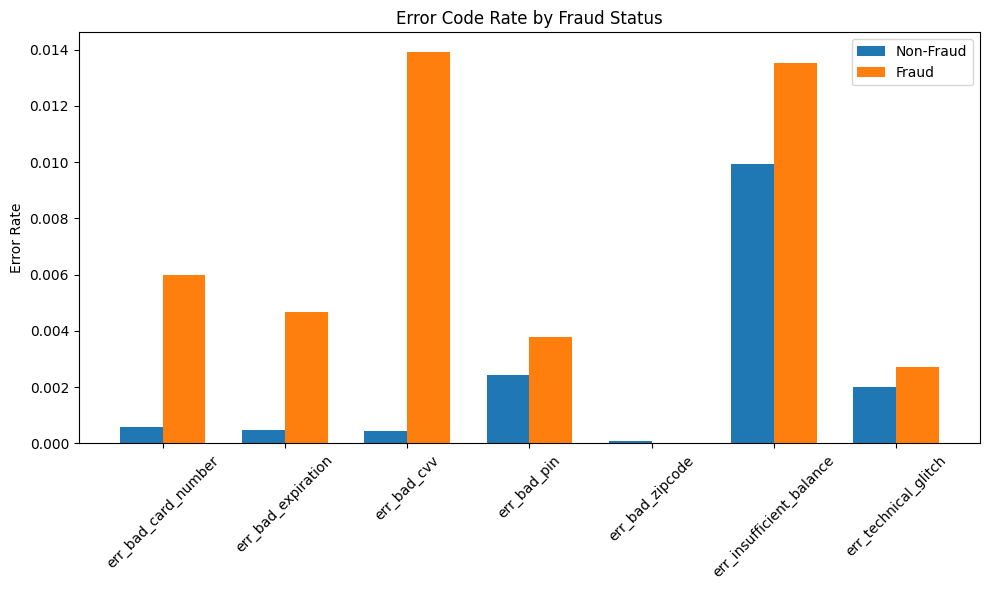

In [125]:
x = np.arange(len(err_cols))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, err_ratio[0], width, label="Non-Fraud")
plt.bar(x + width/2, err_ratio[1], width, label="Fraud")

plt.xticks(x, err_ratio.index, rotation=45)
plt.ylabel("Error Rate")
plt.title("Error Code Rate by Fraud Status")
plt.legend()
plt.tight_layout()
plt.show()

### **2.3 Error Interaction / Burst**

In [3]:
def interaction_report(df, x, y, label="fraud", baseline_col=0, min_count=50):
    # (A) rate / count
    rate = df.pivot_table(index=x, columns=y, values=label, aggfunc="mean", observed=False)
    cnt  = df.pivot_table(index=x, columns=y, values=label, aggfunc="size", observed=False).fillna(0).astype(int)

    print(f"\n=== Interaction: {x} x {y} ===")
    print("Fraud rate:")
    display(rate.round(6))
    print("Count:")
    display(cnt)

    # (B) uplift (row-wise)
    if baseline_col in rate.columns:
        base = rate[baseline_col].replace(0, np.nan)
        uplift = rate.div(base, axis=0).round(2) 
        print(f"Uplift vs {y}={baseline_col} within each {x}:")
        display(uplift)

    # (C) Heatmap (optionally mask low-count cells)
    masked = rate.copy()
    masked[cnt < min_count] = np.nan  # 표본 너무 적은 칸은 해석 금지

    plt.figure(figsize=(6, 3.8))
    im = plt.imshow(masked.values, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(masked.columns)), [str(c) for c in masked.columns])
    plt.yticks(range(len(masked.index)), [str(i) for i in masked.index])
    plt.xlabel(y)
    plt.ylabel(x)
    plt.title(f"Fraud rate heatmap: {x} x {y}")

    for i in range(masked.shape[0]):
        for j in range(masked.shape[1]):
            v = masked.values[i, j]
            if pd.notna(v):
                plt.text(j, i, f"{v:.4f}", ha="center", va="center")
            else:
                # low count 등으로 마스킹된 칸 표시
                if cnt.values[i, j] < min_count:
                    plt.text(j, i, f"n<{min_count}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


In [4]:
g = df.groupby("client_id")["has_error"]
df["client_error_last1"] = g.shift(1).fillna(0).astype("int8")

e1 = g.shift(1).fillna(0).astype("int8")
e2 = g.shift(2).fillna(0).astype("int8")
e3 = g.shift(3).fillna(0).astype("int8")
df["client_error_last3"] = (e1 + e2 + e3).astype("int8")

e1 = g.shift(1).fillna(0).astype("int8")
e2 = g.shift(2).fillna(0).astype("int8")
e3 = g.shift(3).fillna(0).astype("int8")
e4 = g.shift(4).fillna(0).astype("int8")
e5 = g.shift(5).fillna(0).astype("int8")
df["client_error_last5"] = (e1 + e2 + e3 + e4 + e5).astype("int8")

In [ ]:
df["client_fraud_cum_prev"] = (
    df.groupby("client_id")["fraud"]
      .cumsum()
      .shift(1)
      .fillna(0)
      .astype("int32")
)

df["card_fraud_cum_prev"] = (
    df.groupby("card_id")["fraud"]
      .cumsum()
      .shift(1)
      .fillna(0)
      .astype("int32")
)

# client/card 누적 fraud bin (현재행 제외 기준)
df["client_fraud_hist_bin"] = pd.cut(
    df["client_fraud_cum_prev"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"]
)

df["card_fraud_hist_bin"] = pd.cut(
    df["card_fraud_cum_prev"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["0", "1", "2", "3+"]
)


=== Interaction: client_fraud_hist_bin x has_error ===
Fraud rate:


has_error,0,1
client_fraud_hist_bin,,
0,0.001414,0.003994
1,0.001557,0.005908
2,0.001489,0.006231
3+,0.001381,0.003874


Count:


has_error,0,1
client_fraud_hist_bin,,
0,3278313,52823
1,84778,1354
2,57765,963
3+,1807099,29430


Uplift vs has_error=0 within each client_fraud_hist_bin:


has_error,0,1
client_fraud_hist_bin,,
0,1.0,2.82
1,1.0,3.79
2,1.0,4.18
3+,1.0,2.81


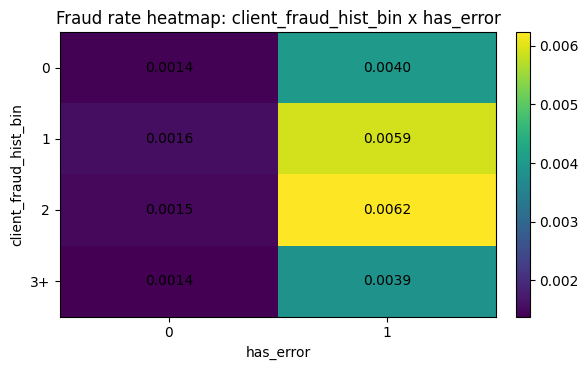


=== Interaction: client_fraud_hist_bin x client_error_last1 ===
Fraud rate:


client_error_last1,0,1
client_fraud_hist_bin,,
0,0.001442,0.002251
1,0.001629,0.001413
2,0.001522,0.004381
3+,0.001399,0.002725


Count:


client_error_last1,0,1
client_fraud_hist_bin,,
0,3278263,52873
1,84717,1415
2,57815,913
3+,1807175,29354


Uplift vs client_error_last1=0 within each client_fraud_hist_bin:


client_error_last1,0,1
client_fraud_hist_bin,,
0,1.0,1.56
1,1.0,0.87
2,1.0,2.88
3+,1.0,1.95


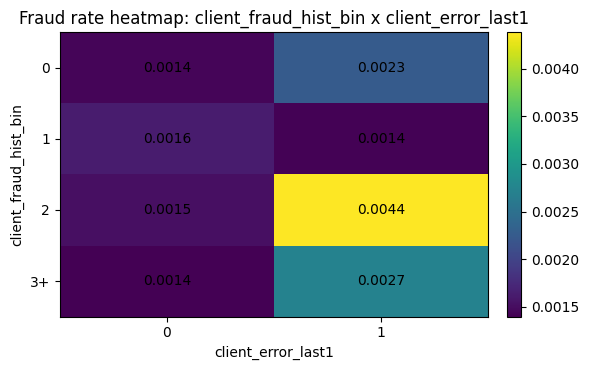


=== Interaction: client_fraud_hist_bin x client_error_last3 ===
Fraud rate:


client_error_last3,0,1,2,3
client_fraud_hist_bin,,,,
0,0.001412,0.002368,0.001766,0.0
1,0.001595,0.002344,0.000000,0.0
2,0.001516,0.002765,0.000000,0.0
3+,0.001377,0.002355,0.001267,0.0


Count:


client_error_last3,0,1,2,3
client_fraud_hist_bin,,,,
0,3178419,146941,5662,114
1,82121,3840,166,5
2,56080,2532,115,1
3+,1751774,81530,3157,68


Uplift vs client_error_last3=0 within each client_fraud_hist_bin:


client_error_last3,0,1,2,3
client_fraud_hist_bin,,,,
0,1.0,1.68,1.25,0.0
1,1.0,1.47,0.00,0.0
2,1.0,1.82,0.00,0.0
3+,1.0,1.71,0.92,0.0


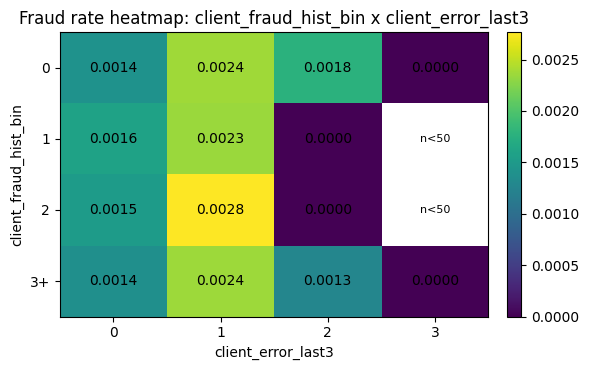

In [131]:
interaction_report(df, "client_fraud_hist_bin", "has_error")
interaction_report(df, "client_fraud_hist_bin", "client_error_last1")
interaction_report(df, "client_fraud_hist_bin", "client_error_last3")

In [6]:
g = df.groupby("card_id")["has_error"]
df["card_error_last1"] = g.shift(1).fillna(0).astype("int8")

e1 = g.shift(1).fillna(0).astype("int8")
e2 = g.shift(2).fillna(0).astype("int8")
e3 = g.shift(3).fillna(0).astype("int8")
df["card_error_last3"] = (e1 + e2 + e3).astype("int8")

e1 = g.shift(1).fillna(0).astype("int8")
e2 = g.shift(2).fillna(0).astype("int8")
e3 = g.shift(3).fillna(0).astype("int8")
e4 = g.shift(4).fillna(0).astype("int8")
e5 = g.shift(5).fillna(0).astype("int8")
df["card_error_last5"] = (e1 + e2 + e3 + e4 + e5).astype("int8")


=== Interaction: card_fraud_hist_bin x has_error ===
Fraud rate:


has_error,0,1
card_fraud_hist_bin,,
0,0.001393,0.003905
1,0.001742,0.006705
2,0.001754,0.009124
3+,0.001435,0.004136


Count:


has_error,0,1
card_fraud_hist_bin,,
0,4346426,70163
1,63704,1044
2,31929,548
3+,785896,12815


Uplift vs has_error=0 within each card_fraud_hist_bin:


has_error,0,1
card_fraud_hist_bin,,
0,1.0,2.80
1,1.0,3.85
2,1.0,5.20
3+,1.0,2.88


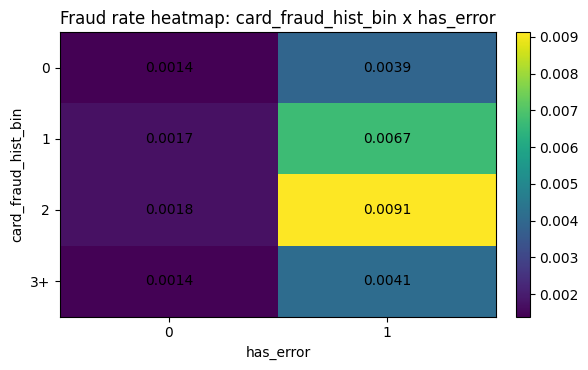


=== Interaction: card_fraud_hist_bin x card_error_last1 ===
Fraud rate:


card_error_last1,0,1
card_fraud_hist_bin,,
0,0.001413,0.002666
1,0.001789,0.003922
2,0.001813,0.006160
3+,0.001434,0.004195


Count:


card_error_last1,0,1
card_fraud_hist_bin,,
0,4346451,70138
1,63728,1020
2,31990,487
3+,785838,12873


Uplift vs card_error_last1=0 within each card_fraud_hist_bin:


card_error_last1,0,1
card_fraud_hist_bin,,
0,1.0,1.89
1,1.0,2.19
2,1.0,3.40
3+,1.0,2.92


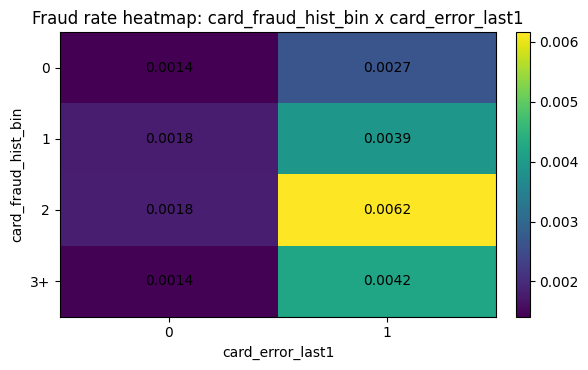


=== Interaction: card_fraud_hist_bin x card_error_last3 ===
Fraud rate:


card_error_last3,0,1,2,3
card_fraud_hist_bin,,,,
0,0.001372,0.002722,0.001716,0.0
1,0.001638,0.005726,0.000000,0.0
2,0.001771,0.004415,0.000000,0.0
3+,0.001395,0.003206,0.004013,0.0


Count:


card_error_last3,0,1,2,3
card_fraud_hist_bin,,,,
0,4212943,196516,6991,139
1,61672,2969,102,5
2,31059,1359,57,2
3+,762194,35244,1246,27


Uplift vs card_error_last3=0 within each card_fraud_hist_bin:


card_error_last3,0,1,2,3
card_fraud_hist_bin,,,,
0,1.0,1.98,1.25,0.0
1,1.0,3.50,0.00,0.0
2,1.0,2.49,0.00,0.0
3+,1.0,2.30,2.88,0.0


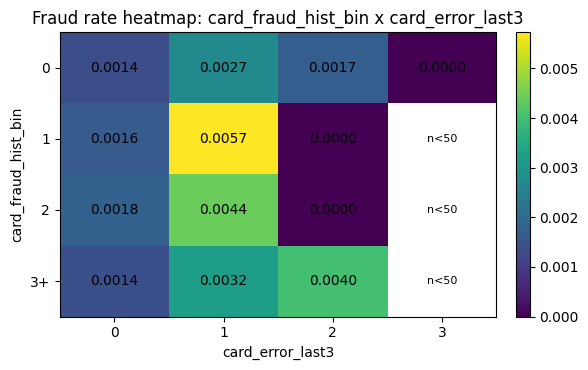

In [133]:
interaction_report(df, "card_fraud_hist_bin", "has_error")
interaction_report(df, "card_fraud_hist_bin", "card_error_last1")
interaction_report(df, "card_fraud_hist_bin", "card_error_last3")

In [7]:
df["client_has_fraud_history"] = (
    df["client_fraud_cum_prev"] > 0
).astype("int8")
df["card_has_fraud_history"] = (
    df["card_fraud_cum_prev"] > 0
).astype("int8")

In [8]:
df["client_hist_x_error"] = (
    df["client_has_fraud_history"] * df["has_error"]
)
df["card_hist_x_error"] = (
    df["card_has_fraud_history"] * df["card_error_last1"]
)

### **2.4 Statistical Validation (Quantitative Validation Layer)**

In [ ]:
ERROR_PRESENCE = ["has_error"]

ERROR_TYPES = [
    "err_bad_card_number",
    "err_bad_expiration",
    "err_bad_cvv",
    "err_bad_pin",
    "err_bad_zipcode",
    "err_insufficient_balance",
    "err_technical_glitch",
]

ERROR_CANDIDATES = ERROR_PRESENCE + ERROR_TYPES
ERROR_CANDIDATES = [c for c in ERROR_CANDIDATES if c in df.columns]

print("Error candidates used:", ERROR_CANDIDATES)


# 1) util

def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }


# 2) (A) 단변량 검증

rows_uni = []

for col in ERROR_CANDIDATES:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)
    lift = top_decile_lift(y, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

print("\n=== Univariate (Error Block) ===")
display(uni_df)


# 3) (B) Baseline + add-one (다변량 incremental)

base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("\n=== BASELINE ===")
print(base_lift)

rows_inc = []

for col in ERROR_CANDIDATES:
    if col in BASELINE:
        rows_inc.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]
    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows_inc.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows_inc)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

print("\n=== Multivariate Add-one vs BASELINE (Error Block) ===")
display(inc_df)


Error candidates used: ['has_error', 'err_bad_card_number', 'err_bad_expiration', 'err_bad_cvv', 'err_bad_pin', 'err_bad_zipcode', 'err_insufficient_balance', 'err_technical_glitch']

=== Univariate (Error Block) ===


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,err_bad_zipcode,-131.129297,1.125304e-57,1.000000e+00,0.001447,1.000089,5312051
1,has_error,1.050486,2.859041e+00,1.887055e-79,0.001447,1.000000,5312525
2,err_bad_expiration,2.319805,1.017369e+01,3.103368e-43,0.001447,1.000000,5312525
3,err_bad_card_number,2.330647,1.028459e+01,3.597161e-55,0.001447,1.000000,5312525
4,err_bad_cvv,3.463502,3.192859e+01,2.302579e-265,0.001447,1.000000,5312525
5,err_bad_pin,0.434947,1.544880e+00,1.953135e-02,0.001447,1.000000,5312525
6,err_insufficient_balance,0.314269,1.369258e+00,1.472524e-03,0.001447,1.000000,5312525
7,err_technical_glitch,0.306954,1.359279e+00,1.605155e-01,0.001447,1.000000,5312525



=== BASELINE ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006117612512305813, 'top_decile_lift': 4.227363347026202, 'thr': 0.002807587535846678, 'top_n': 531253}


/home/nakyung/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



=== Multivariate Add-one vs BASELINE (Error Block) ===


,added_feature,status,coef,OR,p_value,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,err_insufficient_balance,OK,-1.651173,1.918248e-01,2.311459e-44,0.006193,4.279392,0.000075,0.052029,531253.0
1,err_bad_cvv,OK,2.878016,1.777896e+01,6.208539e-127,0.006182,4.271588,0.000064,0.044225,531253.0
2,err_bad_card_number,OK,1.551893,4.720397e+00,4.364120e-22,0.006131,4.236468,0.000013,0.009105,531253.0
3,err_technical_glitch,OK,-0.522527,5.930200e-01,2.063242e-02,0.006127,4.233867,0.000009,0.006504,531253.0
4,err_bad_expiration,OK,1.539435,4.661957e+00,5.666862e-18,0.006125,4.232542,0.000007,0.005179,531256.0
5,err_bad_zipcode,OK,-14.963677,3.172179e-07,9.906798e-01,0.006119,4.228473,0.000002,0.001110,531277.0
6,err_bad_pin,OK,-0.373224,6.885107e-01,5.524990e-02,0.006112,4.223421,-0.000006,-0.003942,531258.0
7,has_error,SKIP (already in BASELINE),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


지금 이 블록은 **단변량 OR는 크지만, top decile lift가 전부 1.0 수준**이라는 게 핵심이다.
즉, “랭킹 모델 성능에는 기여하지 못하는 구조”다.

[High]

| feature   | OR   | p_value  | Top Decile Lift | 해석                  |
| --------- | ---- | -------- | --------------- | ------------------- |
| has_error | 2.86 | 1.89e-79 | 1.000000        | 에러 발생 자체는 기본 리스크 신호 |

개별 에러 타입보다는 has_error 하나로 대표시키는 게 구조적으로 깔끔하다.
실제 lift 개선은 없지만, 다른 피처와의 interaction 용도로는 유지 가치 있음.

---

[Mid]

| feature                  | OR    | p_value   | Top Decile Lift | 해석                     |
| ------------------------ | ----- | --------- | --------------- | ---------------------- |
| err_bad_cvv              | 31.9  | 2.30e-265 | 1.000000        | OR는 매우 크지만 단독 랭킹 기여 없음 |
| err_bad_card_number      | 10.28 | 3.60e-55  | 1.000000        | 동일                     |
| err_bad_expiration       | 10.17 | 3.10e-43  | 1.000000        | 동일                     |
| err_bad_pin              | 1.54  | 0.019     | 1.000000        | 약한 신호                  |
| err_insufficient_balance | 1.37  | 0.001     | 1.000000        | 약한 신호                  |

이들은 단독 변수로는 lift 개선이 전혀 없다.
하지만 이미 너가 만든 `error_x_amount`, `hist_x_error` 같은 interaction에서는 의미가 생긴다.
따라서 **원본 개별 타입은 제거하고, 파생 interaction만 유지하는 전략이 더 합리적**이다.

---

[Low]

| feature              | OR   | p_value | Top Decile Lift | 해석                           |
| -------------------- | ---- | ------- | --------------- | ---------------------------- |
| err_bad_zipcode      | ~0   | 1.0     | 1.000089        | 완전 분리(perfect separation) 의심 |
| err_technical_glitch | 1.36 | 0.16    | 1.000000        | 통계적 유의성 없음                   |

err_bad_zipcode는 계수 -131이면 사실상 완전 분리 현상이다.
이건 모델 불안정성만 유발한다. 제거하는 게 맞다.

---


In [138]:
ERR_BLOCK = [c for c in (ERROR_TYPES) if c in df.columns]

model_errblock, y_e, s_e = fit_logit_and_score(df, BASELINE + ERR_BLOCK, y_col=LABEL)
lift_errblock = top_decile_lift(y_e, s_e)

print("\n=== BASELINE + Error Type Block ===")
print(lift_errblock)
print("Δlift vs baseline:", lift_errblock["top_decile_lift"] - base_lift["top_decile_lift"])

/home/nakyung/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



=== BASELINE + Error Type Block ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006247494131797844, 'top_decile_lift': 4.317113522701527, 'thr': 0.0027398759126967724, 'top_n': 531253}
Δlift vs baseline: 0.0897501756753254


/tmp/ipykernel_829721/2809418986.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["amount_bin", "has_error"])["fraud"]


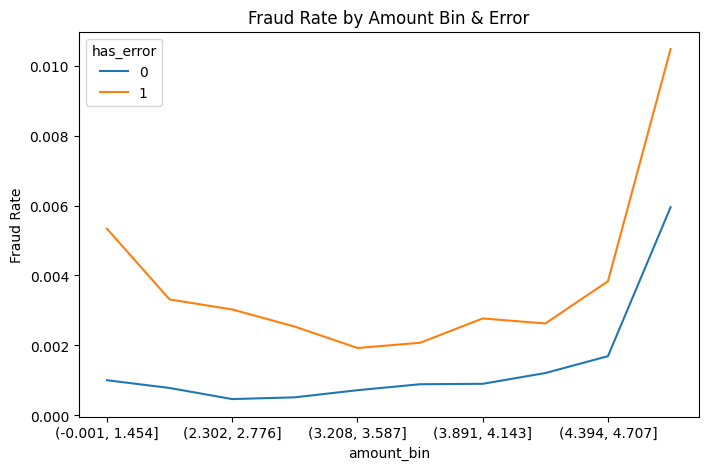

In [139]:
# error 유무별 fraud rate vs amount 구간 비교

df["amount_bin"] = pd.qcut(df["log_abs_amount"], 10, duplicates="drop")

pivot = (
    df.groupby(["amount_bin", "has_error"])["fraud"]
      .mean()
      .unstack()
)

pivot.plot(figsize=(8,5))
plt.title("Fraud Rate by Amount Bin & Error")
plt.ylabel("Fraud Rate")
plt.show()

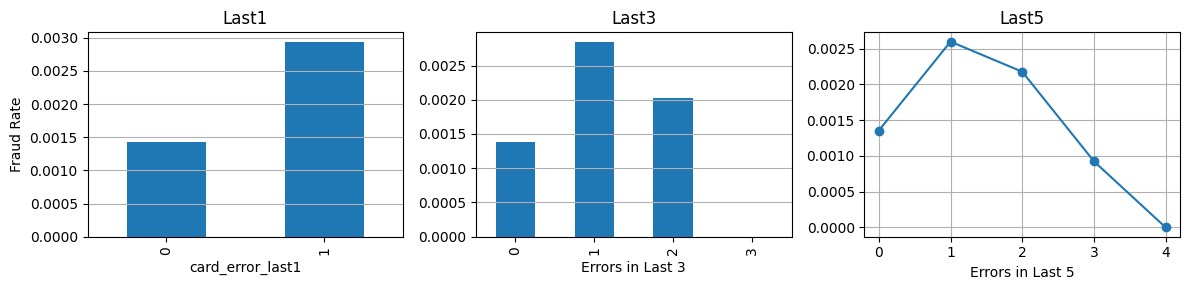

In [9]:
rate_last1 = df.groupby("card_error_last1")["fraud"].mean()
rate_last3 = df.groupby("card_error_last3")["fraud"].mean()
rate_last5 = df.groupby("card_error_last5")["fraud"].mean()

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

rate_last1.plot(kind="bar", ax=axes[0])
axes[0].set_title("Last1")
axes[0].set_xlabel("card_error_last1")
axes[0].set_ylabel("Fraud Rate")
axes[0].grid(axis="y")

rate_last3.plot(kind="bar", ax=axes[1])
axes[1].set_title("Last3")
axes[1].set_xlabel("Errors in Last 3")
axes[1].grid(axis="y")

axes[2].plot(rate_last5.index, rate_last5.values, marker="o")
axes[2].set_title("Last5")
axes[2].set_xlabel("Errors in Last 5")
axes[2].grid(True)

plt.tight_layout()
plt.show()


In [10]:
col = [
    "client_error_last1",
    "client_error_last3",
    "client_error_last5",
    "card_error_last1",
    "card_error_last3",
    "card_error_last5",
]

for c in col:
    table = (
        df.groupby(["tx_year", c])["fraud"]
          .mean()
          .unstack()
          .round(4)
    )
    
    print(f"\n===== {c} =====")
    display(table)


===== client_error_last1 =====


client_error_last1,0,1
tx_year,,
2010,0.0031,0.0058
2011,0.0000,0.0001
2012,0.0010,0.0010
2013,0.0014,0.0028
2014,0.0007,0.0014
2015,0.0023,0.0035



===== client_error_last3 =====


client_error_last3,0,1,2,3
tx_year,,,,
2010,0.0030,0.0053,0.0050,0.0
2011,0.0000,0.0002,0.0000,0.0
2012,0.0010,0.0012,0.0014,0.0
2013,0.0014,0.0026,0.0019,0.0
2014,0.0007,0.0014,0.0000,0.0
2015,0.0023,0.0036,0.0013,0.0



===== client_error_last5 =====


...

card_error_last1,0,1
tx_year,,
2010,0.0030,0.0065
2011,0.0000,0.0002
2012,0.0010,0.0017
2013,0.0014,0.0034
2014,0.0007,0.0015
2015,0.0023,0.0044



===== card_error_last3 =====


card_error_last3,0,1,2,3
tx_year,,,,
2010,0.0030,0.0060,0.0049,0.0
2011,0.0000,0.0002,0.0000,0.0
2012,0.0010,0.0019,0.0008,0.0
2013,0.0014,0.0032,0.0020,0.0
2014,0.0007,0.0017,0.0000,0.0
2015,0.0023,0.0041,0.0047,0.0



===== card_error_last5 =====


card_error_last5,0,1,2,3,4
tx_year,,,,,
2010,0.0029,0.0054,0.0055,0.0083,0.0
2011,0.0000,0.0002,0.0000,0.0000,0.0
2012,0.0010,0.0018,0.0018,0.0000,0.0
2013,0.0013,0.0031,0.0016,0.0000,0.0
2014,0.0007,0.0016,0.0000,0.0000,0.0
2015,0.0022,0.0037,0.0045,0.0000,0.0


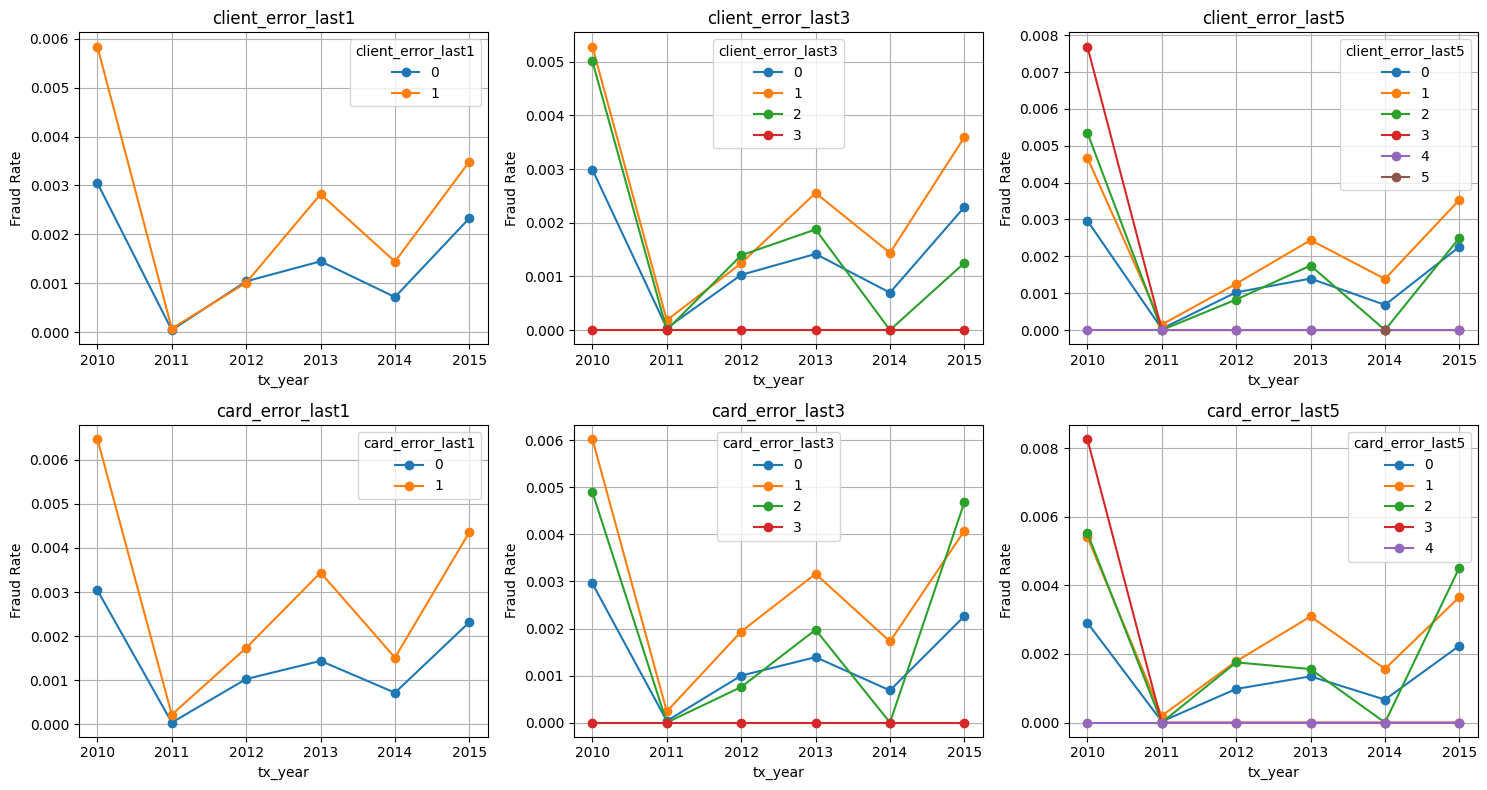

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, c in enumerate(col):
    pivot = (
        df.groupby(["tx_year", c])["fraud"]
          .mean()
          .unstack()
    )
    
    pivot.plot(ax=axes[i], marker="o")
    axes[i].set_title(c)
    axes[i].set_ylabel("Fraud Rate")
    axes[i].grid(True)

plt.tight_layout()
plt.show()


In [12]:
cols = [
    "client_error_last1",
    "client_error_last3",
    "card_error_last1",
    "card_error_last3",
]

result = []

for c in cols:
    for year in sorted(df["tx_year"].unique()):
        sub = df[df["tx_year"] == year]
        
        base = sub[sub[c] == 0]["fraud"].mean()
        burst = sub[sub[c] >= 1]["fraud"].mean()
        
        uplift = burst / base if base > 0 else None
        
        result.append({
            "feature": c,
            "tx_year": year,
            "uplift": round(uplift, 2) if uplift else None
        })

uplift_all = pd.DataFrame(result)
display(uplift_all.pivot(index="tx_year", columns="feature", values="uplift"))


feature,card_error_last1,card_error_last3,client_error_last1,client_error_last3
tx_year,,,,
2010,2.13,2.03,1.91,1.76
2011,5.46,6.65,1.72,4.84
2012,1.69,1.90,0.97,1.21
2013,2.39,2.24,1.95,1.78
2014,2.11,2.43,2.01,1.98
2015,1.88,1.81,1.50,1.53


In [13]:
error_cols = [
    "err_bad_card_number",
    "err_bad_expiration",
    "err_bad_cvv",
    "err_bad_pin",
    "err_bad_zipcode",
    "err_insufficient_balance",
    "err_technical_glitch"
]

df["error_count"] = df[error_cols].sum(axis=1)

In [14]:
df.groupby("error_count")["log_abs_amount"].mean()

error_count
0    3.350889
1    3.856803
2    4.070040
3    4.142182
Name: log_abs_amount, dtype: float32

In [15]:
df.groupby(["error_count", "fraud"])["log_abs_amount"].mean().unstack()

fraud,0,1
error_count,,
0,3.349702,4.194403
1,3.855414,4.204591
2,4.058326,5.179854
3,4.142182,NaN


In [16]:
df["error_amount_interaction"] = (
    df["error_count"] * df["log_abs_amount"]
)

In [18]:
base = df["fraud"].mean()

for q in [0.8, 0.85, 0.9, 0.95]:
    threshold = df["log_abs_amount"].quantile(q)
    rate = df[df["log_abs_amount"] >= threshold]["fraud"].mean()
    print(q, rate / base)


0.8 2.5631289032463065
0.85 3.2358539256023073
0.9 4.184258197220414
0.95 5.6449540882769975


In [19]:
threshold = df["log_abs_amount"].quantile(0.9)

df["high_amount"] = (df["log_abs_amount"] >= threshold).astype("int8")

df["error_high_amount"] = (
    (df["error_count"] >= 2) &
    (df["high_amount"] == 1)
).astype("int8")

In [20]:
df["card_err1_x_amount"] = (
    df["card_error_last1"] * df["log_abs_amount"]
)

df["card_hist_err_x_amount"] = (
    df["card_hist_x_error"] * df["log_abs_amount"]
)

In [ ]:

ERROR_PRESENCE = ["has_error"]

ERROR_TYPES = [
    "err_bad_card_number",
    "err_bad_expiration",
    "err_bad_cvv",
    "err_bad_pin",
    "err_bad_zipcode",
    "err_insufficient_balance",
    "err_technical_glitch",
]

ERROR_INTERACTIONS = [
    "client_error_last1",
    "client_error_last3",
    "client_error_last5",
    "card_error_last1",
    "card_error_last3",
    "card_error_last5",
    "client_hist_x_error",
    "card_hist_x_error",
]

ERROR_CANDIDATES = ERROR_PRESENCE + ERROR_TYPES + ERROR_INTERACTIONS

ERROR_CANDIDATES = [c for c in ERROR_CANDIDATES if c in df.columns]

print("Error candidates used:", ERROR_CANDIDATES)


# 1) util

def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }


# 2) (A) 단변량 검증

rows_uni = []

for col in ERROR_CANDIDATES:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)
    lift = top_decile_lift(y, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

print("\n=== Univariate (Error Block) ===")
display(uni_df)


# 3) (B) Baseline + add-one (다변량 incremental)

base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("\n=== BASELINE ===")
print(base_lift)

rows_inc = []

for col in ERROR_CANDIDATES:
    if col in BASELINE:
        rows_inc.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]
    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows_inc.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows_inc)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

print("\n=== Multivariate Add-one vs BASELINE (Error Block) ===")
display(inc_df)


Error candidates used: ['has_error', 'err_bad_card_number', 'err_bad_expiration', 'err_bad_cvv', 'err_bad_pin', 'err_bad_zipcode', 'err_insufficient_balance', 'err_technical_glitch', 'client_error_last1', 'client_error_last3', 'client_error_last5', 'card_error_last1', 'card_error_last3', 'card_error_last5', 'client_hist_x_error', 'card_hist_x_error']

=== Univariate (Error Block) ===


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,err_bad_zipcode,-131.129297,1.125304e-57,1.000000e+00,0.001447,1.000089,5312051
1,has_error,1.050486,2.859041e+00,1.887055e-79,0.001447,1.000000,5312525
2,err_bad_expiration,2.319805,1.017369e+01,3.103368e-43,0.001447,1.000000,5312525
3,err_bad_card_number,2.330647,1.028459e+01,3.597161e-55,0.001447,1.000000,5312525
4,err_bad_cvv,3.463502,3.192859e+01,2.302579e-265,0.001447,1.000000,5312525
5,err_bad_pin,0.434947,1.544880e+00,1.953135e-02,0.001447,1.000000,5312525
6,err_insufficient_balance,0.314269,1.369258e+00,1.472524e-03,0.001447,1.000000,5312525
7,err_technical_glitch,0.306954,1.359279e+00,1.605155e-01,0.001447,1.000000,5312525
8,client_error_last1,0.527992,1.695524e+00,9.385244e-14,0.001447,1.000000,5312525
9,client_error_last3,0.449681,1.567812e+00,1.567539e-28,0.001447,1.000000,5312525



=== BASELINE ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006117612512305813, 'top_decile_lift': 4.227363347026202, 'thr': 0.002807587535846678, 'top_n': 531253}


/home/nakyung/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



=== Multivariate Add-one vs BASELINE (Error Block) ===


,added_feature,status,coef,OR,p_value,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,err_insufficient_balance,OK,-1.651173,1.918248e-01,2.311459e-44,0.006193,4.279392,0.000075,0.052029,531253.0
1,err_bad_cvv,OK,2.878016,1.777896e+01,6.208539e-127,0.006182,4.271588,0.000064,0.044225,531253.0
2,card_error_last1,OK,0.610506,1.841362e+00,4.934470e-21,0.006142,4.244273,0.000024,0.016909,531253.0
3,card_error_last3,OK,0.561116,1.752627e+00,7.290612e-52,0.006136,4.240371,0.000019,0.013007,531253.0
4,card_error_last5,OK,0.471194,1.601907e+00,5.085468e-57,0.006135,4.239070,0.000017,0.011707,531253.0
5,err_bad_card_number,OK,1.551893,4.720397e+00,4.364120e-22,0.006131,4.236468,0.000013,0.009105,531253.0
6,err_technical_glitch,OK,-0.522527,5.930200e-01,2.063242e-02,0.006127,4.233867,0.000009,0.006504,531253.0
7,card_hist_x_error,OK,0.984855,2.677425e+00,2.325377e-14,0.006127,4.233867,0.000009,0.006504,531253.0
8,err_bad_expiration,OK,1.539435,4.661957e+00,5.666862e-18,0.006125,4.232542,0.000007,0.005179,531256.0
9,err_bad_zipcode,OK,-14.963677,3.172179e-07,9.906798e-01,0.006119,4.228473,0.000002,0.001110,531277.0


---

[High]

| feature                  | OR    | Δ Lift  | 해석                          |
| ------------------------ | ----- | ------- | --------------------------- |
| err_insufficient_balance | 0.19  | +0.0520 | 실제 랭킹 기여 가장 큼 (의외지만 강한 분리력) |
| err_bad_cvv              | 17.78 | +0.0442 | 강한 고위험 에러 유형                |
| card_error_last1         | 1.84  | +0.0169 | 카드 단기 에러 히스토리               |
| card_error_last3         | 1.75  | +0.0130 | 카드 단기 누적                    |
| card_error_last5         | 1.60  | +0.0117 | 카드 중기 누적                    |
| err_bad_card_number      | 4.72  | +0.0091 | 강한 단일 에러 타입                 |

이 블록의 핵심은
**“카드 기준 단기 에러 히스토리 + CVV/카드번호 계열”**

client_error 계열보다 card_error 계열이 더 안정적이다.

---

[Mid]

| feature              | OR   | Δ Lift  | 해석               |
| -------------------- | ---- | ------- | ---------------- |
| card_hist_x_error    | 2.68 | +0.0065 | 히스토리 interaction |
| err_bad_expiration   | 4.66 | +0.0052 | 중간 수준 기여         |
| err_technical_glitch | 0.59 | +0.0065 | 방향성 애매           |
| client_error_last3   | 1.44 | -0.0068 | 정보 일부 중복         |
| client_error_last1   | 1.46 | -0.0104 | 중복 가능성 높음        |

이 그룹은 card_error 계열과 정보가 겹친다.
Stage1에서는 과감히 줄여도 된다.

---

[Low]

| feature             | OR          | Δ Lift  | 해석           |
| ------------------- | ----------- | ------- | ------------ |
| client_hist_x_error | 1.02        | -0.0013 | 기여 없음        |
| err_bad_pin         | 0.69        | -0.0039 | 약함           |
| client_error_last5  | 1.37        | -0.0234 | 중복           |
| err_bad_zipcode     | ~0          | ~0      | 완전 분리, 제거 대상 |
| has_error           | baseline 포함 | -       | 중복           |

---

---
# 3. Temporal Risk Block

> 시간 기반 리스크 패턴

## 3.1 Calendar Components

- tx_year
 
- tx_month

- tx_day

- tx_hour

- weekday

## 3.2 Cyclical Encoding

- hour_sin

- hour_cos

## 3.3 Statistical Validation

## 3.4 Time Deviation History 

- client_weekday_prev

- client_weekday_match_last1

- client_weekday_prior_count

- client_weekday_is_new

- sin_shift

- cos_shift

- sin_cumsum

- cos_cumsum

- cnt_past

- client_sin_mean_past

- client_cos_mean_past

- hour_circular_distance

## 3.5 Statistical Validation 
---

### **3.1 Calendar Componenets**

**tx_year**

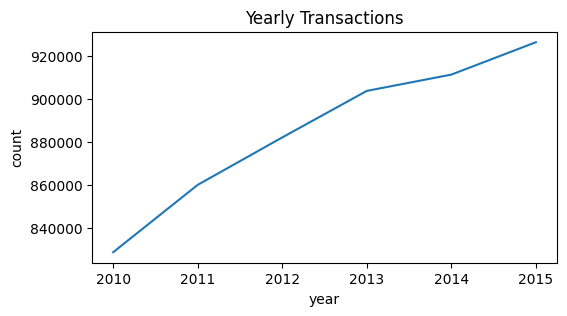

In [6]:
yearly = df["tx_year"].value_counts()

plt.figure(figsize=(6,3))
yearly.plot()
plt.title("Yearly Transactions")
plt.xlabel("year")
plt.ylabel("count")
plt.show()

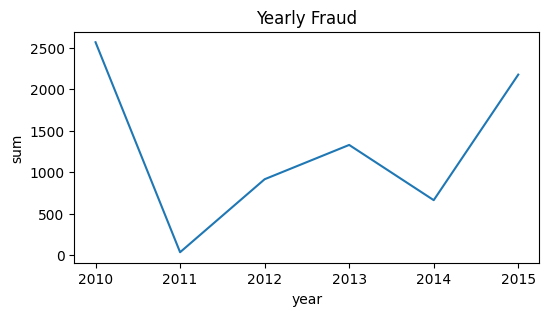

tx_year
2010    2566
2011      37
2012     916
2013    1329
2014     664
2015    2176
Name: fraud, dtype: int64

tx_year
2010    0.003095
2011    0.000043
2012    0.001038
2013    0.001471
2014    0.000729
2015    0.002349
Name: fraud, dtype: float64


In [7]:
yearly_fraud = (
    df
    .groupby("tx_year")[LABEL]
    .sum()
)
plt.figure(figsize=(6,3))
yearly_fraud.plot()
plt.title("Yearly Fraud")
plt.xlabel("year")
plt.ylabel("sum")
plt.show()
print(yearly_fraud)
print()
yearly_fraud = (
    df
    .groupby("tx_year")[LABEL]
    .mean()
)
print(yearly_fraud)

**tx_month**

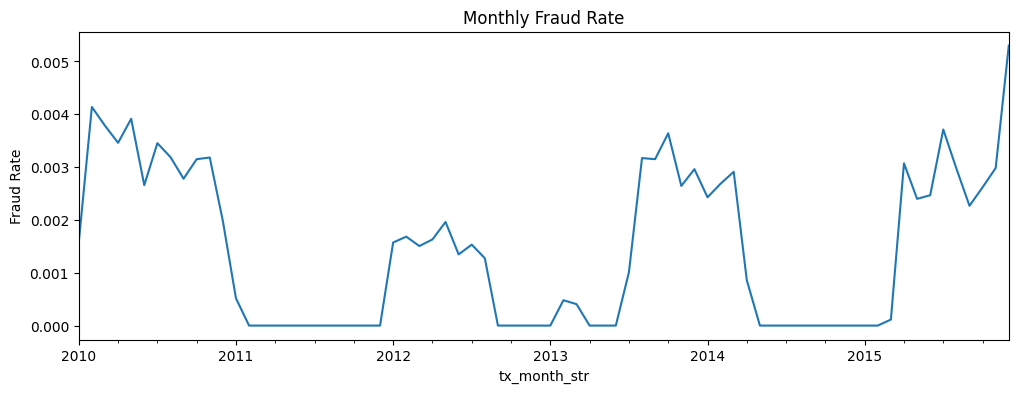

In [8]:
monthly_fraud = (
    df
    .assign(tx_month_str=df["date"].dt.to_period("M"))
    .groupby("tx_month_str")[LABEL]
    .mean()
)

plt.figure(figsize=(12,4))
monthly_fraud.plot()
plt.title("Monthly Fraud Rate")
plt.ylabel("Fraud Rate")
plt.show()

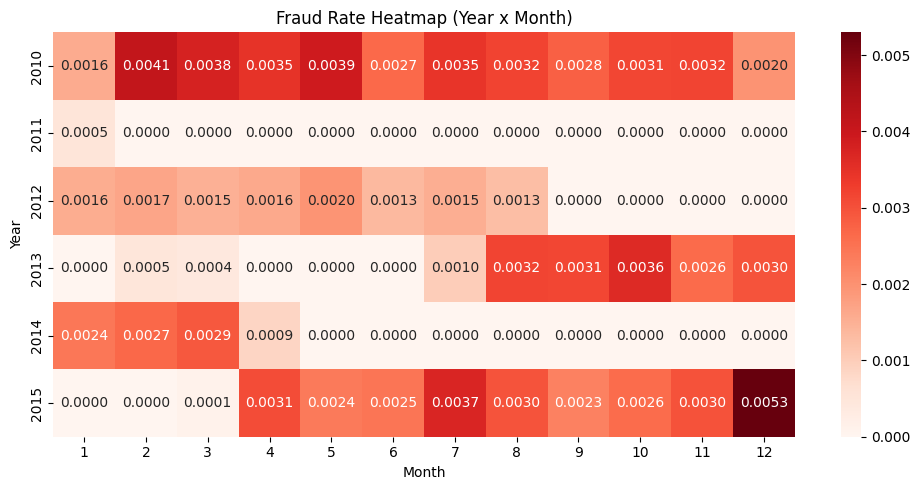

In [9]:
pivot_df = (
    df.groupby(["tx_year", "tx_month"])[LABEL]
    .mean()
    .unstack()
)
plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".4f",
    cmap="Reds"
)
plt.title("Fraud Rate Heatmap (Year x Month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

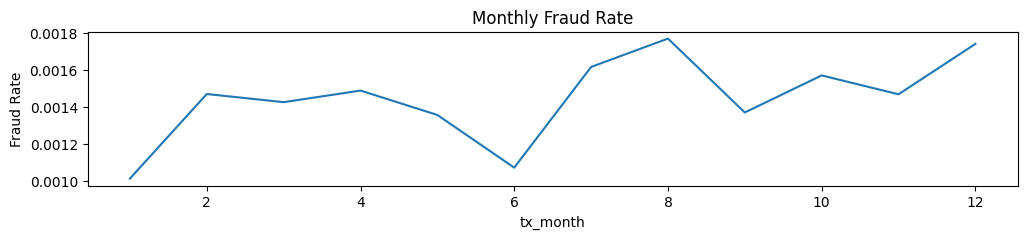

tx_month
1     0.001011
2     0.001468
3     0.001424
4     0.001487
5     0.001355
6     0.001070
7     0.001615
8     0.001768
9     0.001369
10    0.001569
11    0.001467
12    0.001740
Name: fraud, dtype: float64


In [10]:
monthly_fraud = (
    df
    .groupby("tx_month")[LABEL]
    .mean()
)

plt.figure(figsize=(12,2))
monthly_fraud.plot()
plt.title("Monthly Fraud Rate")
plt.ylabel("Fraud Rate")
plt.show()
print(monthly_fraud)

**tx_day**

tx_day
1     0.001453
2     0.001441
3     0.001245
4     0.001392
5     0.001665
6     0.001592
7     0.001466
8     0.001322
9     0.001404
10    0.001262
11    0.001169
12    0.001605
13    0.001206
14    0.001278
15    0.001531
16    0.001320
17    0.001137
18    0.001647
19    0.001743
20    0.001306
21    0.001413
22    0.001447
23    0.001600
24    0.001233
25    0.001355
26    0.001650
27    0.001710
28    0.001658
29    0.001727
30    0.001367
31    0.001613
Name: fraud, dtype: float64


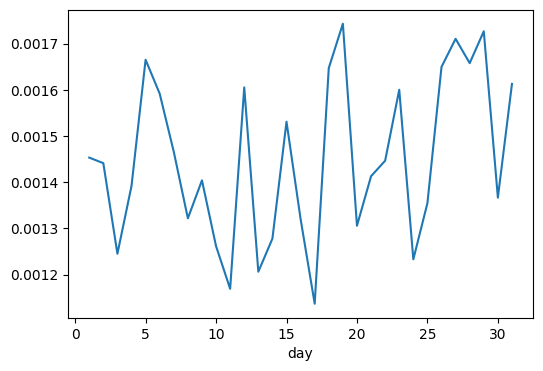

In [14]:
day = (
    df
    .groupby("tx_day")[LABEL]
    .mean()
)

plt.figure(figsize=(6, 4))
day.plot()
plt.xlabel("day")
plt.ylabel("")

print(day)

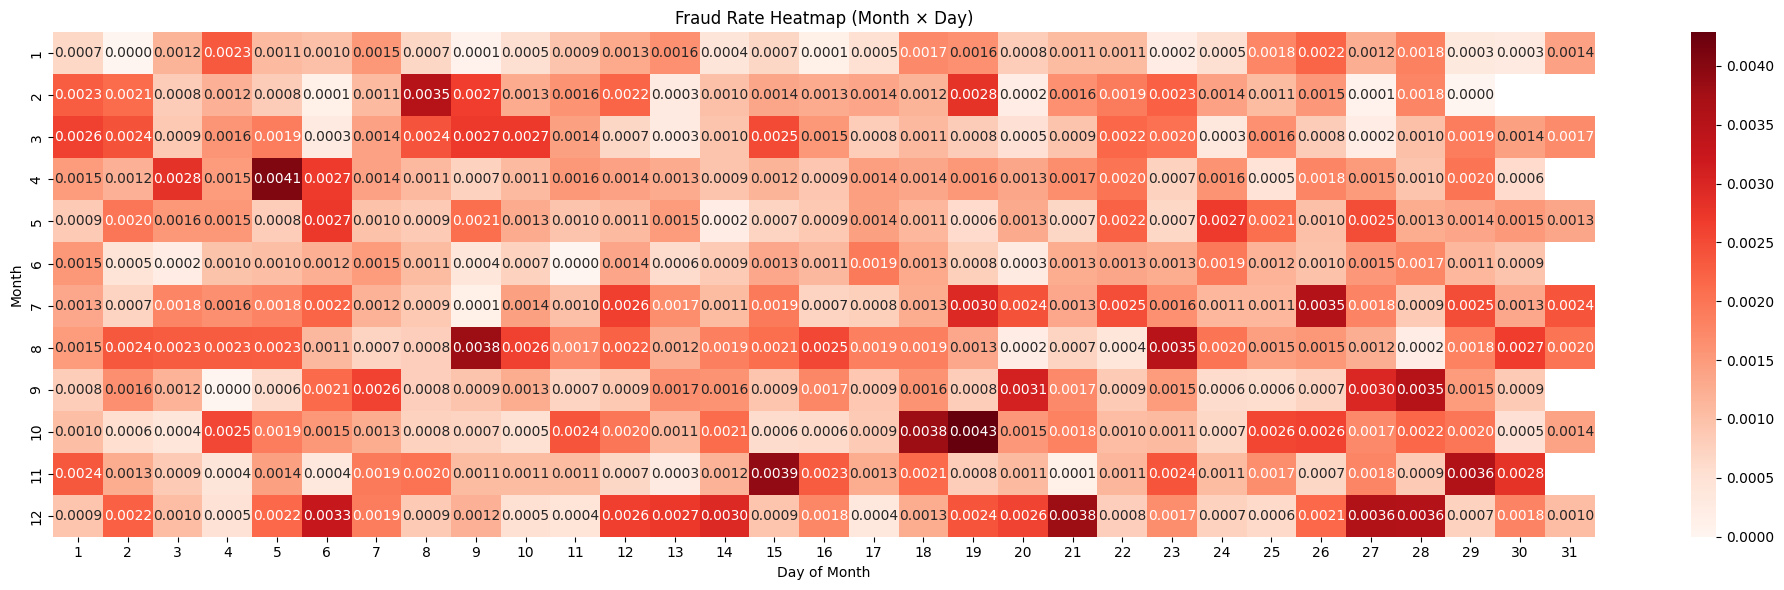

In [23]:
pivot_day = (
    df
    .groupby(["tx_month", "tx_day"])[LABEL]
    .mean()
    .unstack()  # day를 열로
)

plt.figure(figsize=(20,6))
sns.heatmap(
    pivot_day,
    cmap="Reds",
    annot=True,
    fmt=".4f"
)

plt.xlabel("Day of Month")
plt.ylabel("Month")
plt.title("Fraud Rate Heatmap (Month × Day)")
plt.tight_layout()
plt.show()

**tx_hour**

tx_hour
0     0.000234
1     0.000824
2     0.000837
3     0.002465
4     0.002833
5     0.003024
6     0.001457
7     0.001398
8     0.001400
9     0.002283
10    0.002405
11    0.002170
12    0.001825
13    0.001988
14    0.001566
15    0.001433
16    0.001112
17    0.000821
18    0.000461
19    0.000533
20    0.000113
21    0.000125
22    0.000066
23    0.000333
Name: fraud, dtype: float64


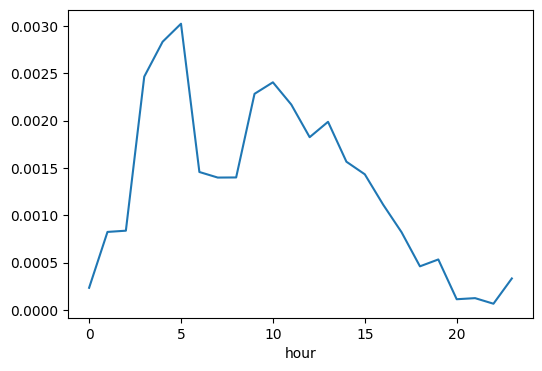

In [15]:
hour = (
    df
    .groupby("tx_hour")[LABEL]
    .mean()
)

plt.figure(figsize=(6, 4))
hour.plot()
plt.xlabel("hour")
plt.ylabel("")

print(hour)

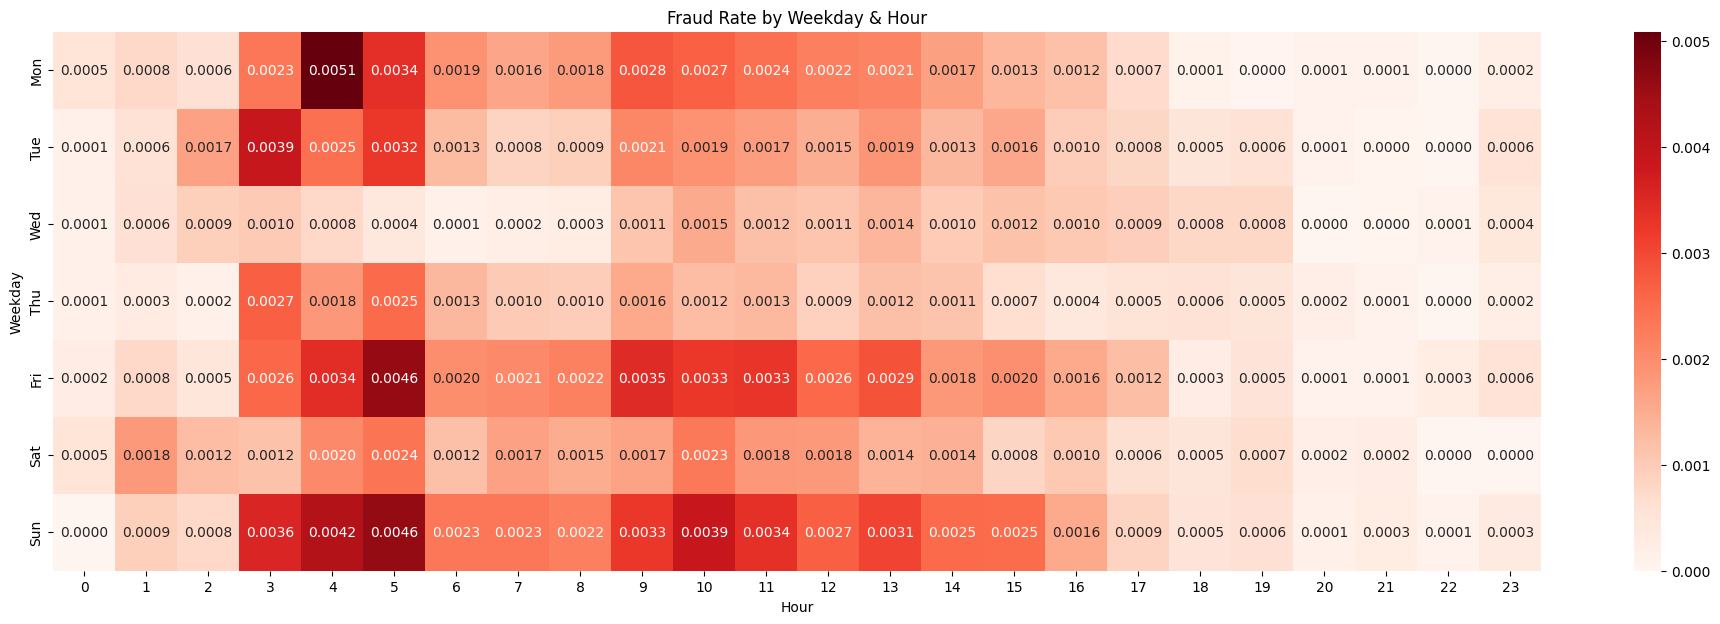

In [ ]:
pivot_weekday_hour = (
    df.groupby(["weekday_name", "tx_hour"])["fraud"]
      .mean()
      .unstack()  
      .reindex(index=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
)

plt.figure(figsize=(24,7))
sns.heatmap(
    pivot_weekday_hour,
    cmap="Reds",
    annot=True,
    fmt=".4f"
)
plt.title("Fraud Rate by Weekday & Hour")
plt.xlabel("Hour")
plt.ylabel("Weekday")
plt.show()

In [17]:
df.drop("weekday_name", axis=1, inplace=True)

**weekday**

weekday
6    0.002206
4    0.002016
0    0.001626
5    0.001280
1    0.001261
3    0.000920
2    0.000816
Name: fraud, dtype: float64


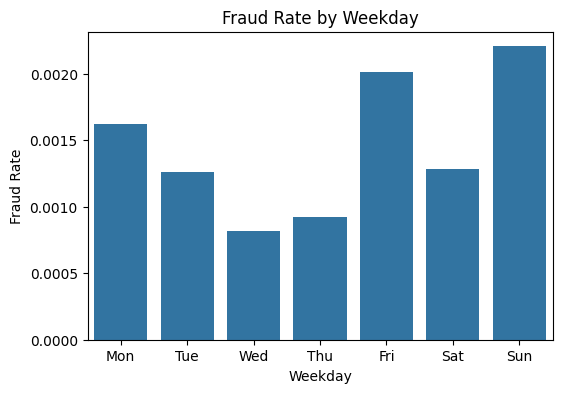

In [11]:
weekday_rate = (
    df.groupby("weekday")["fraud"]
      .mean()
      .sort_values(ascending=False)
)

print(weekday_rate)

weekday_map = {
    0: "Mon", 1: "Tue", 2: "Wed",
    3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"
}

weekday_df = weekday_rate.reset_index()
weekday_df.columns = ["weekday", "fraud_rate"]

weekday_df["weekday_name"] = weekday_df["weekday"].map(weekday_map)

weekday_df = weekday_df.sort_values("weekday")

plt.figure(figsize=(6,4))
sns.barplot(data=weekday_df, x="weekday_name", y="fraud_rate")
plt.xlabel("Weekday")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Weekday")
plt.show()

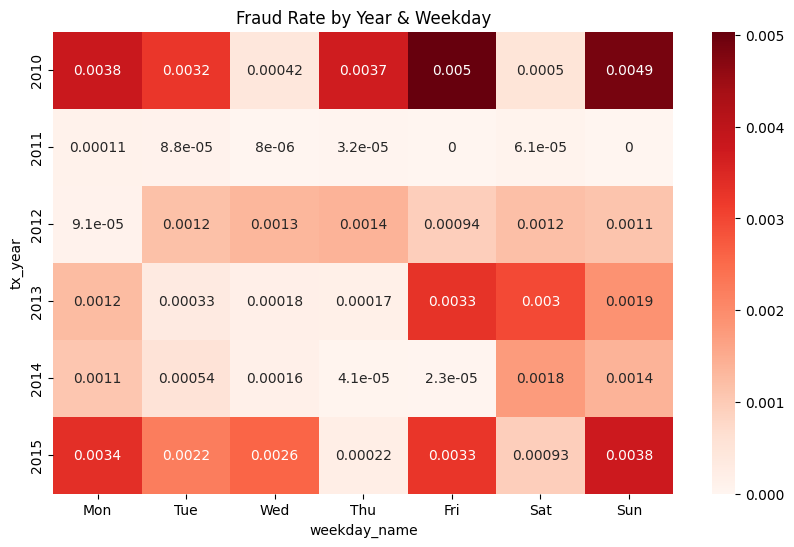

In [12]:
df["weekday_name"] = df["date"].dt.day_name().str[:3]
pivot_weekday = (
    df.groupby(["tx_year", "weekday_name"])["fraud"]
      .mean()
      .unstack()
      .reindex(columns=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
)
plt.figure(figsize=(10,6))
sns.heatmap(pivot_weekday, cmap="Reds", annot=True)
plt.title("Fraud Rate by Year & Weekday")
plt.show()

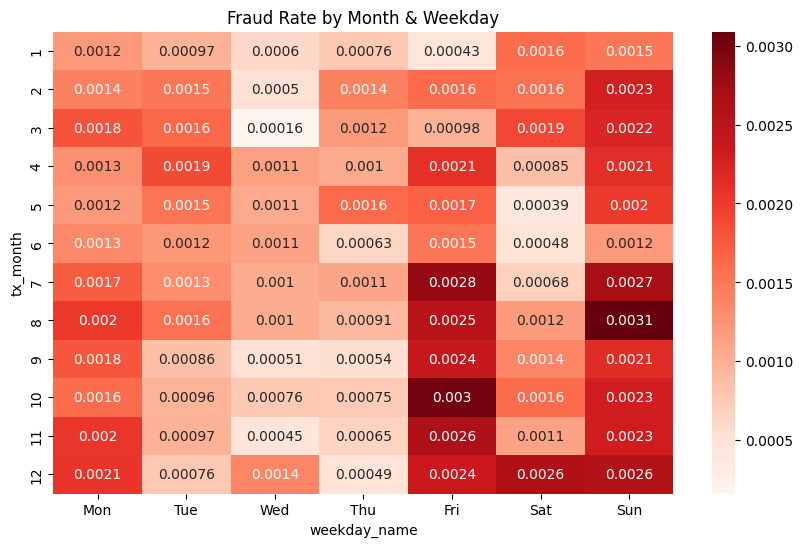

In [13]:
pivot_weekday = (
    df.groupby(["tx_month", "weekday_name"])["fraud"]
      .mean()
      .unstack()
      .reindex(columns=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
)
plt.figure(figsize=(10,6))
sns.heatmap(pivot_weekday, cmap="Reds", annot=True)
plt.title("Fraud Rate by Month & Weekday")
plt.show()


### **3.2 Cyclical Encoding**

**hour_sin**

In [80]:
df["hour_sin"] = np.sin(2 * np.pi * df["tx_hour"] / 24).astype("float32")

**hour_cos**

In [81]:
df["hour_cos"] = np.cos(2 * np.pi * df["tx_hour"] / 24).astype("float32")

### **3.3 Statistical Validation (Quantitative Validation Layer)**

**단변량 Signal 확인**

In [24]:
results = []

for col in ["tx_year",
            "tx_month",
            "tx_day",
            "tx_hour",
            "weekday",
            "hour_sin",
            "hour_cos"]:

    X = sm.add_constant(df[[col]].dropna())
    y = df.loc[X.index, "fraud"]

    model = sm.Logit(y, X).fit(disp=0)

    coef = model.params[col]
    pval = model.pvalues[col]
    or_val = np.exp(coef)

    results.append([col, coef, or_val, pval])

pd.DataFrame(results, columns=["feature","coef","OR","p_value"])

,feature,coef,OR,p_value
0,tx_year,-0.013787,0.986308,3.976901e-02
1,tx_month,0.025336,1.025660,2.487005e-14
2,tx_day,0.003928,1.003936,2.480725e-03
3,tx_hour,-0.061140,0.940691,1.764006e-157
4,weekday,0.073300,1.076053,1.927531e-37
5,hour_sin,0.412541,1.510652,6.178729e-139
6,hour_cos,-0.745041,0.474715,6.164731e-206


**다변량 Incrementality**

In [26]:
TIME_CANDIDATES = [
    "tx_year",
    "tx_month",
    "tx_day",
    "tx_hour",
    "weekday",
    "hour_sin",
    "hour_cos",
]

# 1) 유틸: 모델 학습 + 점수
def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score

def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

# 2) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 3) 시간 피처 add-one 다변량 검증
rows = []

for tcol in TIME_CANDIDATES:
    feats = BASELINE + [tcol]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    # 추가된 피처의 coef/OR/p-value만 뽑기
    coef = model.params.get(tcol, np.nan)
    pval = model.pvalues.get(tcol, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    # baseline 대비 lift 개선량
    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_time_feature": tcol,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": delta_rate,
        "delta_lift_vs_baseline": delta_lift,
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values("delta_lift_vs_baseline", ascending=False)
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006117612512305813, 'top_decile_lift': 4.227363347026202, 'thr': 0.002807587535846678, 'top_n': 531253}


,added_time_feature,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,hour_cos,-0.798736,0.449897,1.102375e-242,0.001447,0.006191,4.278092,0.000073,0.050728,531253
1,tx_hour,-0.072296,0.930256,1.094321e-236,0.001447,0.006187,4.275450,0.000070,0.048087,531258
2,hour_sin,0.558322,1.747738,6.477618e-249,0.001447,0.006168,4.262483,0.000051,0.035120,531253
3,tx_month,0.025939,1.026278,7.514903e-15,0.001447,0.006135,4.239070,0.000017,0.011707,531253
4,tx_day,0.003927,1.003935,2.565187e-03,0.001447,0.006116,4.226031,-0.000002,-0.001333,531257
5,weekday,0.072193,1.074862,3.914981e-36,0.001447,0.006112,4.223461,-0.000006,-0.003902,531253
6,tx_year,-0.009258,0.990784,1.679144e-01,0.001447,0.006106,4.219559,-0.000011,-0.007804,531253


---

[High]

| feature  | OR   | Δ Lift  | 해석               |
| -------- | ---- | ------- | ---------------- |
| hour_cos | 0.45 | +0.0507 | 주기성 구조를 가장 잘 포착  |
| tx_hour  | 0.93 | +0.0481 | 시간대 리스크 직접 반영    |
| hour_sin | 1.75 | +0.0351 | cos와 함께 쓰일 때 안정적 |

핵심은 **hour_sin + hour_cos 조합**이다.
이 조합이 단순 tx_hour보다 구조적으로 더 우수하다.

실무적으로는:

* DL/GBM → sin/cos
* 로지스틱 해석형 → tx_hour

둘 다 유지할 필요는 없음.
sin/cos를 쓰면 tx_hour는 제거하는 게 깔끔하다.

---

[Mid]

| feature  | OR     | Δ Lift  | 해석           |
| -------- | ------ | ------- | ------------ |
| tx_month | 1.026  | +0.0117 | 약한 계절성       |
| weekday  | 1.07   | -0.0039 | 구조 중복        |
| tx_day   | 1.0039 | -0.0013 | 실질적 기여 거의 없음 |

월 변수는 약하지만 의미는 있다.
요일은 hour 정보와 겹치는 경향.

---

[Low]

| feature | OR   | Δ Lift  | 해석           |
| ------- | ---- | ------- | ------------ |
| tx_year | 0.99 | -0.0078 | 구조적 의미 거의 없음 |

연도 변수는 drift 성격이라 모델 feature로는 부적절.
오히려 모니터링용이 적합.

---

### **3.4 Time Deviation History**

- client_weekday_prev

- client_weekday_match_last1

- client_weekday_prior_count

- client_weekday_is_new

- sin_shift

- cos_shift

- sin_cumsum

- cos_cumsum

- cnt_past

- client_sin_mean_past

- client_cos_mean_past

- hour_circular_distance


In [72]:
df = df.sort_values(["client_id", "date"])

df["client_weekday_prev"] = (
    df.groupby("client_id")["weekday"]
      .shift(1)
)

df["client_weekday_match_last1"] = (
    df["weekday"] == df["client_weekday_prev"]
).astype("int8")


In [73]:
df["client_weekday_prev"] = df.groupby("client_id")["weekday"].shift(1)

df["client_weekday_prev"] = df["client_weekday_prev"].fillna(df["weekday"]).astype(df["weekday"].dtype)

df["client_weekday_match_last1"] = (df["weekday"] == df["client_weekday_prev"]).astype("int8")


In [74]:
df["client_weekday_prior_count"] = (
    df.groupby(["client_id", "weekday"])
      .cumcount()
)

df["client_weekday_is_new"] = (
    df["client_weekday_prior_count"] == 0
).astype("int8")

In [75]:
pd.crosstab(
    df["client_weekday_is_new"],
    df["fraud"],
    normalize="index"
)

fraud,0,1
client_weekday_is_new,,
0,0.998552,0.001448
1,0.999172,0.000828


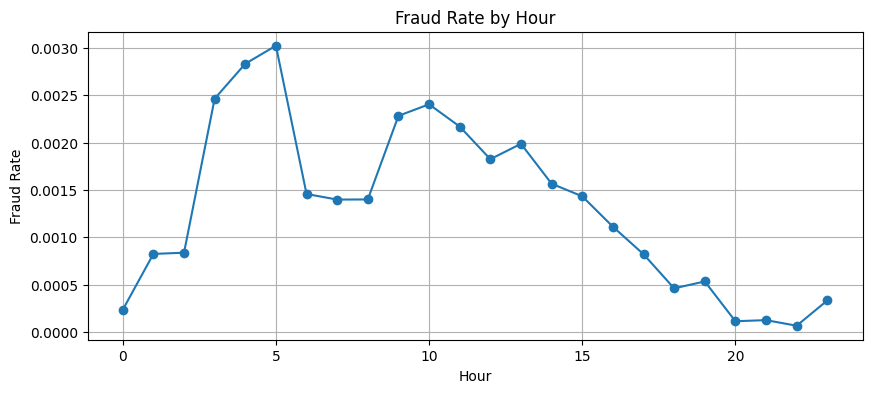

In [76]:
hour_rate = (
    df.groupby("tx_hour")["fraud"]
      .mean()
)

plt.figure(figsize=(10,4))
hour_rate.plot(marker="o")
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.grid(True)
plt.show()


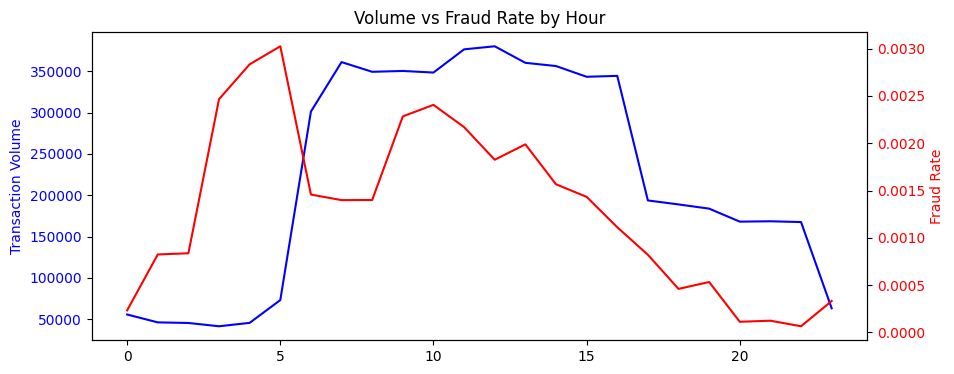

In [77]:
hour_full = (
    df.groupby("tx_hour")["fraud"]
      .agg(["mean", "count"])
)

fig, ax1 = plt.subplots(figsize=(10,4))

# 거래량 - 파랑
ax1.plot(hour_full.index, hour_full["count"], color="blue", label="Transaction Volume")
ax1.set_ylabel("Transaction Volume", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# fraud rate - 빨강
ax2 = ax1.twinx()
ax2.plot(hour_full.index, hour_full["mean"], color="red", label="Fraud Rate")
ax2.set_ylabel("Fraud Rate", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Volume vs Fraud Rate by Hour")
plt.show()


In [ ]:
# 1-1) shift (과거값)
df["sin_shift"] = (
    df.groupby("client_id")["hour_sin"]
      .shift(1)
      .fillna(df["hour_sin"])
)

df["cos_shift"] = (
    df.groupby("client_id")["hour_cos"]
      .shift(1)
      .fillna(df["hour_cos"])
)
# 1-2) 누적합
df["sin_cumsum"] = df["sin_shift"].fillna(0).groupby(df["client_id"]).cumsum()
df["cos_cumsum"] = df["cos_shift"].fillna(0).groupby(df["client_id"]).cumsum()

# 1-3) 과거 개수 (첫 거래는 0)
df["cnt_past"] = df.groupby("client_id").cumcount()

# 1-4) 과거 평균 (0으로 나누기 방지)
df["client_sin_mean_past"] = np.where(
    df["cnt_past"] > 0,
    df["sin_cumsum"] / df["cnt_past"],
    np.nan
)
df["client_cos_mean_past"] = np.where(
    df["cnt_past"] > 0,
    df["cos_cumsum"] / df["cnt_past"],
    np.nan
)

# 1-5) 첫 거래 결측 채우기:
df["client_sin_mean_past"] = df["client_sin_mean_past"].fillna(df["hour_sin"])
df["client_cos_mean_past"] = df["client_cos_mean_past"].fillna(df["hour_cos"])

# 1-6) 원형 거리
df["hour_circular_distance"] = np.sqrt(
    (df["hour_sin"] - df["client_sin_mean_past"])**2 +
    (df["hour_cos"] - df["client_cos_mean_past"])**2
)


### **3.5 Statistical Validation**

In [84]:
time_behavior_features = [
    "client_weekday_prev",
    "client_weekday_match_last1",
    "client_weekday_prior_count",
    "client_weekday_is_new",
    "sin_shift",
    "cos_shift",
    "sin_cumsum",
    "cos_cumsum",
    "cnt_past",
    "client_sin_mean_past",
    "client_cos_mean_past",
    "hour_circular_distance"
]

In [85]:
rows_uni = []

for col in time_behavior_features:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,cnt_past,-0.000102,0.999898,2.434392e-68,0.003252,2.247369,531936
1,client_weekday_prior_count,-0.000714,0.999286,4.793634e-68,0.003239,2.238158,539065
2,cos_cumsum,0.000169,1.000169,5.314061e-47,0.002123,1.467218,531254
3,client_weekday_prev,0.078881,1.082075,5.302138e-43,0.002087,1.442157,757063
4,client_weekday_match_last1,0.720087,2.054612,2.564613e-160,0.001814,1.253453,3217876
5,client_sin_mean_past,-0.219597,0.802843,4.670565e-07,0.001807,1.248698,531253
6,hour_circular_distance,0.471404,1.602242,3.802332e-39,0.001764,1.218781,531253
7,cos_shift,-0.353941,0.701917,4.066139e-62,0.001741,1.203159,1117080
8,sin_shift,0.377854,1.459149,8.139188e-118,0.001676,1.158156,735671
9,client_weekday_is_new,-0.559744,0.571355,1.389651e-01,0.001448,1.000682,5304070


In [ ]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in time_behavior_features:
    if col in BASELINE:
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006117612512305813, 'top_decile_lift': 4.227363347026202, 'thr': 0.002807587535846677, 'top_n': 531253}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,client_sin_mean_past,OK,-0.077468,0.925457,7.183116e-02,0.001447,0.006123,4.231266,0.000006,0.003902,531253
1,sin_shift,OK,0.423632,1.527500,4.539909e-145,0.001447,0.006123,4.231234,0.000006,0.003870,531257
2,client_weekday_is_new,OK,-0.474611,0.622127,2.098102e-01,0.001447,0.006116,4.226063,-0.000002,-0.001301,531253
3,sin_cumsum,OK,0.000036,1.000036,3.949564e-03,0.001447,0.006110,4.222160,-0.000008,-0.005203,531253
4,cos_shift,OK,-0.320689,0.725649,1.250116e-51,0.001447,0.006108,4.220860,-0.000009,-0.006504,531253
5,client_cos_mean_past,OK,0.038786,1.039548,4.810493e-01,0.001447,0.006101,4.215657,-0.000017,-0.011707,531253
6,client_weekday_prev,OK,0.078832,1.082022,1.246395e-42,0.001447,0.006089,4.207852,-0.000028,-0.019511,531253
7,hour_circular_distance,OK,0.293283,1.340822,7.730027e-17,0.001447,0.006082,4.202650,-0.000036,-0.024714,531253
8,client_weekday_match_last1,OK,0.584494,1.794083,1.816835e-105,0.001447,0.006056,4.185031,-0.000061,-0.042332,531343
9,cos_cumsum,OK,0.000159,1.000159,9.534432e-43,0.001447,0.006050,4.180537,-0.000068,-0.046826,531253


---

[High]

없음

이 블록에서 baseline 대비 의미 있게 lift를 올리는 변수는 없다.

---

[Mid]

| feature              | OR   | Δ Lift  | 해석           |
| -------------------- | ---- | ------- | ------------ |
| sin_shift            | 1.53 | +0.0039 | 직전 시간 이동 방향성 |
| client_sin_mean_past | 0.93 | +0.0039 | 개인 평균 시간대 편차 |

효과는 있으나 **매우 미미**하다.
Stage2 고도화용으로는 의미 있을 수 있으나 Stage1에는 불필요.

---

[Low]

| feature                    | OR    | Δ Lift  | 해석          |
| -------------------------- | ----- | ------- | ----------- |
| client_weekday_prev        | 1.08  | -0.0195 | 중복          |
| client_weekday_match_last1 | 1.79  | -0.0423 | sin/cos에 흡수 |
| hour_circular_distance     | 1.34  | -0.0247 | 중복          |
| cos_shift                  | 0.72  | -0.0065 | 약함          |
| sin_cumsum                 | ~1    | -0.0052 | 거의 의미 없음    |
| cos_cumsum                 | ~1    | -0.0468 | 의미 없음       |
| client_weekday_prior_count | ~1    | -0.0598 | 구조 중복       |
| cnt_past                   | ~1    | -0.0624 | 단순 노출량      |
| client_weekday_is_new      | p>0.1 | -       | 불안정         |
| client_cos_mean_past       | p>0.4 | -       | 의미 없음       |

---

---
# 4. Static Profile Block (Customer Context)

> 거래를 해석하기 위한 고객의 구조적 배경

## 4.1 Demographics

- current_age

- male

## 4.2 Income & Financial Status

- per_capita_income

- yearly_income

- log_yearly_income

- income_ratio_region

- log_income_ratio_region

- total_debt

- credit_score

## 4.3 Card Holdings

- num_credit_cards

- num_cards_issued

- credit_limit

## 4.4 Account Age & Lifecycle

- months_from_account

- year_pin_last_changed

- years_since_pin_change

- years_to_retirement

## 4.5 Expiry Information

- expires_year

- expires_month

- months_to_expire

### **4.1 Demographics**

**current_age**

In [ ]:
df["current_age"].describe()

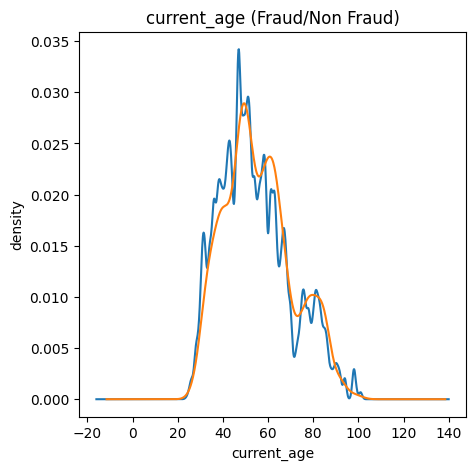

In [27]:
plt.figure(figsize=(5,5))
df[df["fraud"]==0]["current_age"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"]==1]["current_age"].plot(kind="kde", label="Fraud")
plt.xlabel("current_age")
plt.title("current_age (Fraud/Non Fraud)")
plt.ylabel("density")
plt.show()

**male**

In [28]:
df.groupby("fraud")["male"].mean()

fraud
0    0.489206
1    0.482830
Name: male, dtype: float64

### **4.2 Income & Financial Status**

**per_capita_income**

In [30]:
col = "per_capita_income"

# 기본 통계
desc = df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
print("=== Basic Stats ===")
print(desc)

# fraud 그룹별 평균/중앙값
grp_stats = (
    df.groupby(LABEL)[col]
      .agg(["count", "mean", "median", "std"])
)
print("\n=== Group Stats (by fraud) ===")
print(grp_stats)

=== Basic Stats ===
count    5.312525e+06
mean     2.403822e+04
std      1.197004e+04
min      0.000000e+00
1%       1.103600e+04
5%       1.309300e+04
25%      1.714200e+04
50%      2.117800e+04
75%      2.737600e+04
95%      4.513200e+04
99%      7.420500e+04
max      1.631450e+05
Name: per_capita_income, dtype: float64

=== Group Stats (by fraud) ===
         count          mean   median           std
fraud                                              
0      5304837  24039.869141  21178.0  11971.873047
1         7688  22911.125000  20542.0  10568.527344


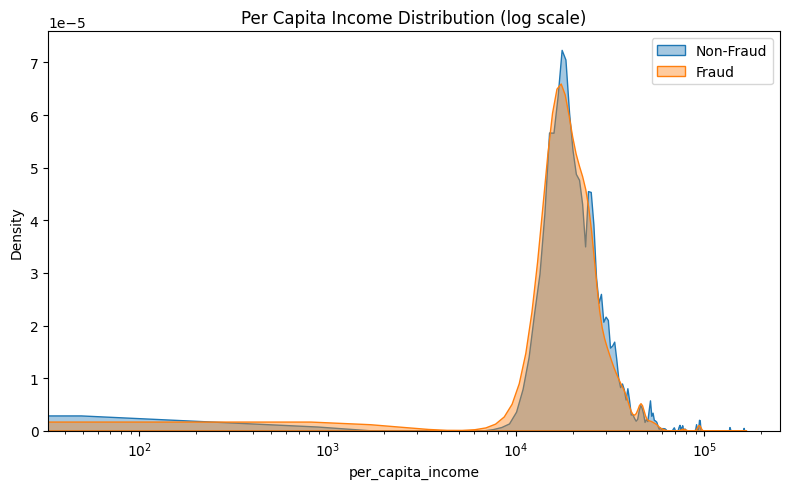

In [31]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df[df[LABEL]==0],
    x=col,
    label="Non-Fraud",
    fill=True,
    alpha=0.4
)

sns.kdeplot(
    data=df[df[LABEL]==1],
    x=col,
    label="Fraud",
    fill=True,
    alpha=0.4
)

plt.xscale("log") 
plt.title("Per Capita Income Distribution (log scale)")
plt.legend()
plt.tight_layout()
plt.show()


**yearly_income**


In [32]:
df["yearly_income"].describe()

count    5.312525e+06
mean     4.677138e+04
std      2.444741e+04
min      1.000000e+00
25%      3.281700e+04
50%      4.109100e+04
75%      5.401300e+04
max      2.801990e+05
Name: yearly_income, dtype: float64

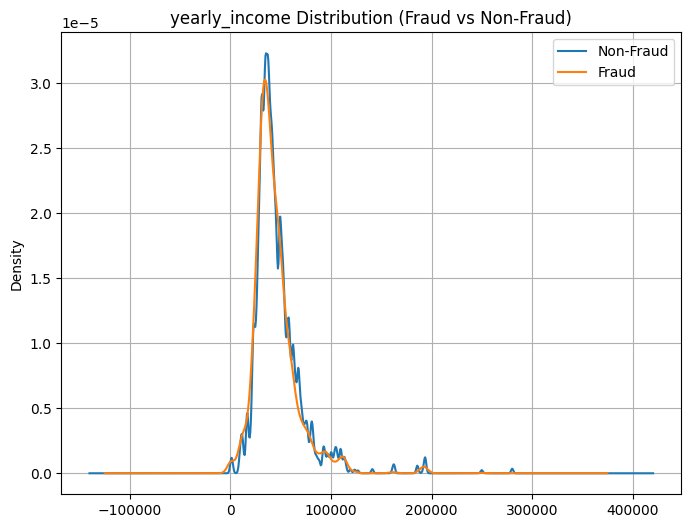

In [33]:
plt.figure(figsize=(8,6))
df[df["fraud"]==0]["yearly_income"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"]==1]["yearly_income"].plot(kind="kde", label="Fraud")
plt.title("yearly_income Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
low_vals = [1,0, 2.0, 4.0, 399.0, 553.0, 645.0, 920.0, 1426.0]

(df[df["yearly_income"].isin(low_vals)]
 .groupby("yearly_income")["fraud"]
 .agg(["count","mean"])
 .sort_index())

,count,mean
yearly_income,,
1.0,2248,0.000000
2.0,247,0.000000
4.0,12,0.166667
399.0,960,0.031250
553.0,845,0.007101
645.0,1601,0.003123
920.0,2709,0.002215
1426.0,7930,0.000000


> 비현실적인 연소득이 존재해서 flag 필요

In [36]:
df["low_income_flag"] = (df["yearly_income"] < 1000).astype("int8")

**log_yearly_income**


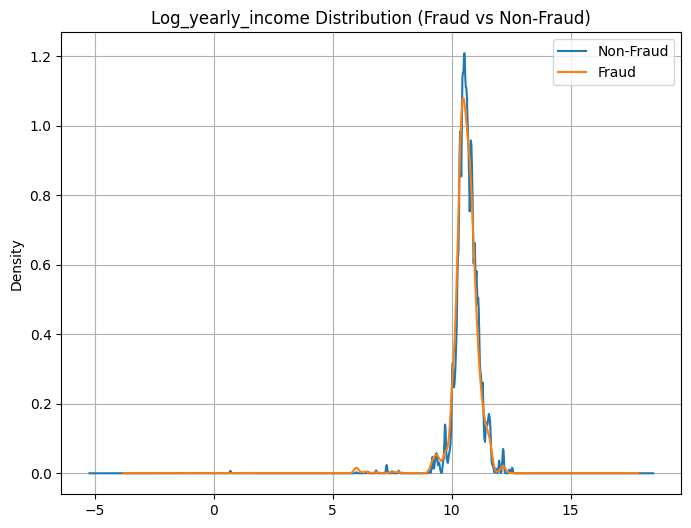

In [37]:
plt.figure(figsize=(8,6))
df[df["fraud"]==0]["log_yearly_income"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"]==1]["log_yearly_income"].plot(kind="kde", label="Fraud")
plt.title("Log_yearly_income Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_829721/2217625789.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_rate = df.groupby("log_income_bin")["fraud"].mean()


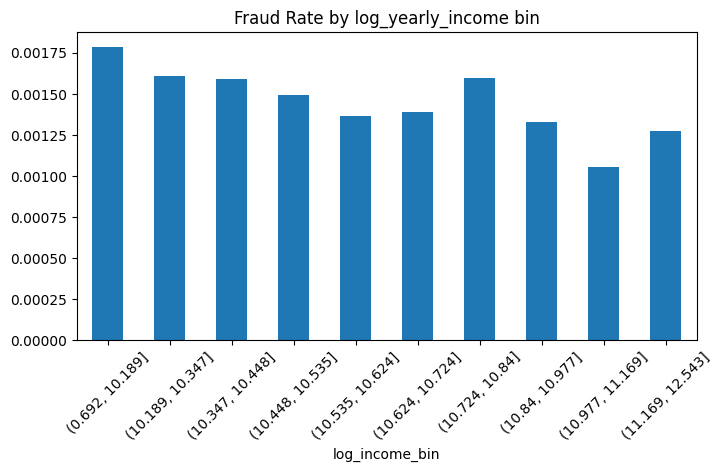

In [42]:
df["log_income_bin"] = pd.qcut(df["log_yearly_income"], 10, duplicates="drop")

bin_rate = df.groupby("log_income_bin")["fraud"].mean()

plt.figure(figsize=(8,4))
bin_rate.plot(kind="bar")
plt.title("Fraud Rate by log_yearly_income bin")
plt.xticks(rotation=45)
plt.show()


**income_ratio_region**

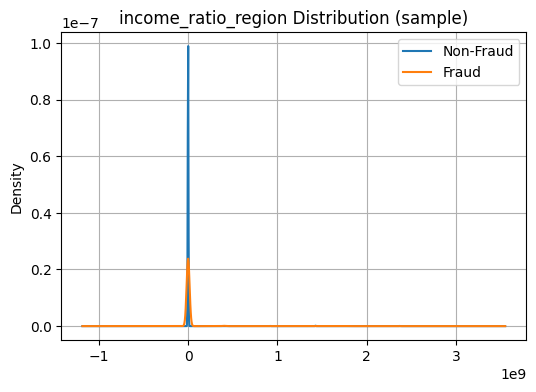

In [38]:
plt.figure(figsize=(6,4))

df[df["fraud"] == 0]["income_ratio_region"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"] == 1]["income_ratio_region"].plot(kind="kde", label="Fraud")

plt.title("income_ratio_region Distribution (sample)")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_829721/2401710794.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_rate = df.groupby("income_region_bin")["fraud"].mean()


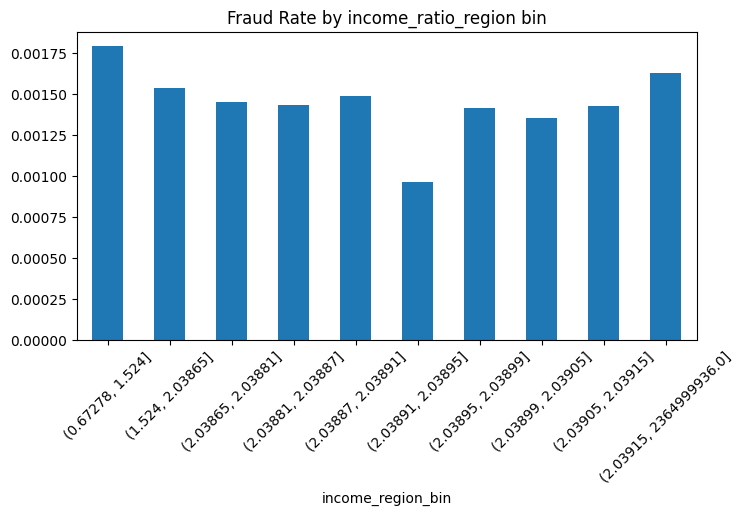

In [39]:
df["income_region_bin"] = pd.qcut(df["income_ratio_region"], 10, duplicates="drop")

bin_rate = df.groupby("income_region_bin")["fraud"].mean()

plt.figure(figsize=(8,4))
bin_rate.plot(kind="bar")
plt.title("Fraud Rate by income_ratio_region bin")
plt.xticks(rotation=45)
plt.show()

In [40]:
df.groupby("fraud")["income_ratio_region"].describe()

,count,mean,std,min,25%,50%,75%,max
fraud,,,,,,,,
0,5304837.0,4598680.5,84800120.0,0.672793,2.038750,2.038908,2.039014,2.365000e+09
1,7688.0,7062437.0,99184496.0,0.672793,2.038717,2.038897,2.039016,2.365000e+09


**log_income_ratio_region**


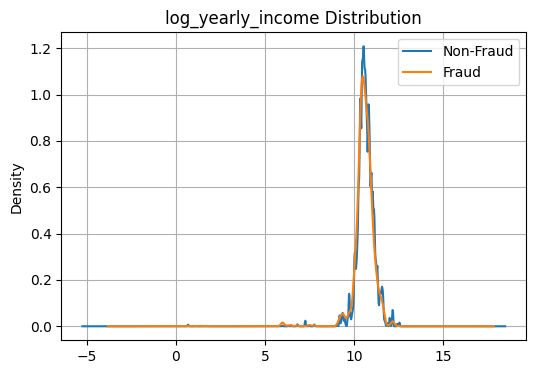

In [41]:
plt.figure(figsize=(6,4))

df[df["fraud"] == 0]["log_yearly_income"].plot(kind="kde", label="Non-Fraud")
df[df["fraud"] == 1]["log_yearly_income"].plot(kind="kde", label="Fraud")

plt.title("log_yearly_income Distribution")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_829721/2237376754.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_rate = df.groupby("log_income_region_bin")["fraud"].mean()


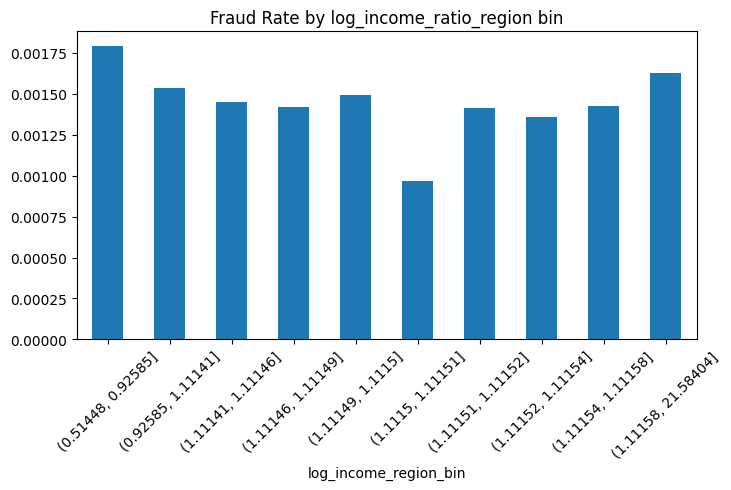

In [43]:
df["log_income_region_bin"] = pd.qcut(df["log_income_ratio_region"], 10, duplicates="drop")

bin_rate = df.groupby("log_income_region_bin")["fraud"].mean()

plt.figure(figsize=(8,4))
bin_rate.plot(kind="bar")
plt.title("Fraud Rate by log_income_ratio_region bin")
plt.xticks(rotation=45)
plt.show()

In [44]:
df.groupby("fraud")["log_income_ratio_region"].describe()

,count,mean,std,min,25%,50%,75%,max
fraud,,,,,,,,
0,5304837.0,1.146866,1.197011,0.514495,1.111446,1.111498,1.111533,21.584044
1,7688.0,1.224563,1.744831,0.514495,1.111435,1.111495,1.111534,21.584044


**total_debt**

In [45]:
df["total_debt"].describe()

count    5.312525e+06
mean     5.798938e+04
std      5.194811e+04
min      0.000000e+00
25%      1.652400e+04
50%      5.167900e+04
75%      8.516000e+04
max      4.618540e+05
Name: total_debt, dtype: float64

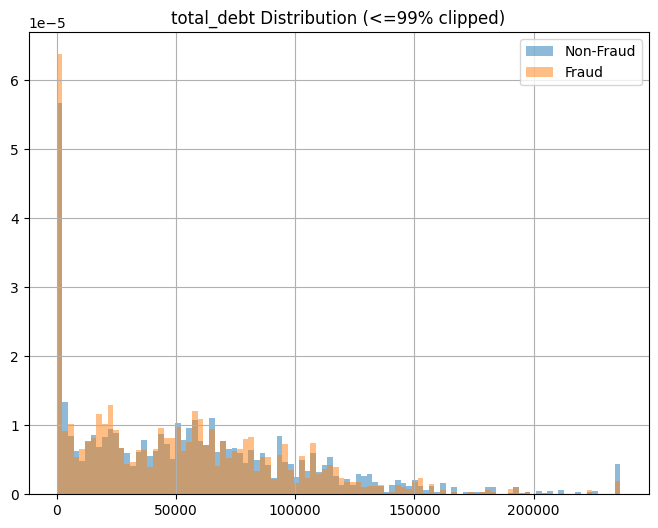

In [46]:
non = df[df["fraud"]==0].copy()
fraud = df[df["fraud"]==1].copy()

col = "total_debt"

non = df.loc[df["fraud"] == 0, col].dropna()
fraud = df.loc[df["fraud"] == 1, col].dropna()

xmax = df[col].quantile(0.99)
non = non.clip(upper=xmax)
fraud = fraud.clip(upper=xmax)

plt.figure(figsize=(8,6))
plt.hist(non, bins=100, alpha=0.5, label="Non-Fraud", density=True)
plt.hist(fraud, bins=100, alpha=0.5, label="Fraud", density=True)
plt.legend()
plt.title(f"{col} Distribution (<=99% clipped)")
plt.grid(True)
plt.show()


**credit_score**

In [47]:
df["credit_score"].describe()

count    5.312525e+06
mean     7.139093e+02
std      6.588546e+01
min      4.880000e+02
25%      6.840000e+02
50%      7.160000e+02
75%      7.560000e+02
max      8.500000e+02
Name: credit_score, dtype: float64

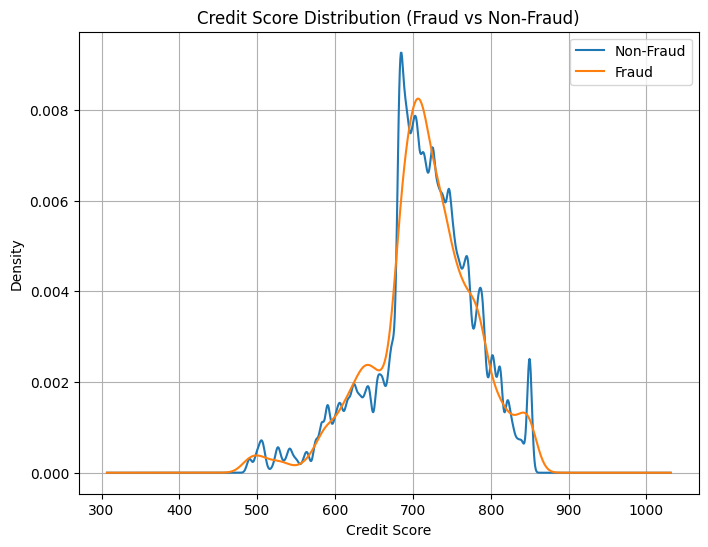

In [48]:
plt.figure(figsize=(8,6))

df[df["fraud"]==0]["credit_score"].plot(
    kind="kde", label="Non-Fraud"
)
df[df["fraud"]==1]["credit_score"].plot(
    kind="kde", label="Fraud"
)

plt.title("Credit Score Distribution (Fraud vs Non-Fraud)")
plt.xlabel("Credit Score")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


## 4.3 Card Holdings

- num_credit_cards

- num_cards_issued

- credit_limit

**num_credit_cards**

In [49]:
p = (
    df.groupby(["fraud", "num_credit_cards"])
      .size()
      .groupby(level=0)
      .apply(lambda x: x / x.sum())
      .unstack(fill_value=0)
)

p

,num_credit_cards,1,2,3,4,5,6,7,8,9
fraud,fraud,,,,,,,,,
0,0,0.066878,0.126279,0.227335,0.266363,0.169338,0.090123,0.036630,0.015492,0.001561
1,1,0.039282,0.118106,0.207596,0.257024,0.189906,0.106790,0.046176,0.029787,0.005333


In [50]:
df.groupby("num_credit_cards")["fraud"].agg(
    ["count", "mean"]
)

,count,mean
num_credit_cards,,
1,355079,0.000851
2,670798,0.001354
3,1207570,0.001322
4,1414987,0.001396
5,899772,0.001623
6,478911,0.001714
7,194672,0.001824
8,82414,0.002779
9,8322,0.004927


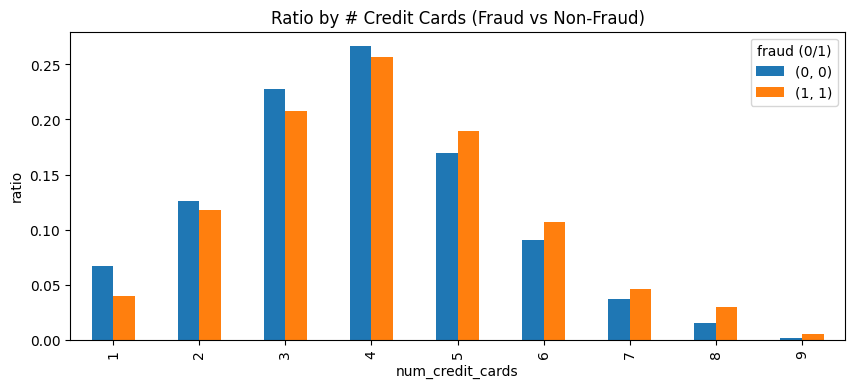

In [51]:
p = p.T
ax = p.sort_index().plot(kind="bar", figsize=(10,4))
ax.set_xlabel("num_credit_cards")
ax.set_ylabel("ratio")
ax.set_title("Ratio by # Credit Cards (Fraud vs Non-Fraud)")
ax.legend(title="fraud (0/1)")

**num_cards_issued**

In [52]:
p = (
    df.groupby(["fraud", "num_cards_issued"])
      .size()
      .groupby(level=0)
      .apply(lambda x: x / x.sum())
      .unstack(fill_value=0)
)

p

,num_cards_issued,1,2,3
fraud,fraud,,,
0,0,0.486670,0.50526,0.008070
1,1,0.488814,0.49974,0.011446


**credit_limit**

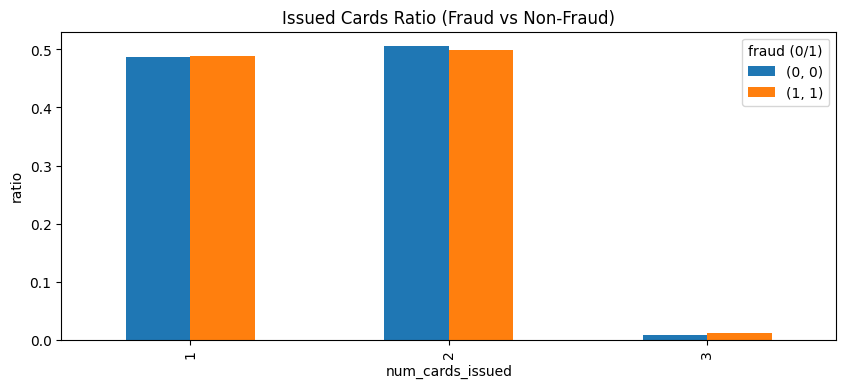

In [53]:
p = p.T
ax = p.sort_index().plot(kind="bar", figsize=(10,4))
ax.set_xlabel("num_cards_issued")
ax.set_ylabel("ratio")
ax.set_title("Issued Cards Ratio (Fraud vs Non-Fraud)")
ax.legend(title="fraud (0/1)")

**credit_limit**

In [54]:
df["credit_limit"].describe()

count    5.312525e+06
mean     1.553420e+04
std      1.218877e+04
min      1.000000e+00
25%      8.100000e+03
50%      1.343400e+04
75%      2.082700e+04
max      1.413910e+05
Name: credit_limit, dtype: float64

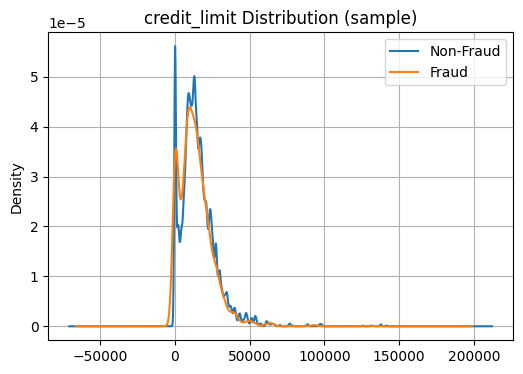

In [55]:
sample_df = df.copy()
plt.figure(figsize=(6,4))

sample_df[sample_df["fraud"] == 0]["credit_limit"].plot(kind="kde", label="Non-Fraud")
sample_df[sample_df["fraud"] == 1]["credit_limit"].plot(kind="kde", label="Fraud")

plt.title("credit_limit Distribution (sample)")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_829721/3149035856.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("limit_bin")["fraud"].mean().plot(kind="bar", figsize=(8,4))


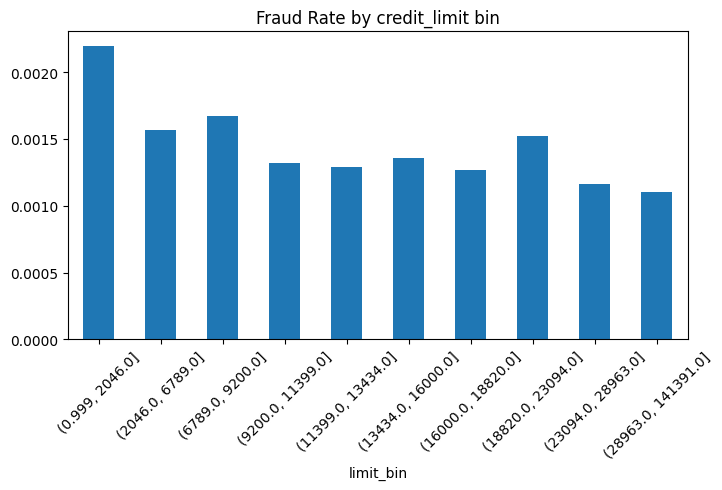

In [56]:
df["limit_bin"] = pd.qcut(df["credit_limit"], 10, duplicates="drop")
df.groupby("limit_bin")["fraud"].mean().plot(kind="bar", figsize=(8,4))
plt.title("Fraud Rate by credit_limit bin")
plt.xticks(rotation=45)
plt.show()

### **4.4 Account Age & Lifecycle**

- months_from_account

- year_pin_last_changed

- years_since_pin_change

- years_to_retirement


**months_from_account**

In [64]:
df["months_from_account"].describe()

count    5.312525e+06
mean     6.807525e+01
std      4.576855e+01
min      0.000000e+00
25%      3.300000e+01
50%      6.100000e+01
75%      9.600000e+01
max      2.990000e+02
Name: months_from_account, dtype: float64

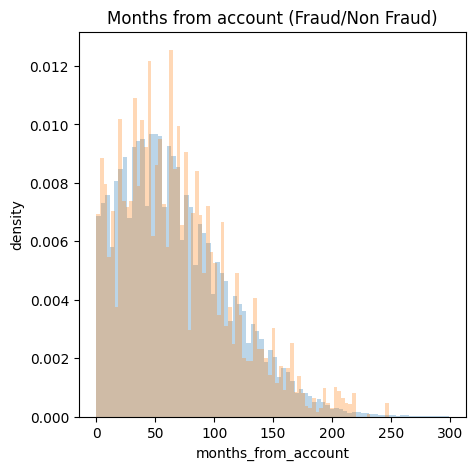

In [65]:
non = df[df["fraud"]==0]
fraud = df[df["fraud"]==1]

plt.figure(figsize=(5,5))
plt.hist(non["months_from_account"], bins=80, density=True, alpha=0.3, label="Non-Fraud")
plt.hist(fraud["months_from_account"], bins=80, density=True, alpha=0.3, label="Fraud")
plt.xlabel("months_from_account")
plt.title("Months from account (Fraud/Non Fraud)")
plt.ylabel("density")
plt.show()

**year_pin_last_changed**

In [68]:
df["year_pin_last_changed"].describe()

count      5312525.0
mean     2011.133453
std         2.834757
min           2002.0
25%           2009.0
50%           2011.0
75%           2013.0
max           2020.0
Name: year_pin_last_changed, dtype: Float64

**years_since_pin_change**

In [69]:
df["years_since_pin_change"] = df["tx_year"] - df["year_pin_last_changed"]
col = "years_since_pin_change"

print("Using column:", col)

Using column: years_since_pin_change


In [70]:
desc = df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
print("=== Basic Stats ===")
print(desc)

grp_stats = (
    df.groupby(LABEL)[col]
      .agg(["count", "mean", "median", "std"])
)
print("\n=== Group Stats (by fraud) ===")
print(grp_stats)


=== Basic Stats ===
count    5312525.0
mean      1.428795
std       3.226868
min          -10.0
1%            -7.0
5%            -4.0
25%            0.0
50%            2.0
75%            4.0
95%            6.0
99%            8.0
max           13.0
Name: years_since_pin_change, dtype: Float64

=== Group Stats (by fraud) ===
         count      mean  median       std
fraud                                     
0      5304837  1.428588     2.0  3.226723
1         7688   1.57154     2.0  3.322535


음수 -> PIN 변경 연도가 거래 연도보다 미래에 있음


In [75]:
df["years_since_pin_change"] = df["years_since_pin_change"].clip(lower=0)

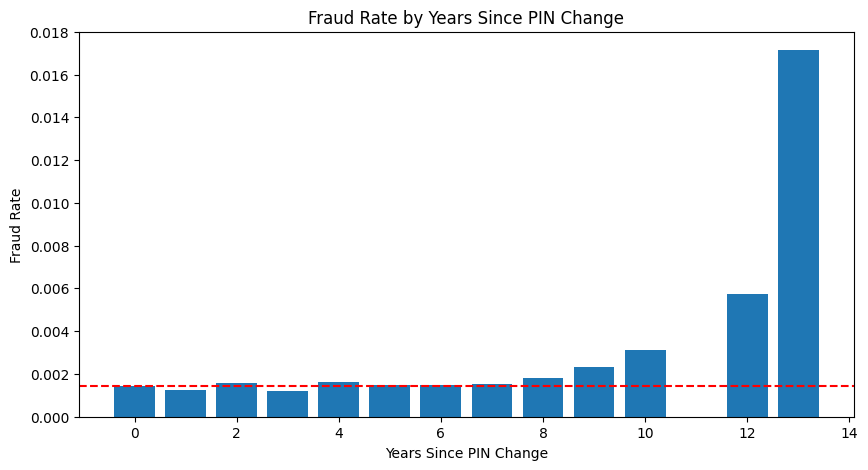

In [78]:
tmp = df[["years_since_pin_change", "fraud"]].dropna().copy()

rate_table = (
    tmp.groupby("years_since_pin_change")["fraud"]
       .agg(["count", "mean"])
       .reset_index()
)

base_rate = tmp["fraud"].mean()
rate_table["lift"] = rate_table["mean"] / base_rate

plt.figure(figsize=(10,5))
plt.bar(rate_table["years_since_pin_change"], rate_table["mean"])
plt.axhline(base_rate, color="red", linestyle="--")
plt.title("Fraud Rate by Years Since PIN Change")
plt.xlabel("Years Since PIN Change")
plt.ylabel("Fraud Rate")
plt.show()


In [79]:
rate_table = (
    df.groupby("years_since_pin_change")["fraud"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

rate_table["lift"] = rate_table["mean"] / df["fraud"].mean()

print(rate_table.sort_values("years_since_pin_change"))


    years_since_pin_change    count   sum      mean       lift
0                        0  1838692  2660  0.001447   0.999678
1                        1   759196   954  0.001257   0.868325
2                        2   714323  1126  0.001576   1.089260
3                        3   641655   786  0.001225   0.846464
4                        4   538255   864  0.001605   1.109209
5                        5   364715   540  0.001481   1.023123
6                        6   217175   322  0.001483   1.024551
7                        7   123083   189  0.001536   1.061088
8                        8    63536   114  0.001794   1.239860
9                        9    29048    68  0.002341   1.617634
10                      10    12758    40  0.003135   2.166531
11                      11     6095     0  0.000000   0.000000
12                      12     3819    22  0.005761   3.980711
13                      13      175     3  0.017143  11.845975


선형 변수로 쓰면 안 됨
binning해서 써야 함

In [83]:
df["pin_age_group"] = pd.cut(
    df["years_since_pin_change"],
    bins=[-100, 2, 7, 10, 20],
    labels=["0-2", "3-7", "8-10", "10+"]
)

In [84]:
df.drop("years_since_pin_change", axis=1, inplace=True)

In [85]:
group_table = (
    df.groupby("pin_age_group")[LABEL]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

base_rate = df[LABEL].mean()
group_table["lift"] = group_table["mean"] / base_rate

print(group_table)

/tmp/ipykernel_829721/774970047.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("pin_age_group")[LABEL]


  pin_age_group    count   sum      mean      lift
0           0-2  3312211  4740  0.001431  0.988890
1           3-7  1884883  2701  0.001433  0.990211
2          8-10   105342   222  0.002107  1.456260
3           10+    10089    25  0.002478  1.712299


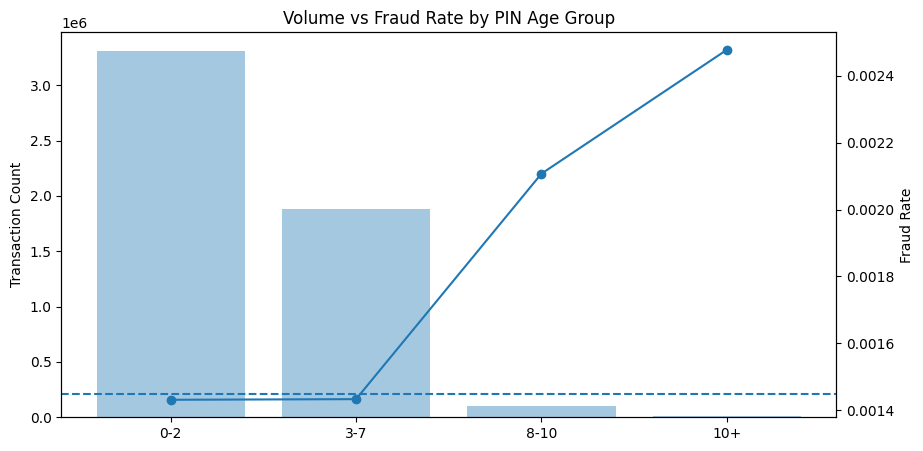

In [86]:
fig, ax1 = plt.subplots(figsize=(10,5))

# 거래 수
ax1.bar(group_table["pin_age_group"], group_table["count"], alpha=0.4)
ax1.set_ylabel("Transaction Count")

# fraud rate
ax2 = ax1.twinx()
ax2.plot(group_table["pin_age_group"], group_table["mean"], marker="o")
ax2.axhline(base_rate, linestyle="--")
ax2.set_ylabel("Fraud Rate")

plt.title("Volume vs Fraud Rate by PIN Age Group")
plt.show()


In [87]:
df.drop("pin_age_group", axis=1, inplace=True)

**years_to_retirement**

In [88]:
col = "years_to_retirement"

# 기본 통계
desc = df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
print("=== Basic Stats ===")
print(desc)

# 결측률
print("\nMissing rate:", df[col].isna().mean())

# fraud 그룹별 통계
grp_stats = (
    df.groupby(LABEL)[col]
      .agg(["count", "mean", "median", "std"])
)
print("\n=== Group Stats (by fraud) ===")
print(grp_stats)


=== Basic Stats ===
count    5.312525e+06
mean     1.478647e+01
std      1.204018e+01
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
25%      2.000000e+00
50%      1.500000e+01
75%      2.400000e+01
95%      3.500000e+01
99%      4.100000e+01
max      4.800000e+01
Name: years_to_retirement, dtype: float64

Missing rate: 0.0

=== Group Stats (by fraud) ===
         count       mean  median        std
fraud                                       
0      5304837  14.788670    15.0  12.040632
1         7688  13.266909    12.0  11.626915


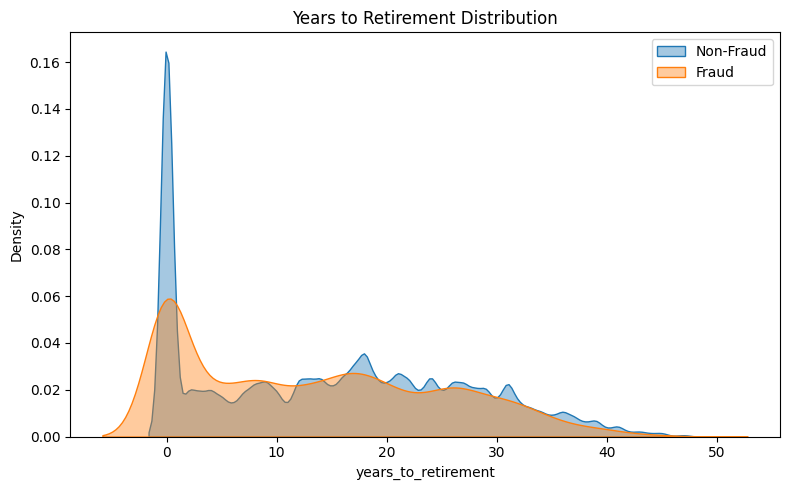

In [89]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df[df[LABEL]==0],
    x=col,
    label="Non-Fraud",
    fill=True,
    alpha=0.4
)

sns.kdeplot(
    data=df[df[LABEL]==1],
    x=col,
    label="Fraud",
    fill=True,
    alpha=0.4
)

plt.title("Years to Retirement Distribution")
plt.legend()
plt.tight_layout()
plt.show()

## 4.5 Expiry Information

- expires_year

- expires_month

- months_to_expire

In [ ]:
df.drop(columns=["expiers_year", "expiers_month"], inplace=True)

In [61]:
col = "months_to_expire"
desc = df[col].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
print("=== Basic Stats ===")
print(desc)

na_rate = df[col].isna().mean()
print(f"\nMissing rate: {na_rate:.4%}")

grp_stats = (
    df.groupby(LABEL)[col]
      .agg(["count", "mean", "median", "std"])
)
print("\n=== Group Stats (by fraud) ===")
print(grp_stats)

=== Basic Stats ===
count    5.312525e+06
mean     1.031152e+02
std      3.575659e+01
min      0.000000e+00
1%       6.000000e+00
5%       3.100000e+01
25%      8.200000e+01
50%      1.070000e+02
75%      1.280000e+02
95%      1.560000e+02
99%      1.690000e+02
max      1.790000e+02
Name: months_to_expire, dtype: float64

Missing rate: 0.0000%

=== Group Stats (by fraud) ===
         count        mean  median        std
fraud                                        
0      5304837  103.117252   107.0  35.752140
1         7688  101.680151   105.0  38.678244


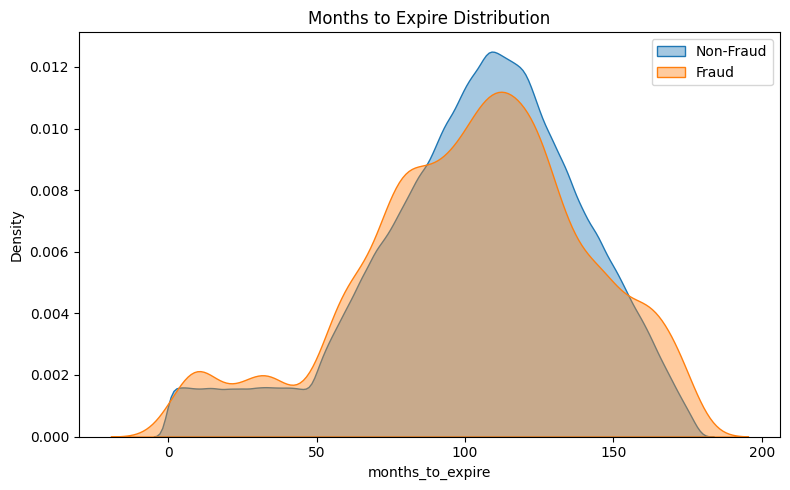

In [62]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df[df[LABEL]==0],
    x=col,
    label="Non-Fraud",
    fill=True,
    alpha=0.4
)

sns.kdeplot(
    data=df[df[LABEL]==1],
    x=col,
    label="Fraud",
    fill=True,
    alpha=0.4
)

plt.title("Months to Expire Distribution")
plt.legend()
plt.tight_layout()
plt.show()


   expire_decile   count      mean      lift
0              0  543024  0.001689  1.166912
1              1  548976  0.001574  1.087547
2              2  515517  0.001693  1.170197
3              3  536702  0.001241  0.857489
4              4  563886  0.001344  0.928893
5              5  527583  0.001374  0.949587
6              6  501951  0.001221  0.843892
7              7  522017  0.001293  0.893525
8              8  541206  0.001242  0.858014
9              9  511663  0.001808  1.249238


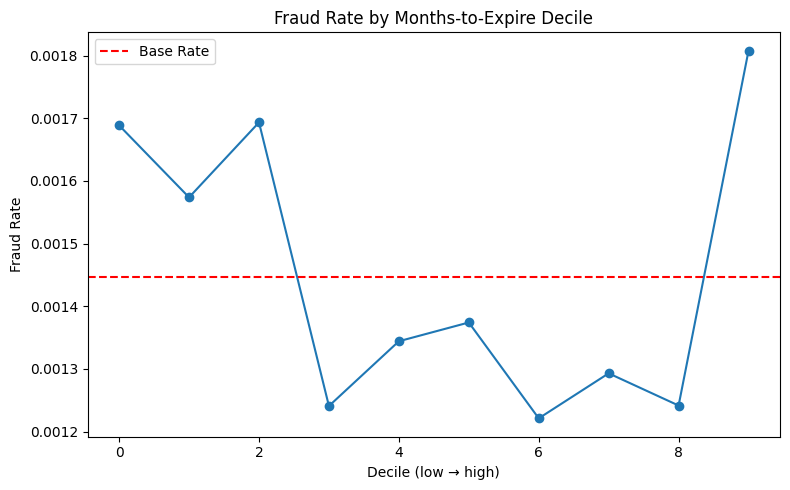

In [63]:
tmp = df[[col, LABEL]].dropna().copy()

tmp["expire_decile"] = pd.qcut(tmp[col], 10, labels=False, duplicates="drop")

rate_table = (
    tmp.groupby("expire_decile")[LABEL]
       .agg(["count", "mean"])
       .reset_index()
)

base_rate = tmp[LABEL].mean()
rate_table["lift"] = rate_table["mean"] / base_rate

print(rate_table)

plt.figure(figsize=(8,5))
plt.plot(rate_table["expire_decile"], rate_table["mean"], marker="o")
plt.axhline(base_rate, color="red", linestyle="--", label="Base Rate")
plt.title("Fraud Rate by Months-to-Expire Decile")
plt.xlabel("Decile (low → high)")
plt.ylabel("Fraud Rate")
plt.legend()
plt.tight_layout()
plt.show()


### **4.6 Statistical Validation (Quantitative Validation Layer)**

In [90]:
DEMOGRAPHICS = [
    "current_age",
    "male"
]

FINANCIAL = [
    "per_capita_income",
    "yearly_income",
    "log_yearly_income",
    "income_ratio_region",
    "log_income_ratio_region",
    "total_debt",
    "credit_score"
]

CARD_HOLDINGS = [
    "num_credit_cards",
    "num_cards_issued",
    "credit_limit"
]

LIFECYCLE = [
    "months_from_account",
    "years_to_retirement"
]

EXPIRY = [
    "expires_year",
    "expires_month",
    "months_to_expire"
]

ALL_STATIC = (
    DEMOGRAPHICS
    + FINANCIAL
    + CARD_HOLDINGS
    + LIFECYCLE
    + EXPIRY
)

In [91]:
results = []

for col in ALL_STATIC:

    X = sm.add_constant(df[[col]].dropna())
    y = df.loc[X.index, "fraud"]

    model = sm.Logit(y, X).fit(disp=0)

    coef = model.params[col]
    pval = model.pvalues[col]
    or_val = np.exp(coef)

    results.append([col, coef, or_val, pval])

uni_df = pd.DataFrame(
    results,
    columns=["feature","coef","OR","p_value"]
).sort_values("p_value")

display(uni_df)


,feature,coef,OR,p_value
9,num_credit_cards,1.101180e-01,1.116410,3.760647e-54
11,credit_limit,-1.523556e-05,0.999985,1.079906e-42
4,log_yearly_income,-1.803160e-01,0.835006,9.725622e-31
13,years_to_retirement,-1.073696e-02,0.989320,2.040876e-28
0,current_age,6.635993e-03,1.006658,1.018238e-20
7,total_debt,-2.222703e-06,0.999998,2.161809e-20
3,yearly_income,-5.007740e-06,0.999995,7.885687e-20
2,per_capita_income,-9.462675e-06,0.999991,9.619582e-17
6,log_income_ratio_region,3.716809e-02,1.037867,2.630295e-08
14,expires_year,-1.931181e-02,0.980873,4.938646e-06


좋다.
이 블록은 **정적 인구통계·재무 프로파일 변수**다.

이 변수들은 대부분 “개인 베이스 리스크”를 설명하지만
FDS에서는 **행동 변수 대비 영향력이 약한 편**이다.

기준:

* OR 크기
* 통계적 안정성
* 실질적 해석 가치
* Stage1 경량성

---

[High]

| feature             | OR     | p_value  | 해석                    |
| ------------------- | ------ | -------- | --------------------- |
| num_credit_cards    | 1.116  | 3.76e-54 | 카드 보유 수 ↑ → 복잡도·노출 증가 |
| log_yearly_income   | 0.835  | 9.73e-31 | 소득 높을수록 fraud 확률 감소   |
| years_to_retirement | 0.989  | 2.04e-28 | 고연령 안정성 효과            |
| current_age         | 1.0067 | 1.02e-20 | 연령 관련 리스크 구조          |

이 그룹은 **개인 리스크 baseline 형성용**으로 의미 있다.
Stage1 baseline 블록에 적합.

---

[Mid]

| feature                 | OR    | p_value | 해석                    |
| ----------------------- | ----- | ------- | --------------------- |
| credit_limit            | ~1    | 1e-42   | 금액 변수와 상호작용 가능        |
| total_debt              | ~1    | 2e-20   | 효과는 미세                |
| yearly_income           | ~1    | 7e-20   | log_yearly_income에 흡수 |
| per_capita_income       | ~1    | 9e-17   | 중복 가능                 |
| log_income_ratio_region | 1.038 | 2.6e-08 | 지역 대비 소득 편차           |

이 그룹은 정보가 있으나
**행동 변수 대비 기여도는 낮을 가능성 높음**
log 변수 하나만 유지하는 것이 깔끔하다.

---

[Low]

| feature             | OR   | p_value | 해석        |
| ------------------- | ---- | ------- | --------- |
| months_from_account | ~1   | 0.24    | 의미 없음     |
| male                | 0.97 | 0.26    | 통계적 불안정   |
| expires_month       | ~1   | 0.83    | 무의미       |
| num_cards_issued    | ~1   | 0.83    | 중복        |
| credit_score        | ~1   | 0.96    | 설명력 거의 없음 |
| income_ratio_region | ~1   | 0.01    | 효과 극히 미미  |

이 그룹은 제거해도 무방.

---

정리

Stage1 baseline 구성 추천:

유지:

* current_age
* num_credit_cards
* log_yearly_income
* years_to_retirement
* credit_limit (조건부)

제거:

* credit_score
* male
* expires_month
* num_cards_issued
* months_from_account

---

=> 행동 기반 변수보다 훨씬 약하다.

즉,
사기는 **사람의 프로파일이 아니라 행동에서 드러난다.**


---
# 5. Card & Channel Block

> 카드 유형/결제 수단 특성 기반 리스크

## 5.1 Card Type

- is_credit

- is_prepaid

(파생: card_type category)

## 5.2 Chip Capability

- has_chip

## 5.3 Card Brand One-hot

- cb_Visa

- cb_Mastercard

- cb_Amex

- cb_Discover

---

### **5.1 Card Type**

**is_credit**

In [96]:
df.groupby("is_credit")["fraud"].mean()

is_credit
0    0.001426
1    0.001494
Name: fraud, dtype: float64

**is_prepaid**

In [97]:
df.groupby("is_prepaid")["fraud"].mean()

is_prepaid
0    0.001373
1    0.002438
Name: fraud, dtype: float64

In [123]:
df["card_type"] = np.select(
    [
        df["is_credit"] == 1,
        df["is_prepaid"] == 1
    ],
    [
        "credit",
        "debit(prepaid)"
    ],
    default="debit(non_prepaid)"
)

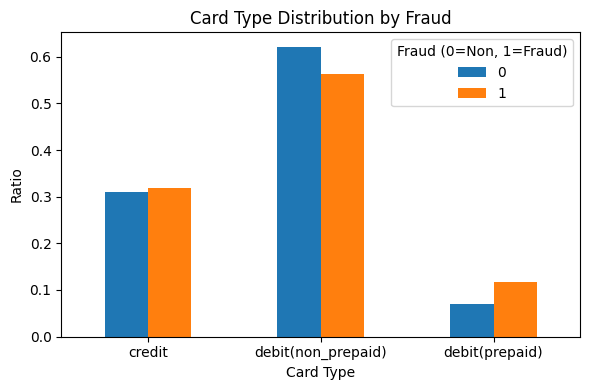

In [124]:
df["card_type"] = df["card_type"].astype("category")

card_ratio = (
    df.groupby("fraud")["card_type"]
      .value_counts(normalize=True)
      .unstack()
)

card_ratio.T.plot(kind="bar", figsize=(6,4))
plt.ylabel("Ratio")
plt.xlabel("Card Type")
plt.title("Card Type Distribution by Fraud")
plt.xticks(rotation=0)
plt.legend(title="Fraud (0=Non, 1=Fraud)")
plt.tight_layout()
plt.show()

In [100]:
fraud_rate = (
    df.groupby("card_type")["fraud"]
      .mean()
      .sort_values(ascending=False)
)
fraud_rate

/tmp/ipykernel_829721/1246485000.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("card_type")["fraud"]


card_type
debit(prepaid)        0.002438
credit                0.001494
debit(non_prepaid)    0.001313
Name: fraud, dtype: float64

*왜 prepaid가 더 높을까*

In [101]:
df["is_prepaid"] = (df["card_type"] == "debit(prepaid)").astype("int8")

Text(0, 0.5, '')

/home/nakyung/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


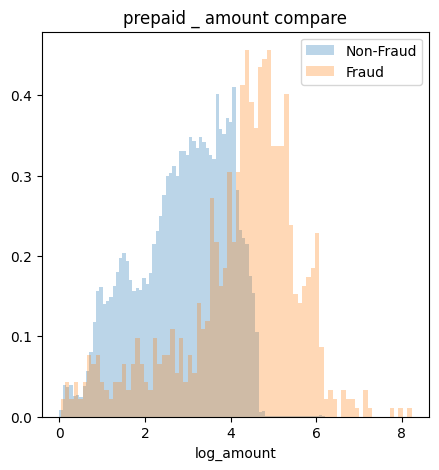

In [102]:
prepaid = df[df["card_type"]=="debit(prepaid)"].copy()

plt.figure(figsize=(5,5))
plt.hist(prepaid[prepaid["fraud"]==0]["log_abs_amount"], bins=80, density=True, alpha=0.3, label="Non-Fraud")
plt.hist(prepaid[prepaid["fraud"]==1]["log_abs_amount"], bins=80, density=True, alpha=0.3, label="Fraud")
plt.xlabel("log_amount")
plt.title("prepaid _ amount compare")
plt.legend()
plt.ylabel("")

In [125]:
df["prepaid_logamount_interaction"] = (
    (df["card_type"] == "debit(prepaid)").astype(int)
    * df["log_abs_amount"]
)

### **5.2 Chip Capability**

**has_chip**

In [106]:
df["has_chip"].value_counts()

has_chip
1    4777420
0     535105
Name: count, dtype: int64

In [107]:
df.groupby("has_chip")["fraud"].mean()

has_chip
0    0.001239
1    0.001470
Name: fraud, dtype: float64

### **5.3 Card Brand One-hot**

- `cb_Visa`
- `cb_Mastercard`
- `cb_Amex`
- `cb_Discover`

In [104]:
df["card_brand"] = np.select([
    df["cb_Visa"] == 1,
    df["cb_Mastercard"] == 1,
    df["cb_Amex"] == 1,
],
[
    "visa",
    "mastercard",
    "amex",
],
    default="discover"
)

In [105]:
p = (
    df.groupby(["card_brand", "fraud"])
      .size()
      .groupby(level=0)
      .apply(lambda x: x / x.sum())
      .unstack()
)
p

,fraud,0,1
card_brand,card_brand,,
amex,amex,0.998331,0.001669
discover,discover,0.997818,0.002182
mastercard,mastercard,0.998532,0.001468
visa,visa,0.998670,0.001330


In [119]:
df["discover_x_cvv"] = df["cb_Discover"] * df["err_bad_cvv"]

### **5.4 Statistical Validation (Quantitative Validation Layer)**

In [126]:
CARD_CANDIDATES = [
    # 5.1 Card Type
    "is_credit",
    "is_prepaid",

    # 5.2 Chip Capability
    "has_chip",
    "prepaid_logamount_interaction",
    
    # 5.3 Card Brand One-hot
    "cb_Visa",
    "cb_Mastercard",
    "cb_Amex",
    "cb_Discover",

    "discover_x_cvv"
]


In [127]:
def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

rows_uni = []

for col in CARD_CANDIDATES:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,cb_Visa,-0.131312,0.876945,4.686713e-08,0.001517,1.048095,3328837
1,is_credit,0.046325,1.047415,5.845039e-02,0.001494,1.032226,1643480
2,has_chip,0.171494,1.187077,2.460242e-05,0.001470,1.016110,4777420
3,cb_Mastercard,0.030657,1.031132,1.809597e-01,0.001468,1.014168,2850816
4,is_prepaid,0.574956,1.777053,7.783182e-59,0.001447,1.000000,5312525
5,prepaid_logamount_interaction,0.298174,1.347396,2.533406e-221,0.001447,1.000000,5312525
6,cb_Amex,0.153952,1.166434,3.678975e-04,0.001447,1.000000,5312525
7,cb_Discover,0.424373,1.528631,2.177581e-12,0.001447,1.000000,5312525
8,discover_x_cvv,3.934534,51.138325,3.173670e-14,0.001447,1.000000,5312525


In [128]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in CARD_CANDIDATES:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006117612512305813, 'top_decile_lift': 4.227363347026202, 'thr': 0.002807587535846677, 'top_n': 531253}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,cb_Amex,OK,0.159035,1.172379,8.425898e-04,0.001447,0.006123,4.231266,0.000006,0.003902,531253.0
1,discover_x_cvv,OK,2.871164,17.657559,5.522037e-08,0.001447,0.006108,4.220860,-0.000009,-0.006504,531253.0
2,cb_Discover,OK,0.419159,1.520682,3.192155e-11,0.001447,0.006104,4.218258,-0.000013,-0.009105,531253.0
3,cb_Visa,OK,-0.151745,0.859208,3.866991e-10,0.001447,0.006086,4.205243,-0.000032,-0.022120,531254.0
4,cb_Mastercard,OK,0.063358,1.065409,9.206561e-03,0.001447,0.006082,4.202650,-0.000036,-0.024714,531253.0
5,is_prepaid,OK,0.527186,1.694159,2.342903e-32,0.001447,0.006055,4.184439,-0.000062,-0.042924,531253.0
6,prepaid_logamount_interaction,OK,0.200231,1.221685,4.799227e-71,0.001447,0.006016,4.157116,-0.000102,-0.070247,531254.0
7,is_credit,SKIP (already in BASELINE),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,has_chip,SKIP (already in BASELINE),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


좋다.
이 블록은 **카드 타입 / 브랜드 구조 변수**다.

이미 baseline에

* is_credit
* has_chip

이 포함되어 있다고 가정하고 정리한다.

기준:

* Δ lift
* 구조적 중복 여부
* 실무적 안정성
* 행동 변수 대비 기여도

---

[High]

없음

이 블록에서 baseline 대비 **유의미하게 lift를 올리는 변수는 없다.**

---

[Mid]

| feature        | OR    | Δ Lift  | 해석               |
| -------------- | ----- | ------- | ---------------- |
| cb_Amex        | 1.17  | +0.0039 | 브랜드별 미세 차이       |
| discover_x_cvv | 17.66 | -0.0065 | 강한 OR지만 랭킹 개선 없음 |
| cb_Discover    | 1.52  | -0.0091 | 브랜드 효과 약함        |

브랜드 변수는 통계적으로 유의하지만
행동/히스토리 변수에 비해 기여도가 매우 낮다.

discover_x_cvv는 OR는 크지만
이미 err_bad_cvv + error 구조에 흡수됨.

---

[Low]

| feature                       | OR   | Δ Lift  | 해석            |
| ----------------------------- | ---- | ------- | ------------- |
| cb_Visa                       | 0.86 | -0.0221 | 브랜드별 분포 차이일 뿐 |
| cb_Mastercard                 | 1.07 | -0.0247 | 약함            |
| is_prepaid                    | 1.69 | -0.0429 | 행동 변수에 흡수     |
| prepaid_logamount_interaction | 1.22 | -0.0702 | 완전 중복         |

브랜드 변수는 “집단 평균 차이”일 가능성이 높고
사기 탐지의 핵심 신호는 아니다.

---

사기는 카드 종류보다
에러, 금액 이상치, 히스토리 패턴에서 훨씬 강하게 드러난다.



In [111]:
BRANDS = ["cb_Visa", "cb_Mastercard", "cb_Amex", "cb_Discover"]

# baseline + brand block
model_brand, y_b2, s_b2 = fit_logit_and_score(df, BASELINE + BRANDS, y_col=LABEL)
lift_brand = top_decile_lift(y_b2, s_b2)

print("\n=== BASELINE + BRAND BLOCK ===")
print(lift_brand)
print("Δlift vs baseline:", lift_brand["top_decile_lift"] - base_lift["top_decile_lift"])


=== BASELINE + BRAND BLOCK ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.0060818480083877175, 'top_decile_lift': 4.202649530535895, 'thr': 0.002819804586459778, 'top_n': 531253}
Δlift vs baseline: -0.024713816490306684


> is_prepared, cb_Discover, prepaid log amount interaction

> Discover 자체가 위험한 게 아니라\
> Discover는 고액에서 더 위험해진다.

---
# 6. MCC & Merchant Semantic Block

> 업종/상점 기반 구조적 리스크

## 6.1 Raw MCC

- mcc

## 6.2 MCC Behavioral Features (Client-Level)

- client_mcc_match_last1

- client_mcc_seen_last3

- client_mcc_seen_last5

- client_mcc_repeat_cnt_last3

- client_mcc_repeat_cnt_last5

- client_mcc_is_new

- client_mcc_change_cnt_last5

## 6.3 High Risk MCC

- mcc_is_highrisk (cutoff 기반 정의)

---

### **6.1 Raw MCC**

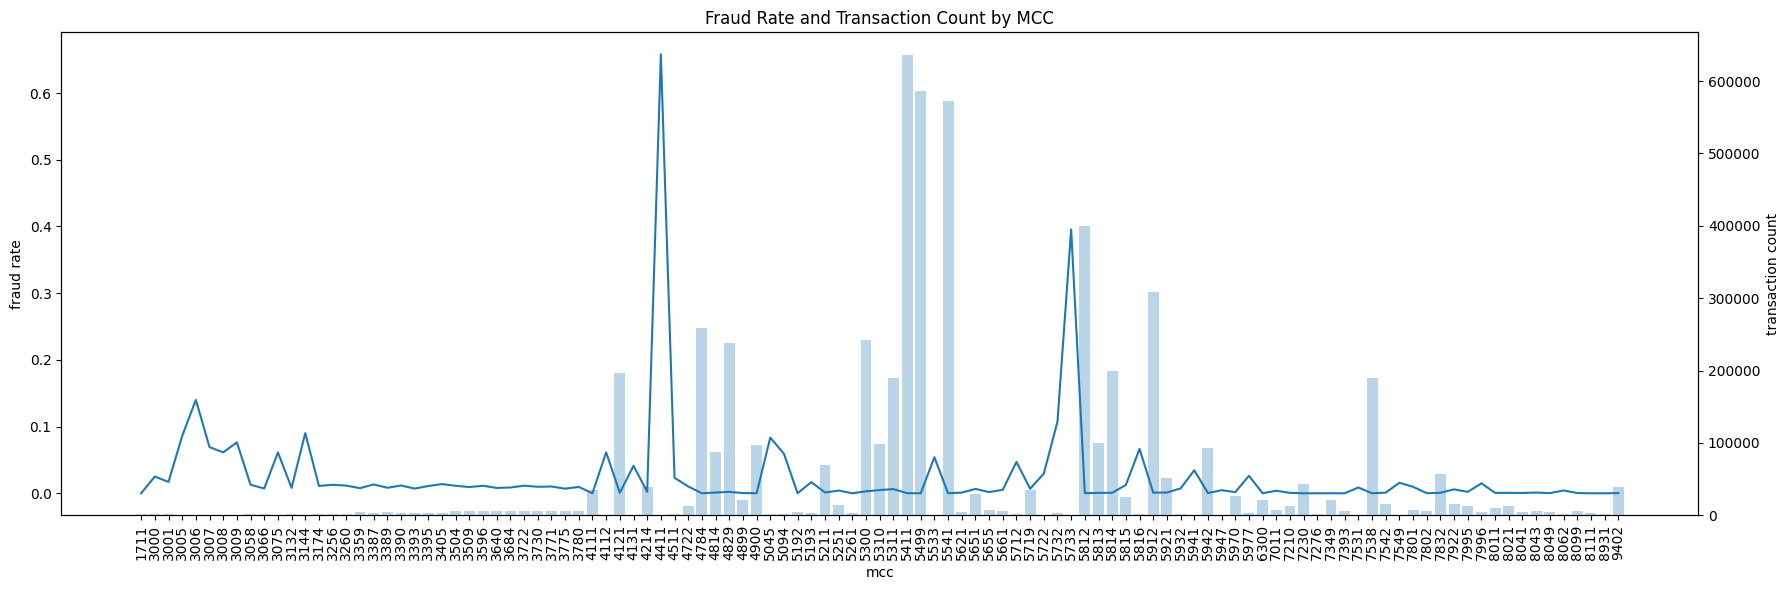

In [3]:
mcc_rate = df.groupby("mcc")["fraud"].mean()
mcc_count = df.groupby("mcc")["fraud"].count()

mcc_rate = mcc_rate.sort_index()
mcc_count = mcc_count.sort_index()

fig, ax1 = plt.subplots(figsize=(18,6))

# fraud rate
ax1.plot(mcc_rate.index.astype(str), mcc_rate.values)
ax1.set_xlabel("mcc")
ax1.set_ylabel("fraud rate")

ax1.set_xticks(range(len(mcc_rate)))
ax1.set_xticklabels(mcc_rate.index.astype(str), rotation=90)

# count
ax2 = ax1.twinx()
ax2.bar(range(len(mcc_count)), mcc_count.values, alpha=0.3)
ax2.set_ylabel("transaction count")

plt.title("Fraud Rate and Transaction Count by MCC")
plt.tight_layout()
plt.show()

In [5]:
mcc_data = pd.concat([mcc_rate, mcc_count], axis=1)
mcc_data.columns = ["fraud_rate", "tx_count"]
mcc_data = mcc_data.sort_values("fraud_rate", ascending=False)
mcc_data.head(10)

,fraud_rate,tx_count
mcc,,
4411,0.658163,196
5733,0.395522,134
3006,0.140000,150
5732,0.107561,2817
3144,0.090164,122
3005,0.085890,163
5045,0.083486,1090
3009,0.076389,144
3007,0.069182,159


- 4411: Cruise Lines
- 5733: Music Stores - Musical Instruments
- 3006: Miscellaneous Fabricated Metal Products

| mcc  | fraud_rate | tx_count | mcc |
| ---- | ---------- | -------- | -------- |
| 5732 | 0.107      | 2817     | Electronics Stores |
| 5045 | 0.083      | 1090     | Computers, Computer Peripheral Equipment |
| 5816 | 0.066      | 1143     | Digital Goods - Games |
| 5094 | 0.059      | 2077     | Precious Stones and Metals |
| 5712 | 0.046      | 1511     | Furniture, Home Furnishings, and Equipment Stores |
- 5732 — Electronics Stores

        전자제품 = 고가 + 재판매 용이 + 온라인 결제 빈번
        → 전형적인 카드 부정 사용 업종

- 5045 — Computers & Peripherals

        노트북, GPU, 부품
        → 고가 + 현금화 쉬움

- 5816 — Digital Goods (Games)

        디지털 아이템 = 배송 없음 + 즉시 소비
        → 도난 카드로 빠르게 전환 가능

- 5094 — Precious Stones & Metals

        금, 귀금속
        → 가치 저장 + 환금성

- 5712 — Furniture / Home Furnishing

        예상 외 결과

**[high mcc 관찰]**

**5732_Electronics Stores**

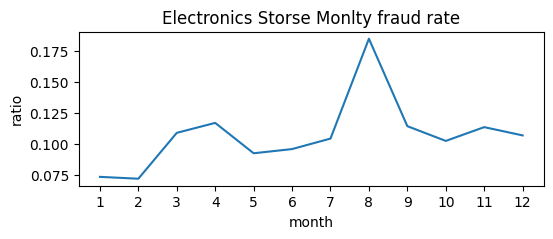

In [6]:
ES = df[df["mcc"]=="5732"].copy()
month = (
    ES
    .groupby("tx_month")[LABEL]
    .mean()
)
plt.figure(figsize=(6,2))
month.plot()
plt.xticks(month.index)
plt.xlabel("month")
plt.ylabel("ratio")
plt.title("Electronics Storse Monlty fraud rate")
plt.show()

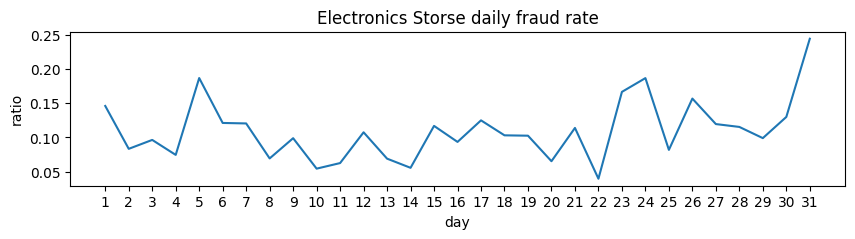

In [7]:
day = (
    ES
    .groupby("tx_day")[LABEL]
    .mean()
)
plt.figure(figsize=(10,2))
day.plot()
plt.xticks(day.index)
plt.xlabel("day")
plt.ylabel("ratio")
plt.title("Electronics Storse daily fraud rate")
plt.show()

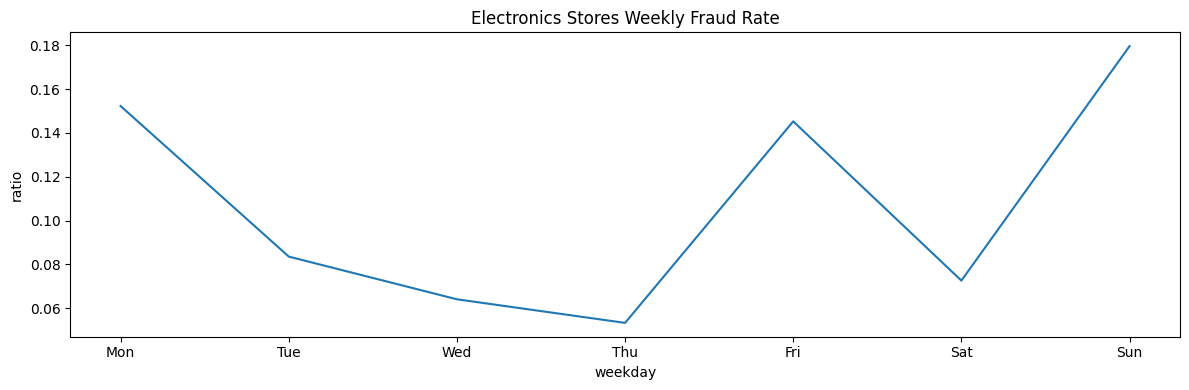

In [8]:
weekday_map = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

ES["weekday_name"] = ES["weekday"].map(weekday_map)

order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

week = (
    ES
    .groupby("weekday_name")[LABEL]
    .mean()
    .reindex(order)
)

plt.figure(figsize=(12,4))
week.plot()

plt.xlabel("weekday")
plt.ylabel("ratio")
plt.title("Electronics Stores Weekly Fraud Rate")
plt.tight_layout()
plt.show()


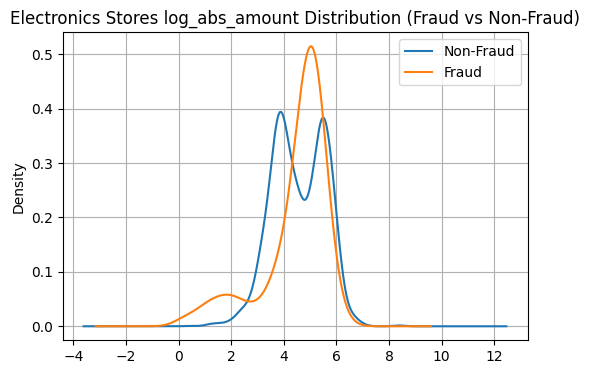

In [10]:
plt.figure(figsize=(6,4))
ES[ES["fraud"] == 0]["log_abs_amount"].plot(kind="kde", label="Non-Fraud")
ES[ES["fraud"] == 1]["log_abs_amount"].plot(kind="kde", label="Fraud")
plt.title(f"Electronics Stores log_abs_amount Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
ES.groupby("fraud")["is_credit"].mean()

fraud
0    0.403739
1    0.316832
Name: is_credit, dtype: float64

In [12]:
ES.groupby("fraud")["is_prepaid"].mean()

fraud
0    0.043357
1    0.118812
Name: is_prepaid, dtype: float64

In [13]:
ES.groupby(["is_credit","is_prepaid"])["fraud"].mean()

is_credit  is_prepaid
0          0             0.109545
           1             0.248276
1          0             0.086409
Name: fraud, dtype: float64

**5045_Computers, Computer Peripheral Equipment**

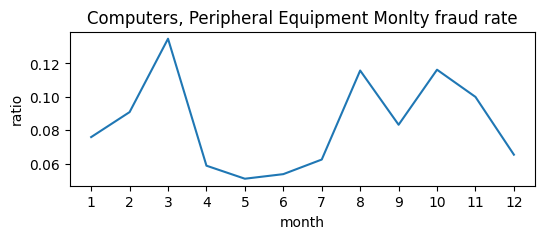

In [14]:
C = df[df["mcc"]=="5045"].copy()
month = (
    C
    .groupby("tx_month")[LABEL]
    .mean()
)
plt.figure(figsize=(6,2))
month.plot()
plt.xticks(month.index)
plt.xlabel("month")
plt.ylabel("ratio")
plt.title("Computers, Peripheral Equipment Monlty fraud rate")
plt.show()

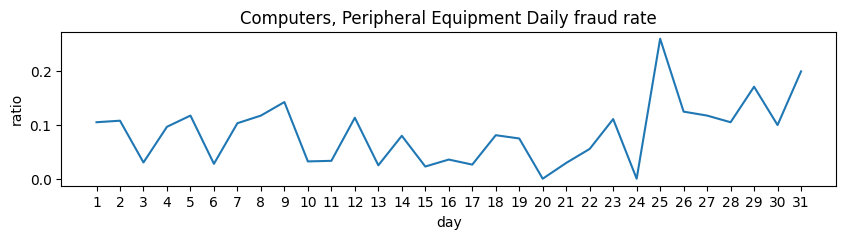

In [15]:
day = (
    C
    .groupby("tx_day")[LABEL]
    .mean()
)
plt.figure(figsize=(10,2))
day.plot()
plt.xticks(day.index)
plt.xlabel("day")
plt.ylabel("ratio")
plt.title("Computers, Peripheral Equipment Daily fraud rate")
plt.show()

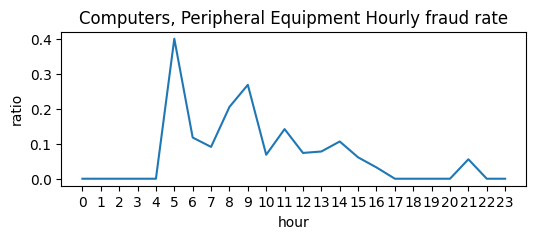

In [16]:
hour = (
    C
    .groupby("tx_hour")[LABEL]
    .mean()
)
plt.figure(figsize=(6,2))
hour.plot()
plt.xticks(hour.index)
plt.xlabel("hour")
plt.ylabel("ratio")
plt.title("Computers, Peripheral Equipment Hourly fraud rate")
plt.show()

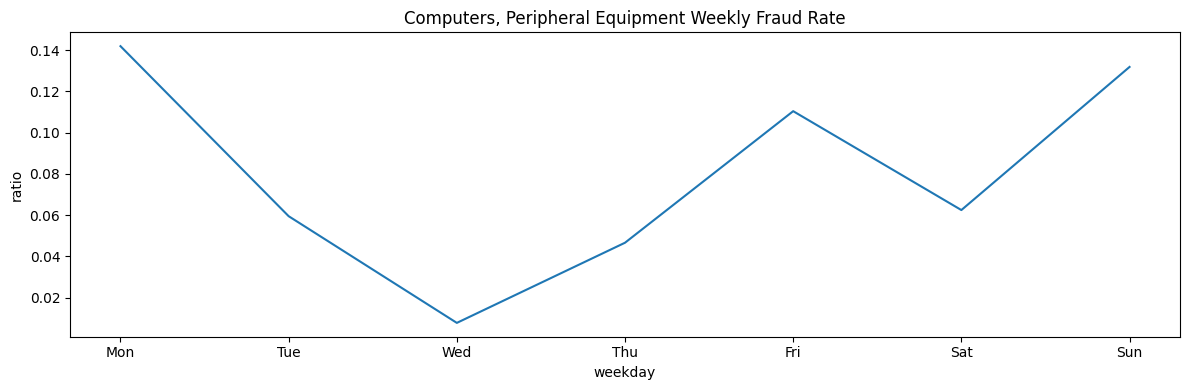

In [17]:
C["weekday_name"] = C["weekday"].map(weekday_map)

order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

week = (
    C
    .groupby("weekday_name")[LABEL]
    .mean()
    .reindex(order)
)

plt.figure(figsize=(12,4))
week.plot()

plt.xlabel("weekday")
plt.ylabel("ratio")
plt.title("Computers, Peripheral Equipment Weekly Fraud Rate")
plt.tight_layout()
plt.show()

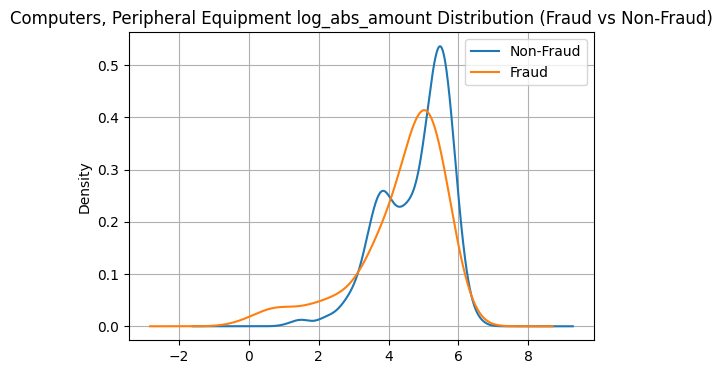

In [19]:
plt.figure(figsize=(6,4))
C[C["fraud"] == 0]["log_abs_amount"].plot(kind="kde", label="Non-Fraud")
C[C["fraud"] == 1]["log_abs_amount"].plot(kind="kde", label="Fraud")
plt.title(f"Computers, Peripheral Equipment log_abs_amount Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
print(C.groupby("is_credit")["fraud"].mean())
print(C.groupby("is_prepaid")["fraud"].mean())

is_credit
0    0.105096
1    0.054113
Name: fraud, dtype: float64
is_prepaid
0    0.076923
1    0.270270
Name: fraud, dtype: float64


**5816_Digital Goods - Games**

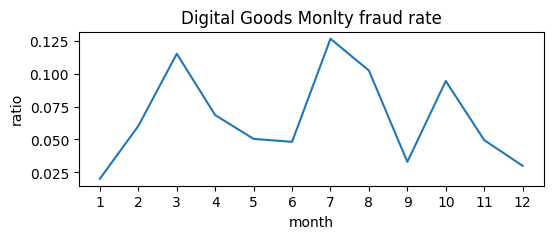

In [21]:
DG = df[df["mcc"]=="5816"].copy()
month = (
    DG
    .groupby("tx_month")[LABEL]
    .mean()
)
plt.figure(figsize=(6,2))
month.plot()
plt.xticks(month.index)
plt.xlabel("month")
plt.ylabel("ratio")
plt.title("Digital Goods Monlty fraud rate")
plt.show()

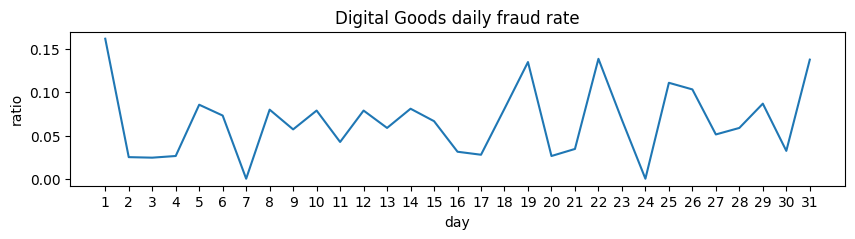

In [22]:
day = (
    DG
    .groupby("tx_day")[LABEL]
    .mean()
)
plt.figure(figsize=(10,2))
day.plot()
plt.xticks(day.index)
plt.xlabel("day")
plt.ylabel("ratio")
plt.title("Digital Goods daily fraud rate")
plt.show()

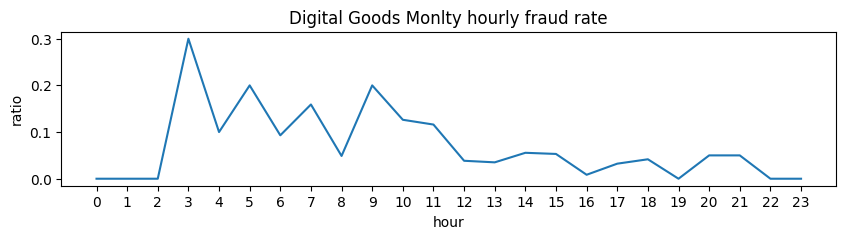

In [23]:
hour = (
    DG
    .groupby("tx_hour")[LABEL]
    .mean()
)
plt.figure(figsize=(10, 2))
hour.plot()
plt.xticks(hour.index)
plt.xlabel("hour")
plt.ylabel("ratio")
plt.title("Digital Goods Monlty hourly fraud rate")
plt.show()

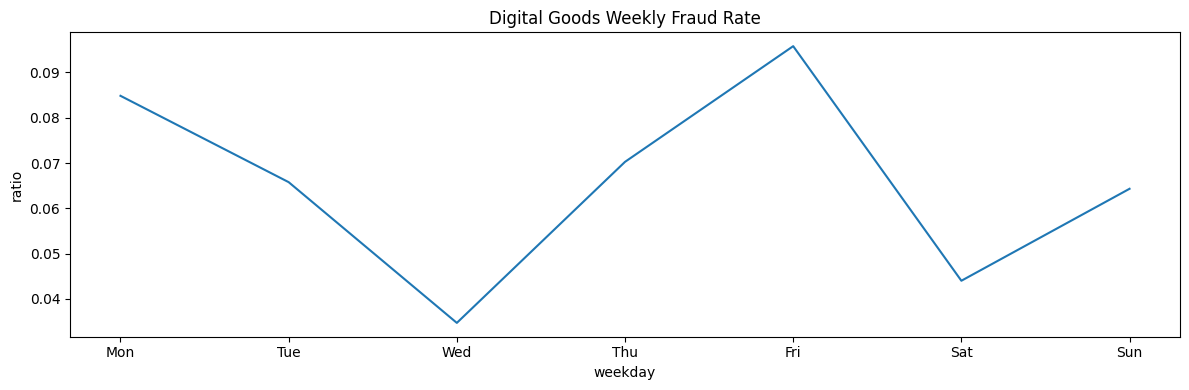

In [24]:
DG["weekday_name"] = DG["weekday"].map(weekday_map)

week = (
    DG
    .groupby("weekday_name")[LABEL]
    .mean()
    .reindex(order)
)

plt.figure(figsize=(12,4))
week.plot()

plt.xlabel("weekday")
plt.ylabel("ratio")
plt.title("Digital Goods Weekly Fraud Rate")
plt.tight_layout()
plt.show()

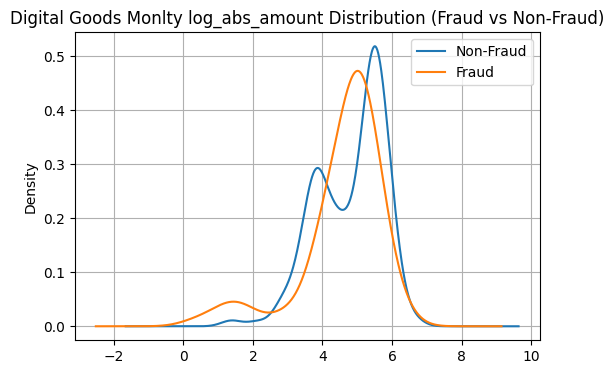

In [25]:
plt.figure(figsize=(6,4))
DG[DG["fraud"] == 0]["log_abs_amount"].plot(kind="kde", label="Non-Fraud")
DG[DG["fraud"] == 1]["log_abs_amount"].plot(kind="kde", label="Fraud")
plt.title(f"Digital Goods Monlty log_abs_amount Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
print(DG.groupby("is_credit")["fraud"].mean())
print()
print(DG.groupby("is_prepaid")["fraud"].mean())

is_credit
0    0.080997
1    0.047904
Name: fraud, dtype: float64

is_prepaid
0    0.062893
1    0.200000
Name: fraud, dtype: float64


**5094_Precious Stones and Metals**

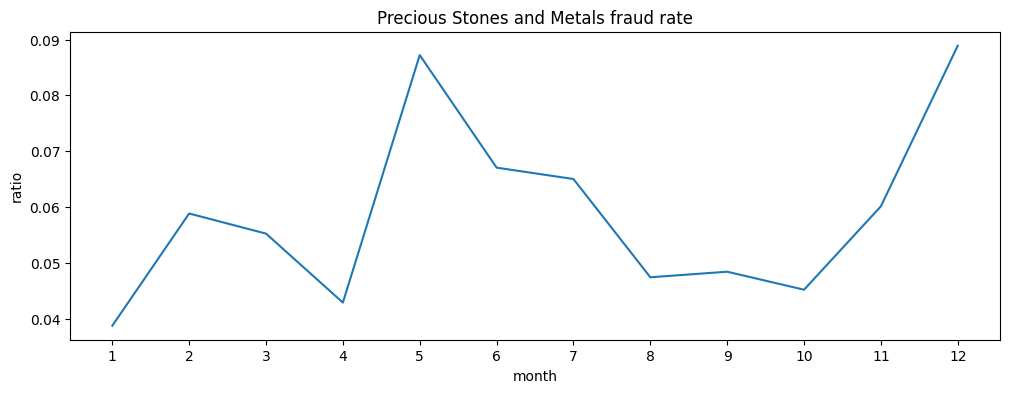

In [27]:
SM = df[df["mcc"]=="5094"].copy()
month = (
    SM
    .groupby("tx_month")[LABEL]
    .mean()
)
plt.figure(figsize=(12,4))
month.plot()
plt.xticks(month.index)
plt.xlabel("month")
plt.ylabel("ratio")
plt.title("Precious Stones and Metals fraud rate")
plt.show()

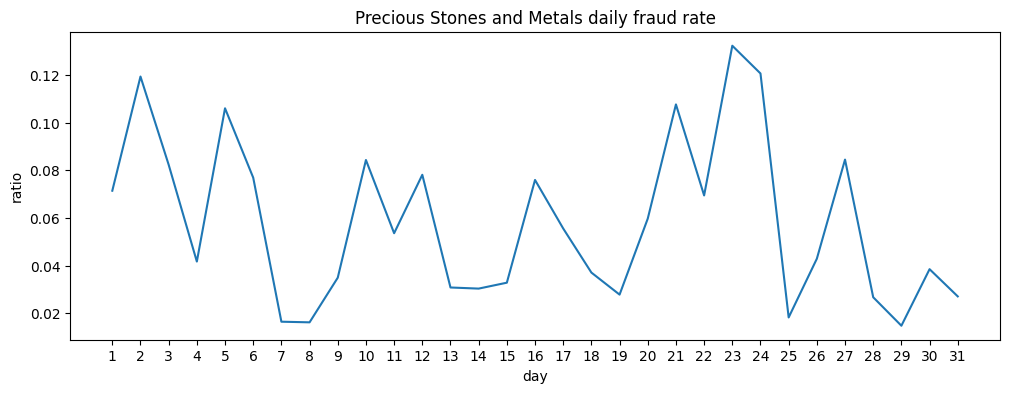

In [28]:
day = (
    SM
    .groupby("tx_day")[LABEL]
    .mean()
)
plt.figure(figsize=(12,4))
day.plot()
plt.xticks(day.index)
plt.xlabel("day")
plt.ylabel("ratio")
plt.title("Precious Stones and Metals daily fraud rate")
plt.show()

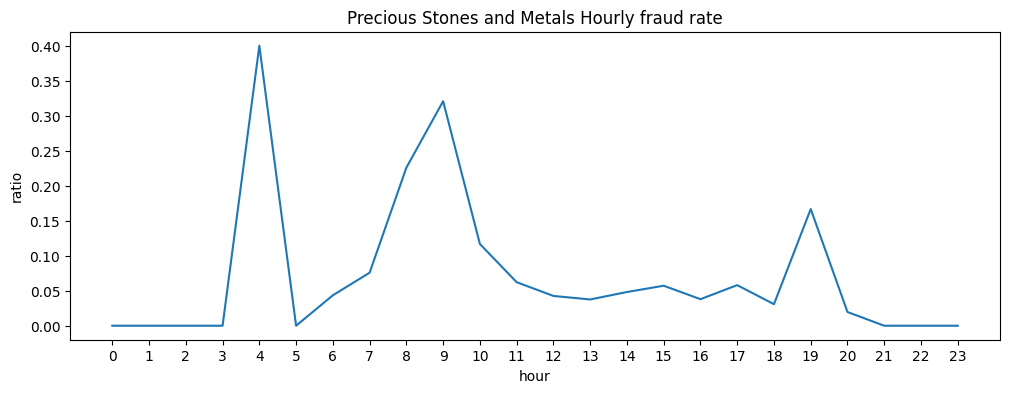

In [29]:
hour = (
    SM
    .groupby("tx_hour")[LABEL]
    .mean()
)
plt.figure(figsize=(12,4))
hour.plot()
plt.xticks(hour.index)
plt.xlabel("hour")
plt.ylabel("ratio")
plt.title("Precious Stones and Metals Hourly fraud rate")
plt.show()

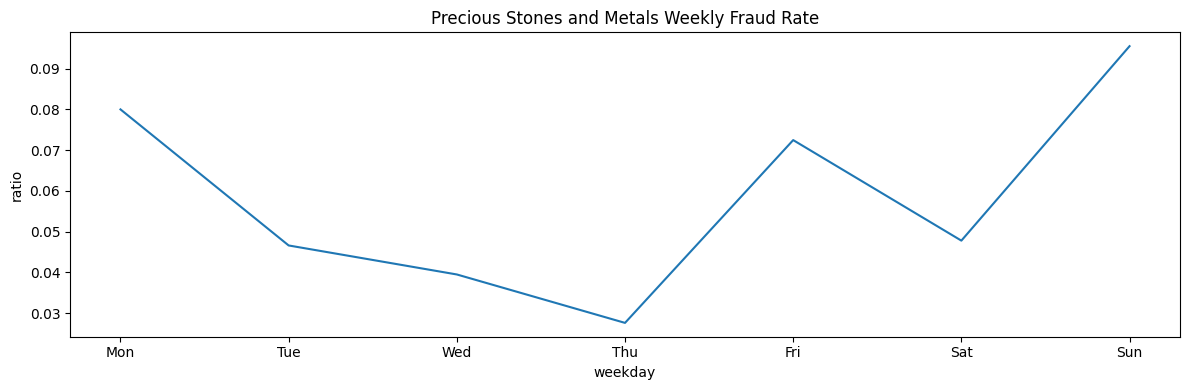

In [30]:
SM["weekday_name"] = SM["weekday"].map(weekday_map)

week = (
    SM
    .groupby("weekday_name")[LABEL]
    .mean()
    .reindex(order)
)

plt.figure(figsize=(12,4))
week.plot()

plt.xlabel("weekday")
plt.ylabel("ratio")
plt.title("Precious Stones and Metals Weekly Fraud Rate")
plt.tight_layout()
plt.show()

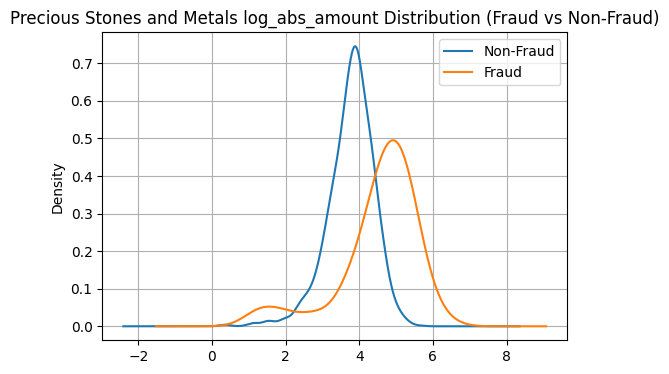

In [31]:
plt.figure(figsize=(6,4))
SM[SM["fraud"] == 0]["log_abs_amount"].plot(kind="kde", label="Non-Fraud")
SM[SM["fraud"] == 1]["log_abs_amount"].plot(kind="kde", label="Fraud")
plt.title(f"Precious Stones and Metals log_abs_amount Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
print(SM.groupby("is_credit")["fraud"].mean())
print()
print(SM.groupby("is_prepaid")["fraud"].mean())

is_credit
0    0.061608
1    0.054960
Name: fraud, dtype: float64

is_prepaid
0    0.052495
1    0.143791
Name: fraud, dtype: float64


**5712_Furniture, Home Furnishings, and Equipment Stores**

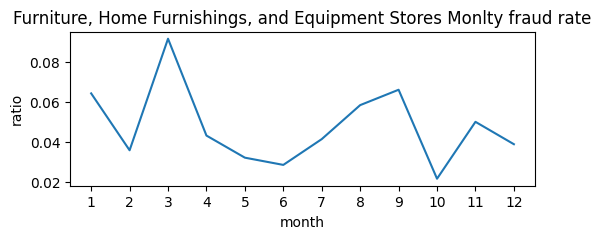

In [33]:
F = df[df["mcc"]=="5712"].copy()
month = (
    F
    .groupby("tx_month")[LABEL]
    .mean()
)
plt.figure(figsize=(6,2))
month.plot()
plt.xticks(month.index)
plt.xlabel("month")
plt.ylabel("ratio")
plt.title("Furniture, Home Furnishings, and Equipment Stores Monlty fraud rate")
plt.show()

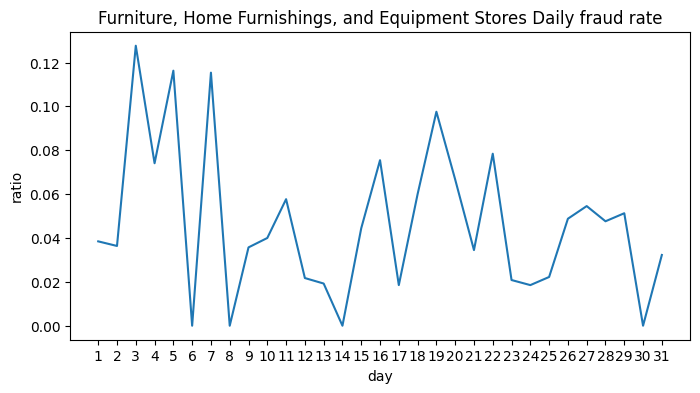

In [34]:
day = (
    F
    .groupby("tx_day")[LABEL]
    .mean()
)
plt.figure(figsize=(8,4))
day.plot()
plt.xticks(day.index)
plt.xlabel("day")
plt.ylabel("ratio")
plt.title("Furniture, Home Furnishings, and Equipment Stores Daily fraud rate")
plt.show()

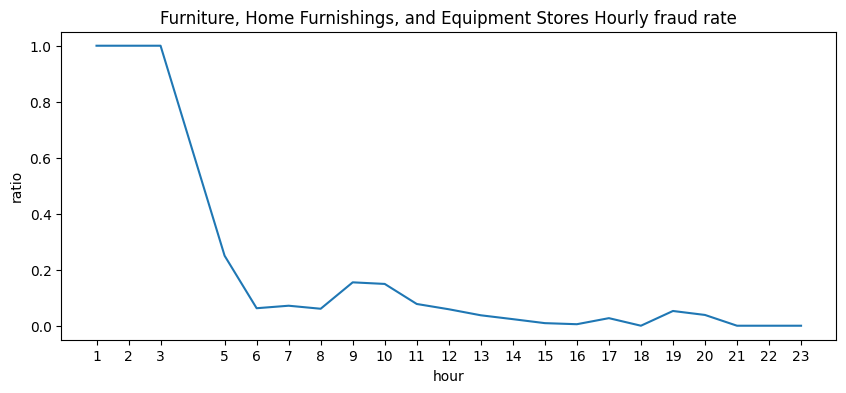

In [35]:
hour = (
    F
    .groupby("tx_hour")[LABEL]
    .mean()
)
plt.figure(figsize=(10,4))
hour.plot()
plt.xticks(hour.index)
plt.xlabel("hour")
plt.ylabel("ratio")
plt.title("Furniture, Home Furnishings, and Equipment Stores Hourly fraud rate")
plt.show()

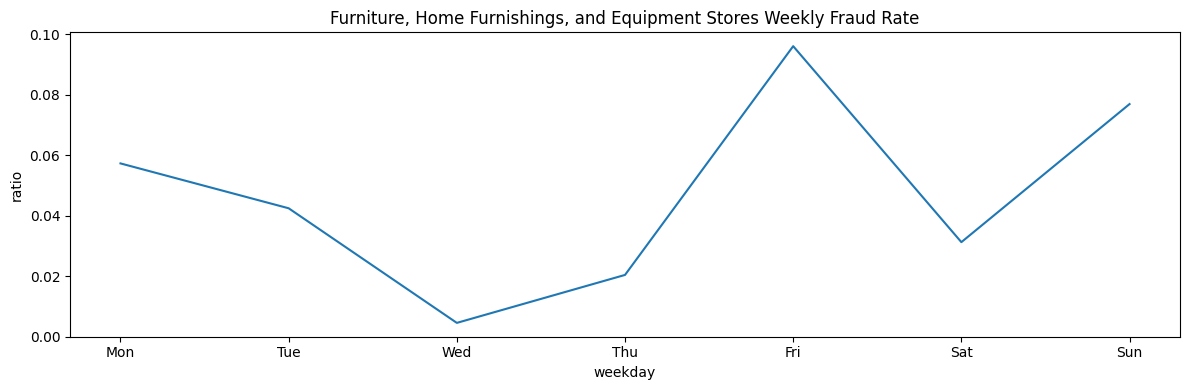

In [36]:
F["weekday_name"] = F["weekday"].map(weekday_map)

week = (
    F
    .groupby("weekday_name")[LABEL]
    .mean()
    .reindex(order)
)

plt.figure(figsize=(12,4))
week.plot()

plt.xlabel("weekday")
plt.ylabel("ratio")
plt.title("Furniture, Home Furnishings, and Equipment Stores Weekly Fraud Rate")
plt.tight_layout()
plt.show()

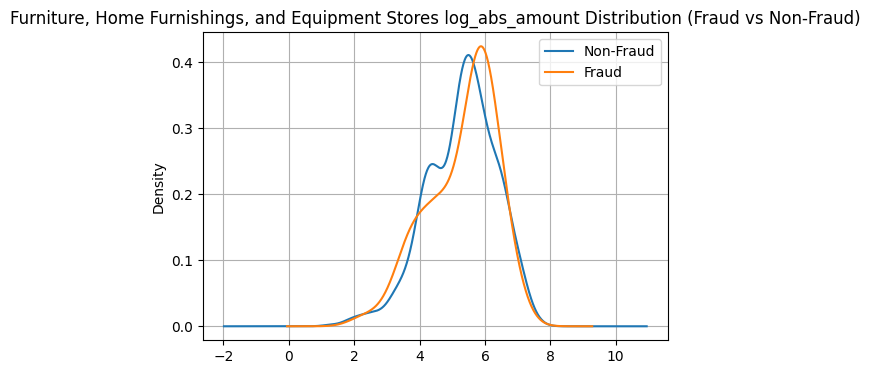

In [37]:
plt.figure(figsize=(6,4))
F[F["fraud"] == 0]["log_abs_amount"].plot(kind="kde", label="Non-Fraud")
F[F["fraud"] == 1]["log_abs_amount"].plot(kind="kde", label="Fraud")
plt.title(f"Furniture, Home Furnishings, and Equipment Stores log_abs_amount Distribution (Fraud vs Non-Fraud)")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
print(F.groupby("is_credit")["fraud"].mean())
print()
print(F.groupby("is_prepaid")["fraud"].mean())

is_credit
0    0.061893
1    0.029112
Name: fraud, dtype: float64

is_prepaid
0    0.044685
1    0.147059
Name: fraud, dtype: float64


> “주요 MCC 대부분 아침 시간대에 주로 발생”\
> → 노트북의 MCC별 tx_hour fraud rate 그래프 + “When 메모(아침/새벽~오전)”가 그 방향으로 정리돼 있음.

> “요일은 대부분 금·일 피크”\
> → MCC별 weekday_name fraud rate도 동일 템플릿으로 확인하는 구조라서, “전역 요일 패턴이 MCC별로도 유지되는지”를 재확인한 셈.

> “fraud는 debit(non_prepaid)가 가장 높다”\
> → MCC 5개 전부에서 fraud의 is_credit 평균이 낮아지고, prepaid는 오르긴 하지만 절대값이 크지 않아서 최종적으로 non-prepaid debit 쏠림 결론이 일관됨.

| 항목          | 유의미성 |
| ----------- | ---- |
| 아침 fraud 집중 | 중간   |
| 금·일 피크      | 중간   |
| debit 우세    | 약~중간 |
| MCC별 일관성    | 흥미로움 |

In [39]:
high_risk_days = [0, 4, 6]

df["is_highrisk_weekday"] = df["weekday"].isin(high_risk_days).astype("int8")

In [40]:
# 하드코딩 버려야 함!!! 

def add_is_highrisk_mcc(
    df: pd.DataFrame,
    y_col: str = "fraud",
    mcc_col: str = "mcc",
    year_col: str = "tx_year",
    cutoff_year: int = 2015,   
    top_pct: float = 0.95,   
    min_tx: int = 200       
):
    # 1) 정의용 구간(=train 역할)만 사용
    base = df[df[year_col] <= cutoff_year].copy()

    # 2) mcc별 통계 (거래수, fraud_rate)
    stats = (
        base.groupby(mcc_col)[y_col]
        .agg(tx_count="size", fraud_rate="mean")
        .sort_values("fraud_rate", ascending=False)
    )

    # 3) 안정성: 표본 너무 적은 mcc 제거
    stats = stats[stats["tx_count"] >= min_tx].copy()

    if len(stats) == 0:
        raise ValueError("min_tx 조건 때문에 유효 mcc가 0개")

    # 4) fraud_rate 상위 top_pct 기준으로 highrisk 선정
    thr = stats["fraud_rate"].quantile(top_pct)
    highrisk_mcc_list = stats.loc[stats["fraud_rate"] >= thr].index.tolist()

    # 5) df 전체에 적용 (정의는 train 기준, 적용은 전체)
    df = df.copy()
    df["is_highrisk_mcc"] = df[mcc_col].isin(highrisk_mcc_list).astype("int8")

    # 참고용: 리턴값으로 리스트/통계 같이 반환
    return df, highrisk_mcc_list, stats, thr

cands = [0.90, 0.95, 0.97, 0.99]
out = []

for tp in cands:
    tmp_df, lst, _, _ = add_is_highrisk_mcc(df, cutoff_year=2015, top_pct=tp, min_tx=200)
    out.append([tp, len(lst), tmp_df["is_highrisk_mcc"].mean()])

pd.DataFrame(out, columns=["top_pct", "n_mcc", "highrisk_share"]).sort_values("top_pct", ascending=False)

,top_pct,n_mcc,highrisk_share
3,0.99,1,0.000530
2,0.97,3,0.000951
1,0.95,5,0.001510
0,0.90,10,0.002643


In [41]:
def topk_lift(y_true, score, top_frac=0.10):

    y = np.asarray(y_true, dtype=int)
    s = np.asarray(score, dtype=float)

    base_rate = y.mean()
    if len(y) == 0:
        return np.nan, np.nan, np.nan, 0

    # 상위 top_frac 컷
    q = 1.0 - top_frac
    thr = np.quantile(s, q)

    top_mask = s >= thr
    top_n = int(top_mask.sum())

    # 극단 케이스 방어
    if top_n == 0:
        return np.nan, np.nan, base_rate, 0
    if top_n == len(s):
        # 점수가 전부 동일하면 전체가 top으로 잡힘 -> lift=1
        return 1.0, base_rate, base_rate, top_n

    top_rate = y[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan
    return lift, top_rate, base_rate, top_n


def make_highrisk_mcc_flag(df, cutoff_year=2015, top_pct=0.95, min_tx=200):
    base = df[df["tx_year"] <= cutoff_year]

    stats = (
        base.groupby("mcc")["fraud"]
        .agg(tx_count="size", fraud_rate="mean")
    )
    stats = stats[stats["tx_count"] >= min_tx]
    if len(stats) == 0:
        raise ValueError(f"유효 mcc가 0")

    thr = stats["fraud_rate"].quantile(top_pct)
    highrisk_list = stats.loc[stats["fraud_rate"] >= thr].index.tolist()

    out = df.copy()
    out["is_highrisk_mcc"] = out["mcc"].isin(highrisk_list).astype("int8")
    return out, highrisk_list


def fit_logit(df_in, features):
    tmp = df_in[features + ["fraud"]].dropna()
    X = sm.add_constant(tmp[features], has_constant="add")
    X = X.apply(pd.to_numeric, errors="raise")
    y = tmp["fraud"].astype(int)
    model = sm.Logit(y, X).fit(disp=0)
    return model


TOPS = [0.99, 0.97, 0.95, 0.90]

features_full = [
    "tx_month","tx_day","tx_hour","weekday",
    "log_abs_amount","log_amount_limit_ratio","log_yearly_income",
    "is_highrisk_mcc","is_highrisk_weekday",
]

rows = []

for tp in TOPS:
    # (A) highrisk_mcc를 train(<=2014) 기준으로 생성
    df_tmp, highrisk_list = make_highrisk_mcc_flag(df, cutoff_year=2015, top_pct=tp, min_tx=200)

    # (B) split
    train_df = df_tmp[df_tmp["tx_year"] <= 2014]
    test_df  = df_tmp[df_tmp["tx_year"] == 2015]

    # (C) fit
    model = fit_logit(train_df, features_full)

    # (D) test score
    tmp_test = test_df[features_full + ["fraud"]].dropna()
    X_test = sm.add_constant(tmp_test[features_full], has_constant="add").apply(pd.to_numeric, errors="raise")
    y_test = tmp_test["fraud"].astype(int).values
    score = model.predict(X_test).values

    # (E) robust top10% lift
    lift, top_rate, base_rate, top_n = topk_lift(y_test, score, top_frac=0.10)

    rows.append({
        "top_pct": tp,
        "n_mcc": len(highrisk_list),
        "highrisk_share": float(df_tmp["is_highrisk_mcc"].mean()),
        "top10_n": int(top_n),
        "base_rate": float(base_rate),
        "top10_rate": float(top_rate) if top_rate == top_rate else np.nan,
        "top10_lift": float(lift) if lift == lift else np.nan,
    })

summary_df = pd.DataFrame(rows).sort_values("top10_lift", ascending=False).reset_index(drop=True)
summary_df

,top_pct,n_mcc,highrisk_share,top10_n,base_rate,top10_rate,top10_lift
0,0.90,10,0.002643,92627,0.002349,0.009360,3.984366
1,0.95,5,0.001510,92627,0.002349,0.009079,3.864881
2,0.97,3,0.000951,92627,0.002349,0.008680,3.694845
3,0.99,1,0.000530,92627,0.002349,0.008658,3.685654


In [42]:
base_rate = df["fraud"].mean()

mcc_stats = (
    df.groupby("mcc")["fraud"]
      .agg(["mean", "count"])
      .rename(columns={"mean":"fraud_rate", "count":"tx_count"})
)

highrisk_mcc = mcc_stats[
    (mcc_stats["tx_count"] >= 1000) &
    (mcc_stats["fraud_rate"] >= base_rate * 3)
].index.tolist()

df["mcc_highrisk_90"] = df["mcc"].isin(highrisk_mcc).astype("int8")

In [43]:
CANDIDATES = [
   "is_highrisk_weekday", "mcc_highrisk_90"
]


def fit_logit_and_score(df, features, y_col=LABEL):
    use_cols = features + [y_col]
    tmp = df[use_cols].dropna(subset=use_cols).copy()

    X = sm.add_constant(tmp[features], has_constant="add")
    y = tmp[y_col].astype(int)

    X = X.apply(pd.to_numeric, errors="raise")

    model = sm.Logit(y, X).fit(disp=0)
    score = model.predict(X)
    return model, y, score


def top_decile_lift(y_true, score, q=0.90):
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score)

    base_rate = y_true.mean()
    thr = score.quantile(q)

    top_mask = score >= thr
    top_rate = y_true[top_mask].mean()
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    return {
        "base_rate": float(base_rate),
        "top_decile_rate": float(top_rate),
        "top_decile_lift": float(lift),
        "thr": float(thr),
        "top_n": int(top_mask.sum()),
    }

rows_uni = []

for col in CANDIDATES:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,mcc_highrisk_90,2.589629,13.324833,0.000000e+00,0.008564,5.917596,536455
1,is_highrisk_weekday,0.599875,1.821890,1.569519e-148,0.001948,1.345913,2282654


In [46]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in CANDIDATES:
    if col in BASELINE:
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)

=== BASELINE ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006117612512305813, 'top_decile_lift': 4.227363347026202, 'thr': 0.002807587535846678, 'top_n': 531253}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,mcc_highrisk_90,OK,2.337862,10.359067,0.000000e+00,0.001447,0.008499,5.872783,0.002381,1.645420,531253
1,is_highrisk_weekday,OK,0.601124,1.824168,1.868361e-148,0.001447,0.006084,4.203950,-0.000034,-0.023413,531253


좋다.
이건 사실상 **리스크 플래그 요약 변수 블록**이다.

이미 많은 행동 변수들을 정제한 상태에서
“요약형 high-risk flag가 추가 설명력을 주는가?”를 보는 단계다.

기준:

* Δ lift
* 구조적 중복 여부
* 해석 용이성
* Stage1 적합성

---

[High]

| feature         | OR    | Δ Lift  | 해석            |
| --------------- | ----- | ------- | ------------- |
| mcc_highrisk_90 | 10.36 | +1.6454 | 매우 강한 구조적 분리력 |

이 변수는 **진짜 High**다.

* OR 10 이상
* Lift +1.64
* 랭킹 개선 명확

이미 MCC 세부 변수들을 정리했어도
이 요약형 high-risk flag는 여전히 강력하다.

Stage1에 반드시 포함.

---

[Mid]

없음

---

[Low]

| feature             | OR   | Δ Lift  | 해석                  |
| ------------------- | ---- | ------- | ------------------- |
| is_highrisk_weekday | 1.82 | -0.0234 | sin/cos + 시간 변수에 흡수 |

요일 기반 highrisk 플래그는
이미 hour_sin / hour_cos + weekday 패턴에 흡수된 상태다.

추가 기여 없음.

---

최종 추천

Stage1 유지:

* mcc_highrisk_90

제거:

* is_highrisk_weekday

---

MCC는 여전히 강력한 사기 신호다.
시간대 리스크는 존재하지만, 요약 플래그로 추가할 정도는 아니다.

지금 구조는

- 금액 이상치
- 에러 히스토리
- MCC 리스크
- 거래 간격·속도
- 과거 fraud 히스토리

이 다섯 축이 명확히 잡혀 있다.

---

### **6.3 MCC Behavioral Features**

In [3]:
df = df.sort_values(["client_id", "date"]).copy()
df["mcc"] = df["mcc"].astype("category")
g = df.groupby("client_id")["mcc"]

df["client_mcc_prev"] = g.shift(1)
df["client_mcc_match_last1"] = (df["mcc"] == df["client_mcc_prev"]).fillna(False).astype("int8")

In [4]:
# 최근 3/5거래에서 현재 mcc가 등장했는지 
m1 = (df["mcc"] == g.shift(1))
m2 = (df["mcc"] == g.shift(2))
m3 = (df["mcc"] == g.shift(3))
m4 = (df["mcc"] == g.shift(4))
m5 = (df["mcc"] == g.shift(5))

df["client_mcc_seen_last3"] = (m1 | m2 | m3).fillna(False).astype("int8")
df["client_mcc_seen_last5"] = (m1 | m2 | m3 | m4 | m5).fillna(False).astype("int8")

# 최근 3/5거래에서 현재 mcc가 몇 번 반복됐는지 (0~3 / 0~5)
df["client_mcc_repeat_cnt_last3"] = (m1.fillna(False).astype("int8")
                                   + m2.fillna(False).astype("int8")
                                   + m3.fillna(False).astype("int8"))

df["client_mcc_repeat_cnt_last5"] = (m1.fillna(False).astype("int8")
                                   + m2.fillna(False).astype("int8")
                                   + m3.fillna(False).astype("int8")
                                   + m4.fillna(False).astype("int8")
                                   + m5.fillna(False).astype("int8"))

# 비율 버전 (0~1)
df["client_mcc_repeat_ratio_last3"] = (df["client_mcc_repeat_cnt_last3"] / 3).astype("float32")
df["client_mcc_repeat_ratio_last5"] = (df["client_mcc_repeat_cnt_last5"] / 5).astype("float32")


In [ ]:
df["client_mcc_prior_count"] = df.groupby(["client_id", "mcc"]).cumcount()
df["client_mcc_is_new"] = (df["client_mcc_prior_count"] == 0).astype("int8")

/tmp/ipykernel_1301904/4255307294.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["client_mcc_prior_count"] = df.groupby(["client_id", "mcc"]).cumcount()


In [6]:
prev = g.shift(1)
prev2 = g.shift(2)
prev3 = g.shift(3)
prev4 = g.shift(4)
prev5 = g.shift(5)

# 최근 5개에서 바뀐 횟수
# (prev5->prev4, prev4->prev3, prev3->prev2, prev2->prev1) 중 바뀐 횟수
chg1 = (prev  != prev2)
chg2 = (prev2 != prev3)
chg3 = (prev3 != prev4)
chg4 = (prev4 != prev5)

df["client_mcc_change_cnt_last5"] = (chg1.fillna(False).astype("int8")
                                  + chg2.fillna(False).astype("int8")
                                  + chg3.fillna(False).astype("int8")
                                  + chg4.fillna(False).astype("int8"))

In [7]:
g = df.groupby("card_id")["mcc"]

df["card_mcc_prev"] = g.shift(1)
df["card_mcc_match_last1"] = (df["mcc"] == df["card_mcc_prev"]).fillna(False).astype("int8")

In [8]:
# 최근 3/5거래에서 현재 mcc가 등장했는지 
m1 = (df["mcc"] == g.shift(1))
m2 = (df["mcc"] == g.shift(2))
m3 = (df["mcc"] == g.shift(3))
m4 = (df["mcc"] == g.shift(4))
m5 = (df["mcc"] == g.shift(5))

df["card_mcc_seen_last3"] = (m1 | m2 | m3).fillna(False).astype("int8")
df["card_mcc_seen_last5"] = (m1 | m2 | m3 | m4 | m5).fillna(False).astype("int8")

# 최근 3/5거래에서 '현재 mcc'가 몇 번 반복됐는지 (0~3 / 0~5)
df["card_mcc_repeat_cnt_last3"] = (m1.fillna(False).astype("int8")
                                   + m2.fillna(False).astype("int8")
                                   + m3.fillna(False).astype("int8"))

df["card_mcc_repeat_cnt_last5"] = (m1.fillna(False).astype("int8")
                                   + m2.fillna(False).astype("int8")
                                   + m3.fillna(False).astype("int8")
                                   + m4.fillna(False).astype("int8")
                                   + m5.fillna(False).astype("int8"))

# 비율 버전 (0~1)
df["card_mcc_repeat_ratio_last3"] = (df["card_mcc_repeat_cnt_last3"] / 3).astype("float32")
df["card_mcc_repeat_ratio_last5"] = (df["card_mcc_repeat_cnt_last5"] / 5).astype("float32")


In [9]:
df["card_mcc_prior_count"] = df.groupby(["card_id", "mcc"]).cumcount()
df["card_mcc_is_new"] = (df["card_mcc_prior_count"] == 0).astype("int8")

/tmp/ipykernel_1301904/2656056192.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["card_mcc_prior_count"] = df.groupby(["card_id", "mcc"]).cumcount()


In [10]:
prev = g.shift(1)
prev2 = g.shift(2)
prev3 = g.shift(3)
prev4 = g.shift(4)
prev5 = g.shift(5)

chg1 = (prev  != prev2)
chg2 = (prev2 != prev3)
chg3 = (prev3 != prev4)
chg4 = (prev4 != prev5)

df["card_mcc_change_cnt_last5"] = (chg1.fillna(False).astype("int8")
                                  + chg2.fillna(False).astype("int8")
                                  + chg3.fillna(False).astype("int8")
                                  + chg4.fillna(False).astype("int8"))


In [11]:
def analyze_feature(df, feature):
    
    # Fraud rate 테이블
    table = (
        df.groupby(feature)["fraud"]
          .agg(["mean", "count"])
          .rename(columns={"mean": "fraud_rate"})
    )
    
    # baseline 계산
    baseline = table["fraud_rate"].min()
    table["uplift"] = table["fraud_rate"] / baseline
    
    display(table.round(4))
    
    plt.figure(figsize=(5,4))
    table["fraud_rate"].plot(kind="bar")
    plt.title(f"{feature} vs Fraud Rate")
    plt.ylabel("Fraud Rate")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


In [12]:
mcc_features = [
    "client_mcc_match_last1",
    "client_mcc_seen_last3",
    "client_mcc_seen_last5",
    "client_mcc_repeat_cnt_last3",
    "client_mcc_repeat_cnt_last5",
    "client_mcc_is_new",
    "client_mcc_change_cnt_last5",
    
    "card_mcc_match_last1",
    "card_mcc_seen_last3",
    "card_mcc_seen_last5",
    "card_mcc_repeat_cnt_last3",
    "card_mcc_repeat_cnt_last5",
    "card_mcc_is_new",
    "card_mcc_change_cnt_last5",
]


========== client_mcc_match_last1 ==========


,fraud_rate,count,uplift
client_mcc_match_last1,,,
0,0.0017,4324583,2.9533
1,0.0006,987942,1.0000


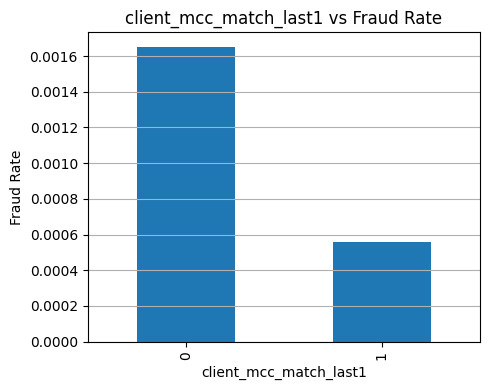


========== client_mcc_seen_last3 ==========


,fraud_rate,count,uplift
client_mcc_seen_last3,,,
0,0.0019,3549924,3.0282
1,0.0006,1762601,1.0000


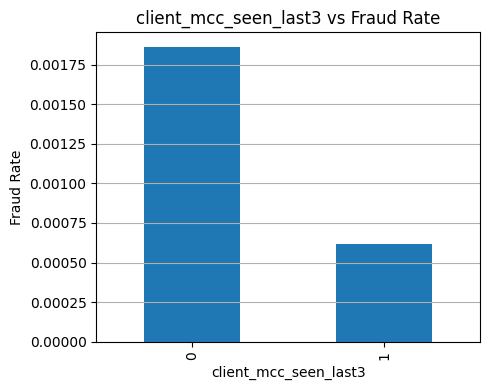


========== client_mcc_seen_last5 ==========


,fraud_rate,count,uplift
client_mcc_seen_last5,,,
0,0.0021,3004378,3.2011
1,0.0006,2308147,1.0000


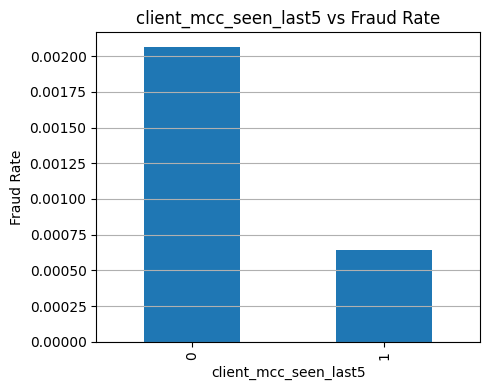


========== client_mcc_repeat_cnt_last3 ==========


,fraud_rate,count,uplift
client_mcc_repeat_cnt_last3,,,
0,0.0019,3549924,98.1524
1,0.0008,1230512,42.8708
2,0.0002,426583,10.0168
3,0.0000,105506,1.0000


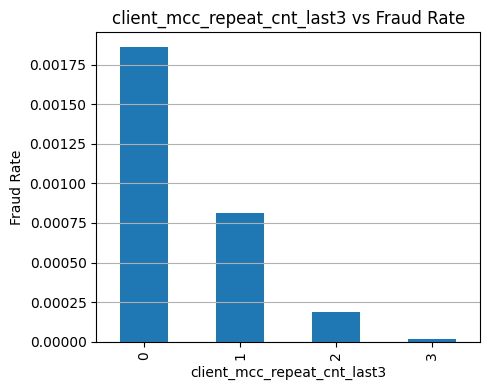


========== client_mcc_repeat_cnt_last5 ==========


,fraud_rate,count,uplift
client_mcc_repeat_cnt_last5,,,
0,0.0021,3004378,inf
1,0.0010,1330947,inf
2,0.0003,603778,inf
3,0.0001,251055,inf
4,0.0000,96853,NaN
5,0.0000,25514,NaN


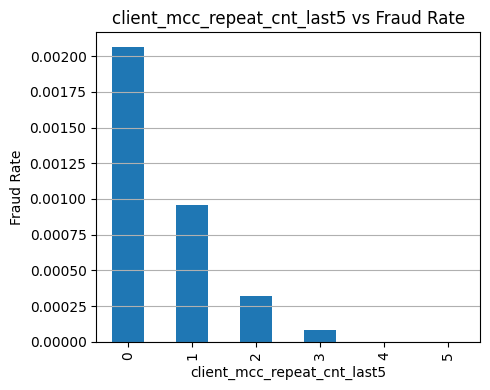


========== client_mcc_is_new ==========


,fraud_rate,count,uplift
client_mcc_is_new,,,
0,0.0011,5232397,1.0000
1,0.0234,80128,21.0183


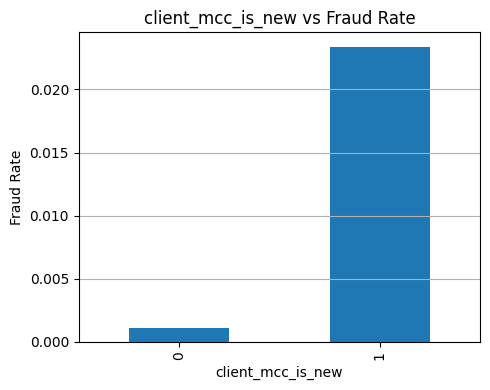


========== client_mcc_change_cnt_last5 ==========


,fraud_rate,count,uplift
client_mcc_change_cnt_last5,,,
0,0.0004,50710,1.0000
1,0.0006,173947,1.5548
2,0.0008,747281,2.2544
3,0.0012,1730478,3.2527
4,0.0019,2610109,5.3730


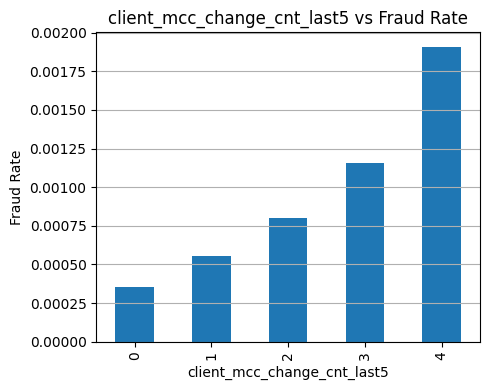


========== card_mcc_match_last1 ==========


,fraud_rate,count,uplift
card_mcc_match_last1,,,
0,0.0016,4298381,2.7231
1,0.0006,1014144,1.0000


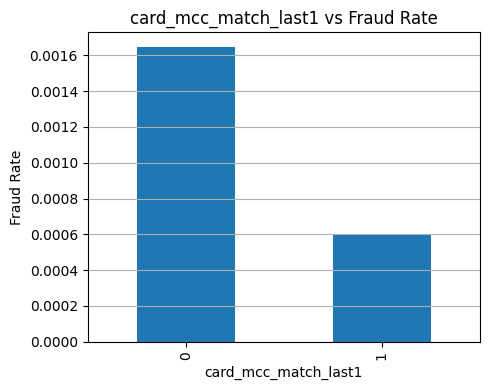


========== card_mcc_seen_last3 ==========


,fraud_rate,count,uplift
card_mcc_seen_last3,,,
0,0.0019,3500913,2.7731
1,0.0007,1811612,1.0000


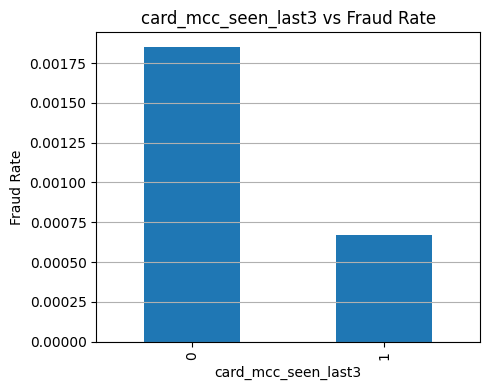


========== card_mcc_seen_last5 ==========


,fraud_rate,count,uplift
card_mcc_seen_last5,,,
0,0.0020,2976912,2.9273
1,0.0007,2335613,1.0000


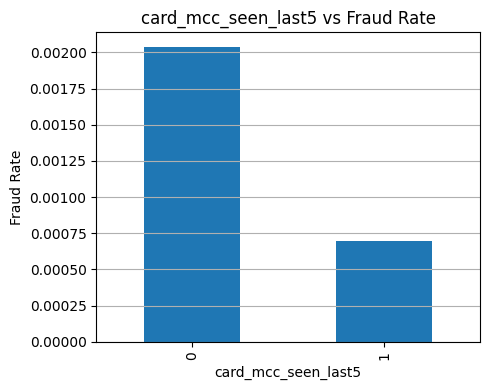


========== card_mcc_repeat_cnt_last3 ==========


,fraud_rate,count,uplift
card_mcc_repeat_cnt_last3,,,
0,0.0019,3500913,55.5448
1,0.0009,1237765,26.5275
2,0.0002,453793,7.3414
3,0.0000,120054,1.0000


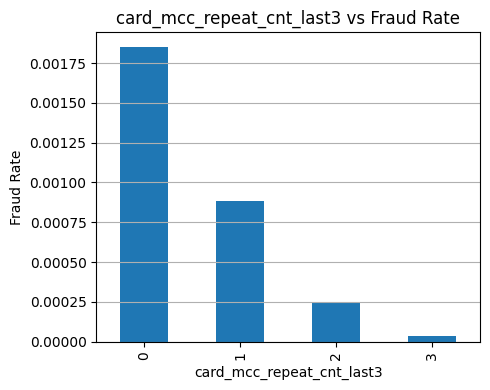


========== card_mcc_repeat_cnt_last5 ==========


,fraud_rate,count,uplift
card_mcc_repeat_cnt_last5,,,
0,0.0020,2976912,inf
1,0.0010,1316970,inf
2,0.0004,613397,inf
3,0.0001,263778,inf
4,0.0000,110339,inf
5,0.0000,31129,NaN


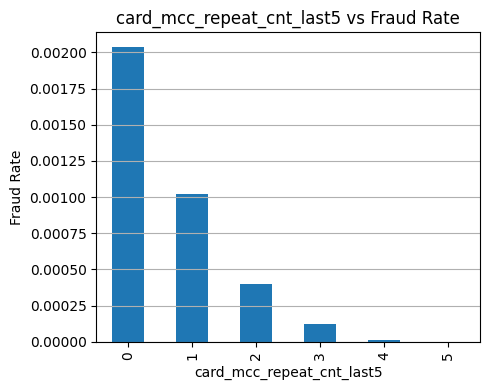


========== card_mcc_is_new ==========


,fraud_rate,count,uplift
card_mcc_is_new,,,
0,0.0011,5232397,1.0000
1,0.0234,80128,21.0183


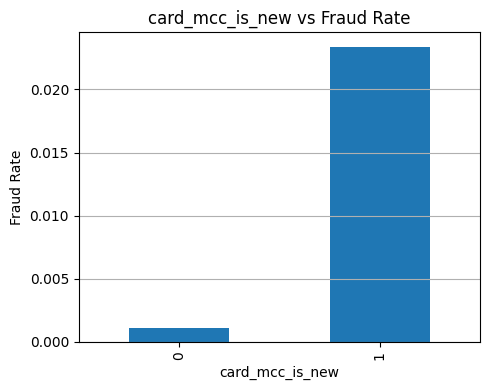


========== card_mcc_change_cnt_last5 ==========


,fraud_rate,count,uplift
card_mcc_change_cnt_last5,,,
0,0.0002,59740,1.0000
1,0.0004,188335,1.6313
2,0.0007,767735,3.1014
3,0.0011,1710435,4.7525
4,0.0020,2586280,8.4789


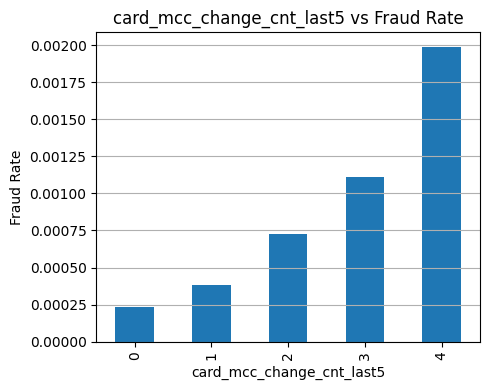

In [57]:
for f in mcc_features:
    print(f"\n========== {f} ==========")
    analyze_feature(df, f)


In [16]:
rows_uni = []

for col in mcc_features:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,client_mcc_repeat_cnt_last5,-0.883468,0.413347,0.000000e+00,0.002064,1.426017,3004378
1,client_mcc_seen_last5,-1.164912,0.311950,0.000000e+00,0.002064,1.426017,3004378
2,card_mcc_repeat_cnt_last5,-0.794830,0.451658,0.000000e+00,0.002037,1.407373,2976912
3,card_mcc_seen_last5,-1.075428,0.341152,0.000000e+00,0.002037,1.407373,2976912
4,card_mcc_change_cnt_last5,0.536328,1.709716,8.393833e-223,0.001987,1.373064,2586280
5,client_mcc_change_cnt_last5,0.449570,1.567639,3.093055e-167,0.001907,1.317904,2610109
6,client_mcc_seen_last3,-1.109204,0.329821,9.759114e-251,0.001861,1.285705,3549924
7,client_mcc_repeat_cnt_last3,-0.950357,0.386603,5.867734e-257,0.001861,1.285705,3549924
8,card_mcc_repeat_cnt_last3,-0.864353,0.421324,1.050974e-245,0.001851,1.278834,3500913
9,card_mcc_seen_last3,-1.021151,0.360180,7.614464e-233,0.001851,1.278834,3500913


In [19]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in mcc_features:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)

=== BASELINE ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006117612512305813, 'top_decile_lift': 4.227363347026202, 'thr': 0.002807587535846677, 'top_n': 531253}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,card_mcc_is_new,OK,2.292821,9.902837,0.000000e+00,0.001447,0.007778,5.374605,0.001660,1.147241,531253
1,client_mcc_is_new,OK,2.578705,13.180060,0.000000e+00,0.001447,0.007401,5.114459,0.001284,0.887096,531253
2,client_mcc_repeat_cnt_last5,OK,-0.840503,0.431493,0.000000e+00,0.001447,0.006202,4.285896,0.000085,0.058533,531253
3,card_mcc_change_cnt_last5,OK,0.551147,1.735242,5.291861e-234,0.001447,0.006174,4.266385,0.000056,0.039022,531253
4,client_mcc_change_cnt_last5,OK,0.465070,1.592125,7.380337e-178,0.001447,0.006159,4.255979,0.000041,0.028616,531253
5,client_mcc_repeat_cnt_last3,OK,-0.945874,0.388340,1.852142e-252,0.001447,0.006133,4.237769,0.000015,0.010406,531253
6,client_mcc_match_last1,OK,-1.237558,0.290092,1.189225e-168,0.001447,0.006131,4.236460,0.000013,0.009097,531254
7,card_mcc_repeat_cnt_last5,OK,-0.752076,0.471387,8.475158e-300,0.001447,0.006129,4.235168,0.000011,0.007804,531253
8,card_mcc_repeat_cnt_last3,OK,-0.853800,0.425794,9.296483e-240,0.001447,0.006114,4.224762,-0.000004,-0.002601,531253
9,card_mcc_match_last1,OK,-1.129247,0.323277,9.099435e-156,0.001447,0.006110,4.222097,-0.000008,-0.005266,531261



---

[High]

| feature           | OR    | Δ Lift  | 해석                      |
| ----------------- | ----- | ------- | ----------------------- |
| card_mcc_is_new   | 9.90  | +1.1472 | 카드 기준 신규 MCC → 매우 강한 신호 |
| client_mcc_is_new | 13.18 | +0.8871 | 고객 기준 신규 MCC → 강한 이상 행동 |

이 둘은 명확한 구조적 신호다.
**“이 사람이 평소 안 쓰던 업종에서 결제했다”**
FDS 핵심 로직에 부합한다.

Stage1에 유지하는 것이 합리적이다.

---

[Mid]

| feature                     | OR   | Δ Lift  | 해석           |
| --------------------------- | ---- | ------- | ------------ |
| client_mcc_repeat_cnt_last5 | 0.43 | +0.0585 | 반복 사용은 안전 신호 |
| card_mcc_change_cnt_last5   | 1.73 | +0.0390 | 업종 변화는 위험 신호 |
| client_mcc_change_cnt_last5 | 1.59 | +0.0286 | 고객 단위 변화     |

이 그룹은 효과는 있으나 강력하진 않다.
Stage2 또는 고도화 모델에서 활용 가치 있음.

---

[Low]

| feature                     | OR   | Δ Lift  | 해석 |
| --------------------------- | ---- | ------- | -- |
| client_mcc_repeat_cnt_last3 | 0.39 | +0.0104 | 중복 |
| client_mcc_match_last1      | 0.29 | +0.0091 | 중복 |
| card_mcc_repeat_cnt_last5   | 0.47 | +0.0078 | 중복 |
| card_mcc_repeat_cnt_last3   | 0.43 | -0.0026 | 약함 |
| card_mcc_match_last1        | 0.32 | -0.0053 | 중복 |
| client_mcc_seen_last3       | 0.33 | -0.0065 | 중복 |
| client_mcc_seen_last5       | 0.33 | -0.0208 | 약함 |
| card_mcc_seen_last3         | 0.36 | -0.0625 | 제거 |
| card_mcc_seen_last5         | 0.36 | -0.0819 | 제거 |

이 그룹은 대부분
`mcc_is_new` + `mcc_change_cnt`에 흡수된다.

---

핵심 인사이트

MCC 행동 변수의 본질은 두 가지다:

1. “고위험 업종인가?”
2. “이 사람이 평소 안 쓰던 업종인가?”


---
# 7. Merchant Novelty & Switching Block

> 카드/고객 기준 상점 변화 탐지

- merchant_is_new

- card_merchant_is_new

- merchant_change_cnt_last5

- merchant_is_new_x_has_error

- merchant_is_new_x_mcc_is_new

---

**client_merchant_is_new / card_merchant_is_new**

In [60]:
df["client_merchant_is_new"] = (
    df.groupby(["client_id", "merchant_id"], sort=False).cumcount().eq(0).astype("int8")
)

df["card_merchant_is_new"] = (
    df.groupby(["card_id", "merchant_id"], sort=False).cumcount().eq(0).astype("int8")
)

**merchant_change_cnt_last5 (최근 5건에서 merchant가 몇 번 바뀌었는지)**

In [61]:
prev_merchant = df.groupby("card_id", sort=False)["merchant_id"].shift(1)

df["merchant_changed"] = (
    df["merchant_id"].ne(prev_merchant)      # 직전과 다르면 True
    .fillna(True)                            # 첫 거래는 변경
    .astype("int8")
)

# 2) 최근 5건에서 변경 횟수
df["merchant_change_cnt_last5"] = (
    df.groupby("card_id", sort=False)["merchant_changed"]
      .rolling(window=5, min_periods=1)
      .sum()
      .reset_index(level=0, drop=True)
      .astype("int8")
)

df.drop(columns=["merchant_changed"], inplace=True)

**merchant_is_new × mcc_is_new / has_error**

In [62]:
# merchant_is_new 정의(카드 기준)
df["merchant_is_new"] = df["card_merchant_is_new"].astype("int8")

# merchant_is_new × mcc_is_new 
if "card_mcc_is_new" in df.columns:
    df["merchant_is_new_x_mcc_is_new"] = (
        df["merchant_is_new"].astype("int8") * df["card_mcc_is_new"].astype("int8")
    ).astype("int8")
else:
    # 없으면 대체: card 단위로 mcc 첫 등장 여부 생성
    df["card_mcc_is_new"] = (
        df.groupby(["card_id", "mcc"], sort=False).cumcount().eq(0).astype("int8")
    )
    df["merchant_is_new_x_mcc_is_new"] = (
        df["merchant_is_new"] * df["card_mcc_is_new"]
    ).astype("int8")

# merchant_is_new × has_error
df["merchant_is_new_x_has_error"] = (
    df["merchant_is_new"].astype("int8") * df["has_error"].astype("int8")
).astype("int8")

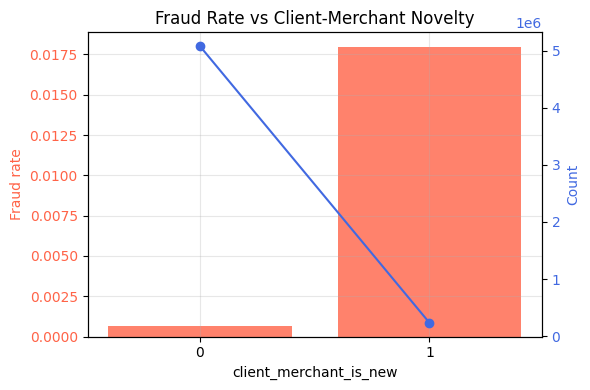

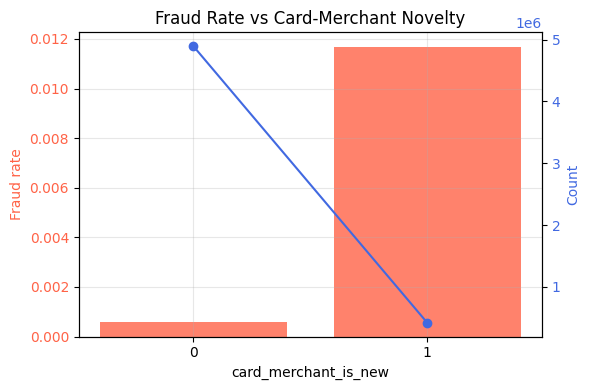

In [63]:
def plot_rate_and_count_by_flag(df, flag_col, title):
    g = df.groupby(flag_col)["fraud"].agg(rate="mean", cnt="size")
    fig, ax1 = plt.subplots(figsize=(6,4))

    # fraud rate (bar)
    ax1.bar(g.index.astype(str), g["rate"], color="tomato", alpha=0.8)
    ax1.set_ylabel("Fraud rate", color="tomato")
    ax1.set_xlabel(flag_col)
    ax1.set_title(title)
    ax1.tick_params(axis="y", labelcolor="tomato")
    ax1.grid(True, alpha=0.3)

    # count (line)
    ax2 = ax1.twinx()
    ax2.plot(g.index.astype(str), g["cnt"], color="royalblue", marker="o")
    ax2.set_ylabel("Count", color="royalblue")
    ax2.tick_params(axis="y", labelcolor="royalblue")

    plt.tight_layout()
    plt.show()

plot_rate_and_count_by_flag(df, "client_merchant_is_new", 
                            "Fraud Rate vs Client-Merchant Novelty")

plot_rate_and_count_by_flag(df, "card_merchant_is_new", 
                            "Fraud Rate vs Card-Merchant Novelty")


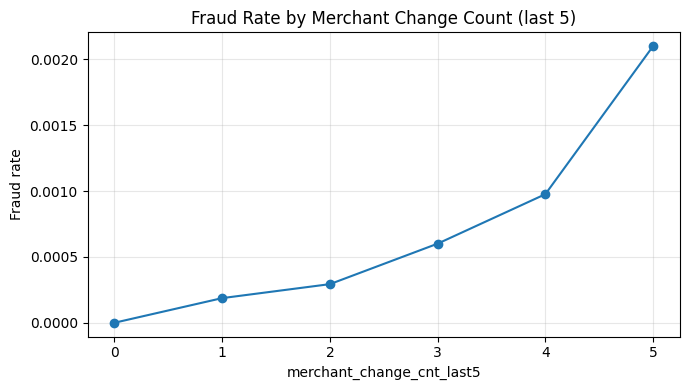

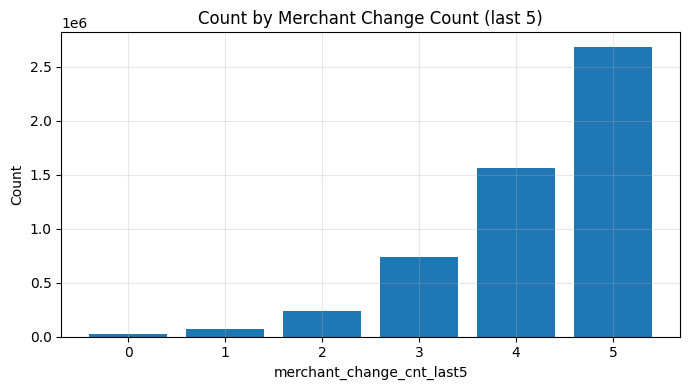

In [64]:
tmp = df.groupby("merchant_change_cnt_last5")["fraud"].agg(rate="mean", cnt="size").reset_index()

plt.figure(figsize=(7,4))
plt.plot(tmp["merchant_change_cnt_last5"], tmp["rate"], marker="o")
plt.xlabel("merchant_change_cnt_last5")
plt.ylabel("Fraud rate")
plt.title("Fraud Rate by Merchant Change Count (last 5)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.bar(tmp["merchant_change_cnt_last5"].astype(str), tmp["cnt"])
plt.xlabel("merchant_change_cnt_last5")
plt.ylabel("Count")
plt.title("Count by Merchant Change Count (last 5)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

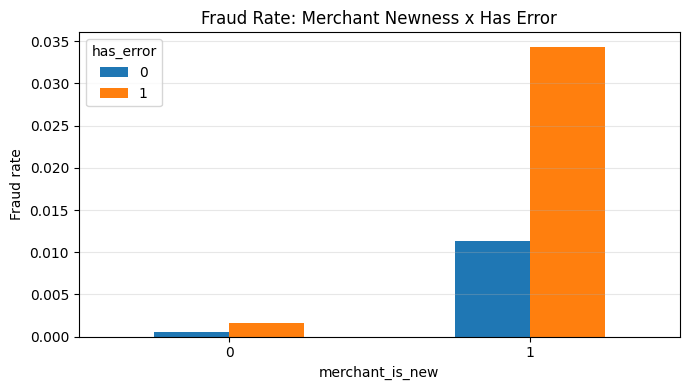

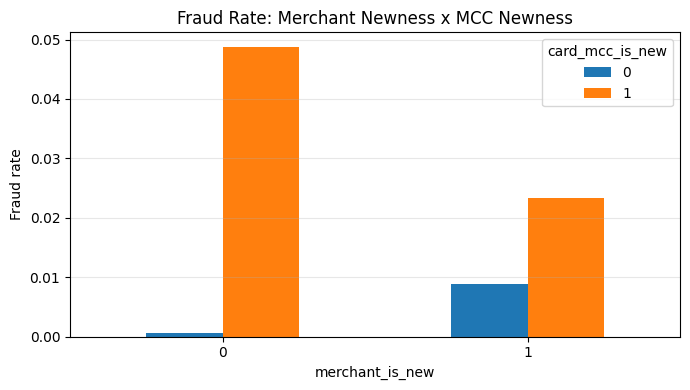

In [65]:
def plot_rate_by_two_flags(df, a, b, title):
    pivot = (
        df.groupby([a, b])["fraud"].mean()
          .unstack(fill_value=0)
          .sort_index()
    )
    pivot.plot(kind="bar", figsize=(7,4))
    plt.ylabel("Fraud rate")
    plt.title(title)
    plt.xticks(rotation=0)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_rate_by_two_flags(df, "merchant_is_new", "has_error", "Fraud Rate: Merchant Newness x Has Error")
plot_rate_by_two_flags(df, "merchant_is_new", "card_mcc_is_new", "Fraud Rate: Merchant Newness x MCC Newness")

In [67]:
cols = ["merchant_is_new_x_has_error",
        "merchant_is_new_x_mcc_is_new",
        "merchant_change_cnt_last5",
        "card_merchant_is_new",
        "client_merchant_is_new"]

In [68]:
rows_uni = []

for col in cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,merchant_change_cnt_last5,0.679600,1.973088,6.059804e-309,0.002100,1.451166,2683270
1,merchant_is_new_x_has_error,3.226550,25.192604,0.000000e+00,0.001447,1.000000,5312525
2,merchant_is_new_x_mcc_is_new,3.067015,21.477695,0.000000e+00,0.001447,1.000000,5312525
3,card_merchant_is_new,3.027428,20.644065,0.000000e+00,0.001447,1.000000,5312525
4,client_merchant_is_new,3.289597,26.832040,0.000000e+00,0.001447,1.000000,5312525


In [69]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006117612512305813, 'top_decile_lift': 4.227363347026202, 'thr': 0.002807587535846677, 'top_n': 531253}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,card_merchant_is_new,OK,2.864612,17.542249,0.000000e+00,0.001447,0.010240,7.075956,0.004122,2.848593,531253
1,client_merchant_is_new,OK,3.109957,22.420069,0.000000e+00,0.001447,0.009988,6.901658,0.003870,2.674295,531253
2,merchant_is_new_x_mcc_is_new,OK,2.577513,13.164362,0.000000e+00,0.001447,0.007401,5.114459,0.001284,0.887096,531253
3,merchant_change_cnt_last5,OK,0.734078,2.083560,0.000000e+00,0.001447,0.006402,4.423773,0.000284,0.196410,531253
4,merchant_is_new_x_has_error,OK,2.870748,17.650220,8.000781e-143,0.001447,0.006310,4.360038,0.000192,0.132674,531253



---

[High]

| feature                      | OR    | Δ Lift  | 해석                      |
| ---------------------------- | ----- | ------- | ----------------------- |
| card_merchant_is_new         | 17.54 | +2.8486 | 카드 기준 신규 가맹점 → 매우 강력    |
| client_merchant_is_new       | 22.42 | +2.6743 | 고객 기준 신규 가맹점 → 매우 강력    |
| merchant_is_new_x_mcc_is_new | 13.16 | +0.8871 | 신규 가맹점 + 신규 업종 → 구조적 위험 |


* card_merchant_is_new
* client_merchant_is_new

이 둘은 MCC보다도 더 강한 신호

사기 구조의 핵심 패턴:
“새 가맹점 + 평소 안 쓰던 행동”

---

[Mid]

| feature                     | OR    | Δ Lift  | 해석         |
| --------------------------- | ----- | ------- | ---------- |
| merchant_change_cnt_last5   | 2.08  | +0.1964 | 최근 가맹점 이동성 |
| merchant_is_new_x_has_error | 17.65 | +0.1327 | 신규 + 에러 결합 |

이 그룹은 효과는 있지만
이미 신규 merchant + error + velocity에 일부 흡수된다.

Stage2에서는 의미 있음.

---

핵심 인사이트

MCC보다 더 강한 신호는
“새 가맹점”이다.

금액 이상치 + 신규 가맹점 + 카드 에러
이 조합이 실무 FDS에서 가장 강력한 구조다.

---

# 8. Velocity & Interval Block

> 단시간 급격한 변화 탐지

## 8.1 Interval Features

- seconds_since_prev_tx

- client_avg_interval_prev

- interval_ratio

- log_interval_dev

## 8.2 Velocity Features

- client_tx_1h

- client_tx_1h_avg_prev

- velocity_spike_ratio

- card_tx_1h

- card_velocity_spike_ratio

## 8.3 Burst / Deviation

---

### **8.1 Interval Features**

- seconds_since_prev_tx

- client_avg_interval_prev

- interval_ratio

- log_interval_dev

In [87]:
# 1) 이전 거래 시점
df["prev_tx_time"] = df.groupby("client_id")["date"].shift(1)

# 2) 초 단위 간격
df["seconds_since_prev_tx"] = (
    (df["date"] - df["prev_tx_time"]).dt.total_seconds()
)

# 첫 거래는 간격 없음 → 큰 값으로 처리 (중립)
df["seconds_since_prev_tx"] = df["seconds_since_prev_tx"].fillna(0)

# 로그 변환
df["log_interval"] = np.log1p(df["seconds_since_prev_tx"])

In [88]:
# 과거값 shift
df["log_interval_shift"] = df.groupby("client_id")["log_interval"].shift(1)

# 누적합
df["interval_cumsum"] = (
    df["log_interval_shift"].fillna(0)
      .groupby(df["client_id"])
      .cumsum()
)

# 과거 개수
df["interval_cnt_past"] = df.groupby("client_id").cumcount()

# 과거 평균
df["client_avg_interval_prev"] = np.where(
    df["interval_cnt_past"] > 0,
    df["interval_cumsum"] / df["interval_cnt_past"],
    df["log_interval"]  # 첫 거래는 자기 자신으로 중립 처리
)


In [89]:
# ratio
df["interval_ratio"] = (
    df["log_interval"] /
    (df["client_avg_interval_prev"] + 1e-6)
)

# deviation (z-score 방식)
df["log_interval_dev"] = (
    df["log_interval"] -
    df["client_avg_interval_prev"]
)

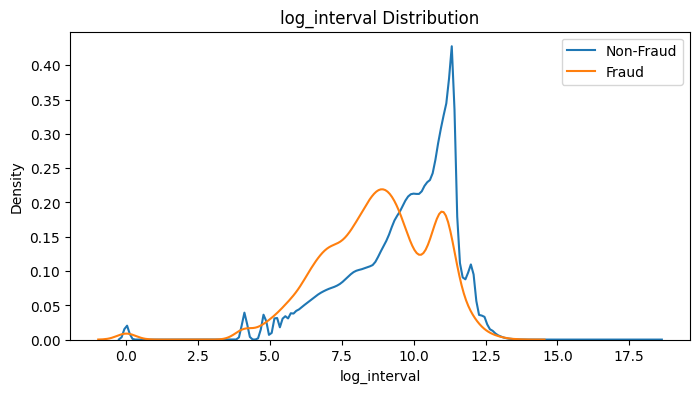

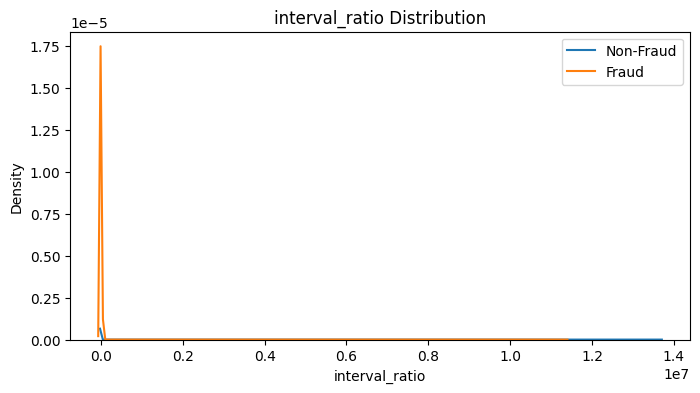

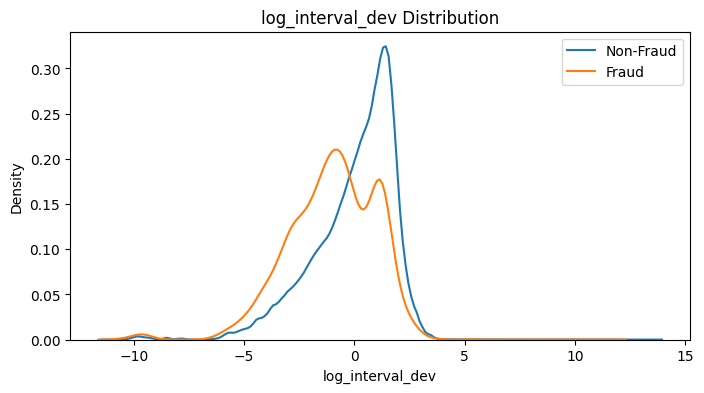

In [91]:
sample = df.copy()

features = [
    "log_interval",
    "interval_ratio",
    "log_interval_dev"
]

for col in features:
    plt.figure(figsize=(8,4))
    sns.kdeplot(sample[sample["fraud"]==0][col], label="Non-Fraud")
    sns.kdeplot(sample[sample["fraud"]==1][col], label="Fraud")
    plt.title(f"{col} Distribution")
    plt.legend()
    plt.show()


In [90]:
cols = [
    "seconds_since_prev_tx",
    "client_avg_interval_prev",
    "interval_ratio",
    "log_interval_dev"
]

In [92]:
rows_uni = []

for col in cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)


display(uni_df)

/home/nakyung/.local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,log_interval_dev,-2.243307e-01,0.799051,0.000000e+00,0.003112,2.150102,531253
1,interval_ratio,-4.146682e-08,1.000000,6.581073e-01,0.002923,2.020029,531253
2,client_avg_interval_prev,6.033026e-01,1.828146,6.769818e-143,0.002475,1.710456,531253
3,seconds_since_prev_tx,-1.184428e-05,0.999988,1.276062e-209,0.002355,1.627031,531736


In [93]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)



=== BASELINE ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006117612512305813, 'top_decile_lift': 4.227363347026202, 'thr': 0.002807587535846677, 'top_n': 531253}


/home/nakyung/.local/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,seconds_since_prev_tx,OK,-1.008139e-05,0.999990,5.717859e-165,0.001447,0.006197,4.281994,0.000079,0.054631,531253
1,client_avg_interval_prev,OK,5.762178e-01,1.779296,6.555222e-136,0.001447,0.006193,4.279392,0.000075,0.052029,531253
2,interval_ratio,OK,-4.248287e-08,1.000000,6.509575e-01,0.001447,0.006116,4.226063,-0.000002,-0.001301,531253
3,log_interval_dev,OK,-1.777804e-01,0.837126,0.000000e+00,0.001447,0.006110,4.222160,-0.000008,-0.005203,531253


---

[High]

없음

이 블록은 전반적으로 보조 신호다.
폭발적 분리력은 아님

---

[Mid]

| feature                  | OR       | Δ Lift  | 해석          |
| ------------------------ | -------- | ------- | ----------- |
| seconds_since_prev_tx    | ~0.99999 | +0.0546 | 직전 거래와의 간격  |
| client_avg_interval_prev | 1.78     | +0.0520 | 고객 평균 간격 대비 |

이 둘은 구조적으로 의미 있음.

* 간격이 짧아질수록 위험 증가
* 평균 대비 급변은 리스크 상승

Stage1에 “경량 보조 신호”로는 적절.

---

[Low]

| feature          | OR   | Δ Lift  | 해석     |
| ---------------- | ---- | ------- | ------ |
| log_interval_dev | 0.84 | -0.0052 | 중복 신호  |
| interval_ratio   | 1.00 | -0.0013 | 설명력 없음 |

interval_ratio는 사실상 무의미.
log_interval_dev는 이미 평균 간격 변수에 흡수.

---

핵심 인사이트

Velocity는 단독으로는 강하지 않다.

---


### **8.2 Velocity Features**

- client_tx_1h

- client_tx_1h_avg_prev

- velocity_spike_ratio

- card_tx_1h

- card_velocity_spike_ratio

In [148]:
df = df.sort_values(["client_id", "date"]).reset_index(drop=True)

# numpy index 준비
n = len(df)

client_tx_1h = np.zeros(n, dtype=np.int32)
card_tx_1h = np.zeros(n, dtype=np.int32)

In [149]:
for cid, idx in df.groupby("client_id").groups.items():
    g = df.loc[idx]
    times = g["date"].values.astype("datetime64[s]").astype("int64")
    
    # 누적 거래 번호
    cum = np.arange(len(g))
    
    # 1시간 전 timestamp
    t_minus_1h = times - 3600
    
    left = np.searchsorted(times, t_minus_1h)
    
    client_tx_1h[idx] = cum - left + 1

In [150]:
df["client_tx_1h"] = client_tx_1h

In [151]:
df["client_tx_1h_shift"] = df.groupby("client_id")["client_tx_1h"].shift(1)

df["client_tx_1h_cumsum"] = (
    df["client_tx_1h_shift"].fillna(0)
      .groupby(df["client_id"])
      .cumsum()
)

df["client_tx_cnt_past"] = df.groupby("client_id").cumcount()

df["client_tx_1h_avg_prev"] = np.where(
    df["client_tx_cnt_past"] > 0,
    df["client_tx_1h_cumsum"] / df["client_tx_cnt_past"],
    df["client_tx_1h"]
)

In [ ]:
df["velocity_spike_ratio"] = (
    df["client_tx_1h"] /
    (df["client_tx_1h_avg_prev"] + 1e-6)
)

In [153]:
for cid, idx in df.groupby("card_id").groups.items():
    g = df.loc[idx]
    times = g["date"].values.astype("datetime64[s]").astype("int64")
    
    cum = np.arange(len(g))
    t_minus_1h = times - 3600
    
    left = np.searchsorted(times, t_minus_1h)
    
    card_tx_1h[idx] = cum - left + 1

df["card_tx_1h"] = card_tx_1h

In [154]:
df["card_tx_1h_shift"] = df.groupby("card_id")["card_tx_1h"].shift(1)

df["card_tx_1h_cumsum"] = (
    df["card_tx_1h_shift"].fillna(0)
      .groupby(df["card_id"])
      .cumsum()
)

df["card_tx_cnt_past"] = df.groupby("card_id").cumcount()

df["card_tx_1h_avg_prev"] = np.where(
    df["card_tx_cnt_past"] > 0,
    df["card_tx_1h_cumsum"] / df["card_tx_cnt_past"],
    df["card_tx_1h"]
)

df["card_velocity_spike_ratio"] = (
    df["card_tx_1h"] /
    (df["card_tx_1h_avg_prev"] + 1e-6)
)

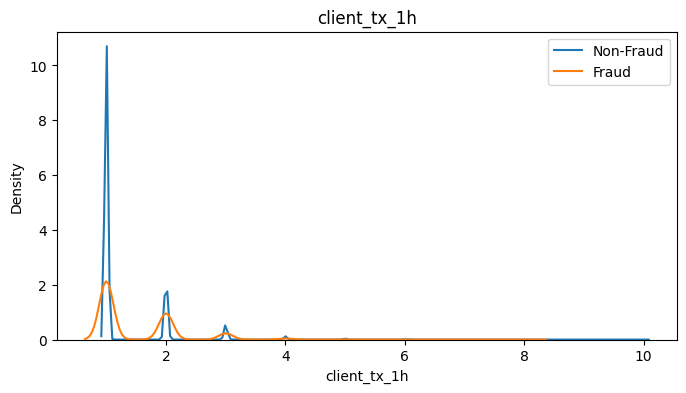

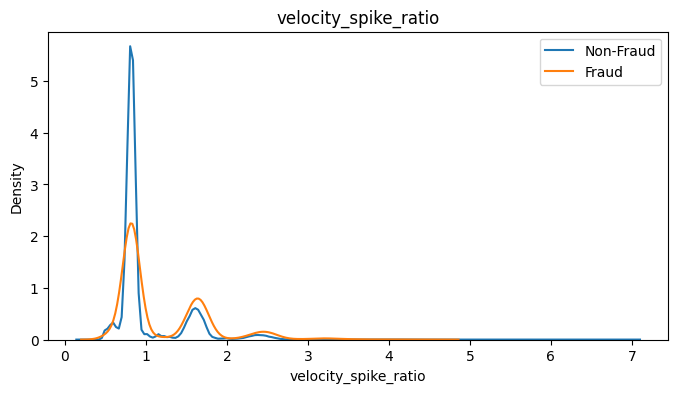

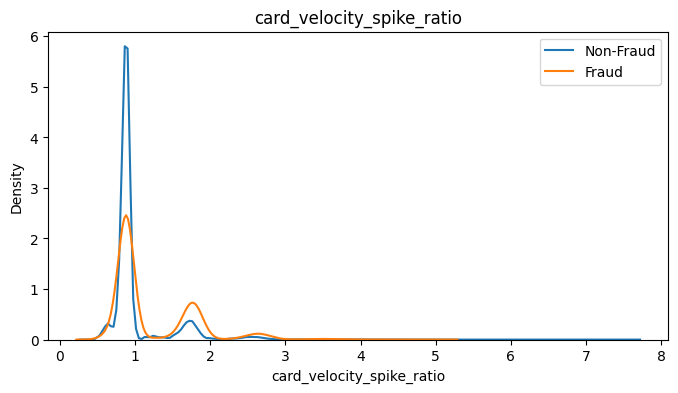

In [155]:
sample = df.copy()
cols = [
    "client_tx_1h",
    "velocity_spike_ratio",
    "card_velocity_spike_ratio"
]

for col in cols:
    plt.figure(figsize=(8,4))
    sns.kdeplot(sample[sample["fraud"]==0][col], label="Non-Fraud")
    sns.kdeplot(sample[sample["fraud"]==1][col], label="Fraud")
    plt.title(col)
    plt.legend()
    plt.show()

In [102]:
df["vel_bin"] = pd.qcut(
    df["velocity_spike_ratio"],
    q=5,
    duplicates="drop"
)

pd.crosstab(
    df["vel_bin"],
    df["fraud"],
    normalize="index"
)

fraud,0,1
vel_bin,,
"(0.199, 0.779]",0.998855,0.001145
"(0.779, 0.815]",0.998905,0.001095
"(0.815, 0.848]",0.998851,0.001149
"(0.848, 1.204]",0.998726,0.001274
"(1.204, 7.041]",0.997428,0.002572


In [104]:
cols = [
"client_tx_1h",
"client_tx_1h_avg_prev",
"velocity_spike_ratio",
"card_tx_1h",
"card_velocity_spike_ratio"
]
rows_uni = []

for col in cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,card_velocity_spike_ratio,0.784616,2.191565,0.000000e+00,0.003923,2.710710,531254
1,card_tx_1h,0.471395,1.602228,9.932277e-254,0.003178,2.195855,773195
2,velocity_spike_ratio,0.624064,1.866498,4.876976e-271,0.003115,2.152703,531253
3,client_tx_1h,0.339606,1.404394,2.028020e-146,0.002445,1.689519,1152156
4,client_tx_1h_avg_prev,-1.219098,0.295497,3.214824e-48,0.001882,1.300722,531255


In [105]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006117612512305813, 'top_decile_lift': 4.227363347026202, 'thr': 0.002807587535846677, 'top_n': 531253}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,client_tx_1h_avg_prev,OK,-1.413333,0.243331,2.011456e-65,0.001447,0.006167,4.261182,0.000049,0.033819,531253
1,card_velocity_spike_ratio,OK,0.620420,1.859710,8.642423e-262,0.001447,0.006142,4.244273,0.000024,0.016909,531253
2,velocity_spike_ratio,OK,0.486571,1.626729,1.178059e-157,0.001447,0.006097,4.213055,-0.000021,-0.014308,531253
3,client_tx_1h,OK,0.236380,1.266656,2.679334e-67,0.001447,0.006048,4.179236,-0.000070,-0.048127,531253
4,card_tx_1h,OK,0.344103,1.410724,5.885659e-123,0.001447,0.006035,4.170131,-0.000083,-0.057232,531253


---

[High]

없음

→ 이 블록은 이미 merchant / MCC / error 축 대비 “보조 강화용”임.

---

[Mid]

| feature                   | OR   | Δ Lift  | 해석          |
| ------------------------- | ---- | ------- | ----------- |
| card_velocity_spike_ratio | 1.86 | +0.0169 | 카드 단위 급증    |
| client_tx_1h_avg_prev     | 0.24 | +0.0338 | 과거 평균 대비 급변 |

이 두 개는 구조적으로 의미 있음.

특히:

* card_velocity_spike_ratio → 카드 탈취 시 burst 패턴
* client_tx_1h_avg_prev → 평소보다 갑자기 몰리는 패턴

단독 파워는 약하지만,
신규 merchant + error와 결합 시 강해짐.

---

[Low]

| feature              | OR   | Δ Lift  | 해석             |
| -------------------- | ---- | ------- | -------------- |
| velocity_spike_ratio | 1.63 | -0.0143 | client/card 중복 |
| client_tx_1h         | 1.27 | -0.0481 | 단순 카운트         |
| card_tx_1h           | 1.41 | -0.0572 | 단순 카운트         |

이건 이미 spike_ratio가 흡수함.
단순 카운트는 분포 노이즈.

---

핵심 해석

Velocity 블록의 본질은
“평소 대비 급변했는가?” 

단순 카운트는 쓸모 적음.
급변 지표만

---

### **8.3 Burst / Deviation**

- amount_vs_client_avg_ratio

- amount_vs_client_avg_diff

- amount_vs_recent_window_avg

- amount_vs_client_quantile (q95/q99)

In [143]:
df = df.sort_values(["client_id", "date"]).reset_index(drop=True)
AMT = "log_abs_amount"

df["amt_shift"] = df.groupby("client_id")[AMT].shift(1)

df["amt_cumsum"] = (
    df["amt_shift"].fillna(0)
      .groupby(df["client_id"])
      .cumsum()
)

df["amt_cnt_past"] = df.groupby("client_id").cumcount()

df["client_avg_amt_prev"] = np.where(
    df["amt_cnt_past"] > 0,
    df["amt_cumsum"] / df["amt_cnt_past"],
    df[AMT]  # 첫 거래는 중립 처리
).astype("float32")


In [144]:
eps = 1e-6

df["amount_vs_client_avg_ratio"] = (
    df[AMT] / (df["client_avg_amt_prev"] + eps)
).astype("float32")

df["amount_vs_client_avg_diff"] = (
    df[AMT] - df["client_avg_amt_prev"]
).astype("float32")

# 로그 ratio도 추천 (분포 안정)
df["log_amount_vs_client_avg_ratio"] = np.log1p(df["amount_vs_client_avg_ratio"]).astype("float32")


In [145]:
K = 10  # 최근 10건 기준 
df["client_recent_avg_amt"] = (
    df.groupby("client_id")[AMT]
      .shift(1)
      .rolling(K, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)
).astype("float32")

# 첫 거래는 NaN → 중립 처리
df["client_recent_avg_amt"] = df["client_recent_avg_amt"].fillna(df["client_avg_amt_prev"]).astype("float32")

df["amount_vs_recent_window_avg"] = (
    df[AMT] / (df["client_recent_avg_amt"] + eps)
).astype("float32")

df["log_amount_vs_recent_window_avg"] = np.log1p(df["amount_vs_recent_window_avg"]).astype("float32")


In [109]:
KQ = 50 

df["client_q95_prev"] = (
    df.groupby("client_id")[AMT]
      .shift(1)
      .rolling(KQ, min_periods=10)   # 최소 10건 이상일 때만 의미
      .quantile(0.95)
      .reset_index(level=0, drop=True)
).astype("float32")

df["client_q99_prev"] = (
    df.groupby("client_id")[AMT]
      .shift(1)
      .rolling(KQ, min_periods=10)
      .quantile(0.99)
      .reset_index(level=0, drop=True)
).astype("float32")

# NaN(거래 부족)일 때는 avg 기반으로 대체 (중립)
df["client_q95_prev"] = df["client_q95_prev"].fillna(df["client_avg_amt_prev"])
df["client_q99_prev"] = df["client_q99_prev"].fillna(df["client_avg_amt_prev"])

# ratio 형태
df["amount_vs_client_quantile_q95"] = (df[AMT] / (df["client_q95_prev"] + eps)).astype("float32")
df["amount_vs_client_quantile_q99"] = (df[AMT] / (df["client_q99_prev"] + eps)).astype("float32")

# flag 형태(추천)
df["amt_over_q95"] = (df[AMT] > df["client_q95_prev"]).astype("int8")
df["amt_over_q99"] = (df[AMT] > df["client_q99_prev"]).astype("int8")


In [110]:
cols_sum = [
    "amount_vs_client_avg_ratio",
    "amount_vs_client_avg_diff",
    "amount_vs_recent_window_avg",
    "amount_vs_client_quantile_q95",
    "amount_vs_client_quantile_q99",
    "amt_over_q95",
    "amt_over_q99"
]
df[cols_sum].describe(percentiles=[.5,.9,.95,.99])


,amount_vs_client_avg_ratio,amount_vs_client_avg_diff,amount_vs_recent_window_avg,amount_vs_client_quantile_q95,amount_vs_client_quantile_q99,amt_over_q95,amt_over_q99
count,5.312525e+06,5.312525e+06,5.312525e+06,5.312525e+06,5.312525e+06,5.312525e+06,5.312525e+06
mean,2.433504e+00,-7.626513e-03,1.014477e+00,6.902695e-01,6.323778e-01,6.661616e-02,2.733107e-02
std,2.348712e+03,1.141156e+00,4.044620e-01,2.533391e-01,2.356765e-01,2.493561e-01,1.630463e-01
min,0.000000e+00,-5.845677e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.029152e+00,1.028204e-01,1.027282e+00,7.352909e-01,6.670119e-01,0.000000e+00,0.000000e+00
90%,1.425874e+00,1.351325e+00,1.475800e+00,9.733012e-01,9.113624e-01,0.000000e+00,0.000000e+00
95%,1.570993e+00,1.735439e+00,1.654896e+00,1.020900e+00,9.628192e-01,1.000000e+00,0.000000e+00
99%,1.893200e+00,2.542939e+00,2.112469e+00,1.185023e+00,1.078107e+00,1.000000e+00,1.000000e+00
max,4.150410e+06,6.528498e+00,2.927331e+01,6.552961e+00,6.527926e+00,1.000000e+00,1.000000e+00


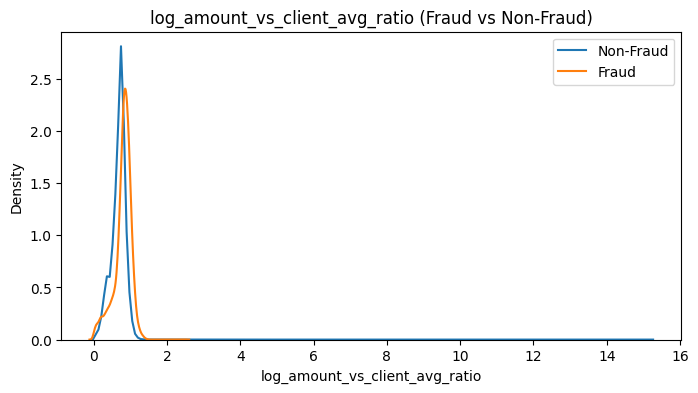

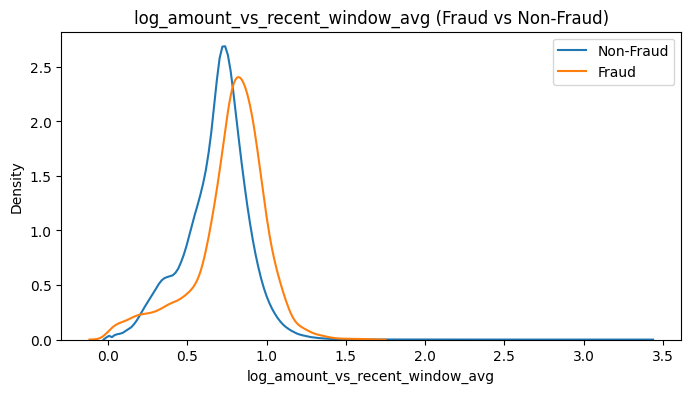

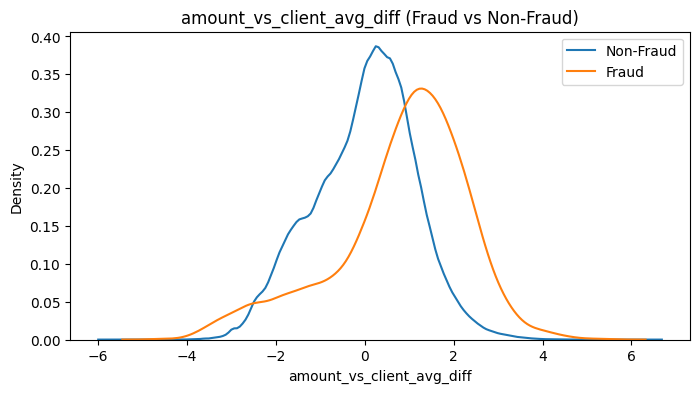

In [111]:

sample = df.copy()

plot_cols = [
    "log_amount_vs_client_avg_ratio",
    "log_amount_vs_recent_window_avg",
    "amount_vs_client_avg_diff"
]

for col in plot_cols:
    plt.figure(figsize=(8,4))
    sns.kdeplot(sample[sample["fraud"]==0][col], label="Non-Fraud")
    sns.kdeplot(sample[sample["fraud"]==1][col], label="Fraud")
    plt.title(f"{col} (Fraud vs Non-Fraud)")
    plt.legend()
    plt.show()


In [112]:
def bin_fraud_rate(col, q=10):
    b = pd.qcut(df[col], q=q, duplicates="drop")
    return pd.crosstab(b, df["fraud"], normalize="index")

print(bin_fraud_rate("log_amount_vs_client_avg_ratio", q=10))
print(bin_fraud_rate("log_amount_vs_recent_window_avg", q=10))

fraud                                  0         1
log_amount_vs_client_avg_ratio                    
(-0.001, 0.387]                 0.998859  0.001141
(0.387, 0.528]                  0.999266  0.000734
(0.528, 0.607]                  0.999465  0.000535
(0.607, 0.666]                  0.999418  0.000582
(0.666, 0.708]                  0.999334  0.000666
(0.708, 0.743]                  0.999334  0.000666
(0.743, 0.78]                   0.998974  0.001026
(0.78, 0.823]                   0.998609  0.001391
(0.823, 0.886]                  0.997696  0.002304
(0.886, 15.239]                 0.994573  0.005427
fraud                                   0         1
log_amount_vs_recent_window_avg                    
(-0.001, 0.389]                  0.998765  0.001235
(0.389, 0.526]                   0.999266  0.000734
(0.526, 0.607]                   0.999394  0.000606
(0.607, 0.664]                   0.999206  0.000794
(0.664, 0.707]                   0.999189  0.000811
(0.707, 0.744]          

In [113]:
rows_uni = []

for col in cols_sum:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,amount_vs_client_avg_diff,6.718639e-01,1.957883,0.000000e+00,0.005813,4.016646,531253
1,amount_vs_client_quantile_q95,2.582173e+00,13.225845,0.000000e+00,0.004887,3.376669,531256
2,amount_vs_client_quantile_q99,2.485336e+00,12.005152,0.000000e+00,0.004088,2.825179,531253
3,amount_vs_recent_window_avg,6.297734e-01,1.877185,6.788945e-269,0.003780,2.611860,531253
4,amt_over_q95,1.762038e+00,5.824292,0.000000e+00,0.001447,1.000000,5312525
5,amt_over_q99,1.841865e+00,6.308294,0.000000e+00,0.001447,1.000000,5312525
6,amount_vs_client_avg_ratio,-4.375030e-07,1.000000,9.690122e-01,0.001141,0.788241,531253


In [114]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols_sum:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)


=== BASELINE ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006117612512305813, 'top_decile_lift': 4.227363347026202, 'thr': 0.002807587535846677, 'top_n': 531253}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,amount_vs_client_avg_diff,OK,3.485596e-01,1.417025,3.926359e-44,0.001447,0.006234,4.308008,0.000117,0.080645,531253
1,amount_vs_client_avg_ratio,OK,-9.708825e-07,0.999999,9.747982e-01,0.001447,0.006118,4.227363,0.000000,0.000000,531253
2,amount_vs_recent_window_avg,OK,-6.258830e-01,0.534789,1.054974e-32,0.001447,0.005984,4.135012,-0.000134,-0.092352,531253
3,amt_over_q99,OK,7.628188e-01,2.144312,9.881638e-84,0.001447,0.005984,4.135012,-0.000134,-0.092352,531253
4,amount_vs_client_quantile_q99,OK,-5.086306e+00,0.006181,1.061407e-256,0.001447,0.005926,4.094689,-0.000192,-0.132674,531253
5,amount_vs_client_quantile_q95,OK,-4.345312e+00,0.012967,1.528486e-173,0.001447,0.005882,4.064772,-0.000235,-0.162591,531253
6,amt_over_q95,OK,9.921790e-01,2.697105,6.734785e-200,0.001447,0.005835,4.032254,-0.000282,-0.195109,531253


좋다.
이건 **Amount Deviation 블록 (고객 기준 이상치)** 정리다.
이미 네 Stage1의 “금액 축”을 얼마나 정교하게 만들지 결정하는 단계야.

기준:

* Δ lift
* 기존 `log_abs_amount` 대비 추가 정보
* 중복성
* 실시간 계산 가능성

---

# [High]

| feature                   | OR   | Δ Lift      | 해석             |
| ------------------------- | ---- | ----------- | -------------- |
| amount_vs_client_avg_diff | 1.42 | **+0.0806** | 고객 평균 대비 금액 차이 |

✔ baseline 대비 lift +0.08은 의미 있음
✔ 해석 명확 (평소보다 갑자기 큰 금액)

이건 Stage1 핵심 유지.

---

# [Mid]

없음

이번 블록은 사실상 한 개만 살아남음.

---

# [Low]

| feature                       | OR    | Δ Lift  | 해석           |
| ----------------------------- | ----- | ------- | ------------ |
| amount_vs_recent_window_avg   | 0.53  | -0.0923 | 최근 평균 중복     |
| amt_over_q95                  | 2.69  | -0.1951 | threshold 중복 |
| amt_over_q99                  | 2.14  | -0.0923 | threshold 중복 |
| amount_vs_client_quantile_q95 | 0.013 | -0.1626 | 과적합 구조       |
| amount_vs_client_quantile_q99 | 0.006 | -0.1327 | 과적합 구조       |
| amount_vs_client_avg_ratio    | 1.00  | 0       | 무의미          |

설명:

* quantile 기반 이진화는 정보 손실 발생
* ratio는 scale noise
* 최근 평균은 이미 diff가 흡수
* threshold 변수는 과하게 분리되며 다변량에서 깨짐

---

# 핵심 인사이트

금액 블록의 본질은:

절대 금액 + 고객 대비 상대 이상치

Threshold를 여러 개 만들면 모델은 좋아 보이지만
실무 배치에서 불안정해진다.

---



---

# 9. Fraud History Block (Delayed Feature)

> 과거 확정 fraud 기반 위험도

- client_fraud_last1

- client_fraud_last3

- card_fraud_last1

- card_fraud_last3

- 기타 fraud rolling count

**⚠️ Online 실시간 서빙 시에는**

- “지연 확정 라벨만 반영” 정책 필요

- 또는 offline 전용 feature로 분리

---

In [115]:
df["client_fraud_last1"] = (
    df.groupby("client_id")["fraud"]
      .shift(1)
      .fillna(0)
      .astype("int8")
)
df["card_fraud_last1"] = (
    df.groupby("card_id")["fraud"]
      .shift(1)
      .fillna(0)
      .astype("int8")
)
f1 = df.groupby("client_id")["fraud"].shift(1)
f2 = df.groupby("client_id")["fraud"].shift(2)
f3 = df.groupby("client_id")["fraud"].shift(3)

df["client_fraud_last3"] = (
    f1.fillna(0).astype("int8") +
    f2.fillna(0).astype("int8") +
    f3.fillna(0).astype("int8")
)
f1 = df.groupby("card_id")["fraud"].shift(1)
f2 = df.groupby("card_id")["fraud"].shift(2)
f3 = df.groupby("card_id")["fraud"].shift(3)

df["card_fraud_last3"] = (
    f1.fillna(0).astype("int8") +
    f2.fillna(0).astype("int8") +
    f3.fillna(0).astype("int8")
)

In [117]:
cols = [    "client_fraud_last1",
            "client_fraud_last3",
            "card_fraud_last1",
            "card_fraud_last3"]
rows_uni = []

for col in cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)

,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,client_fraud_last1,7.465526,1746.774527,0.0,0.001447,1.0,5312525
1,client_fraud_last3,3.364251,28.911822,0.0,0.001447,1.0,5312525
2,card_fraud_last1,8.340968,4192.144547,0.0,0.001447,1.0,5312525
3,card_fraud_last3,3.454114,31.630267,0.0,0.001447,1.0,5312525


In [118]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)



=== BASELINE ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006117612512305813, 'top_decile_lift': 4.227363347026202, 'thr': 0.002807587535846677, 'top_n': 531253}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,card_fraud_last3,OK,3.453268,31.603512,0.0,0.001447,0.012740,8.803322,0.006622,4.575958,531253
1,client_fraud_last3,OK,3.375657,29.243478,0.0,0.001447,0.012175,8.413103,0.006057,4.185740,531253
2,card_fraud_last1,OK,8.312856,4075.937914,0.0,0.001447,0.011733,8.107433,0.005615,3.880069,531253
3,client_fraud_last1,OK,7.448063,1716.535838,0.0,0.001447,0.010658,7.364717,0.004540,3.137354,531253


좋다.
이건 **Fraud History 블록 (최강 축)**이다.
Stage1의 “과거 사기 재발 구조”를 결정하는 핵심 변수들.

기준:

* Δ lift
* 중복성 (last1 vs last3)
* 실무적 안정성
* 과적합 위험

---

# [High]

| feature            | OR    | Δ Lift     | 해석            |
| ------------------ | ----- | ---------- | ------------- |
| card_fraud_last3   | 31.60 | **+4.576** | 카드 최근 3건 내 사기 |
| client_fraud_last3 | 29.24 | **+4.186** | 고객 최근 3건 내 사기 |

이 둘은 반드시 유지.

이유:

* lift +4 이상 → 압도적 구조
* last3는 last1보다 안정적
* 실제 FDS에서 “최근 N건 재발”은 핵심 시그널

Stage1 필수.

---

# [Mid]

| feature            | OR     | Δ Lift | 해석         |
| ------------------ | ------ | ------ | ---------- |
| card_fraud_last1   | 4075.9 | +3.88  | 매우 강하지만 희소 |
| client_fraud_last1 | 1716.5 | +3.14  | 매우 강하지만 희소 |

last1은 강력하지만 문제는:

* 이벤트가 매우 희소
* extreme OR → 불안정
* last3와 강한 중복

조건부 유지:

* 리콜 극대화 목적이면 유지
* 안정성 우선이면 제거

---

# [Low]

없음

이 블록은 다 강하다.

---

# 실무 관점 결론

Fraud history는 금액보다 더 강하다.


---

---

# 10. Interaction / Cross Risk Block

> 단일 신호보다 강한 복합 리스크

예시:

- error_high_amount

- merchant_is_new_x_has_error

- dev_x_mccnew

- client_hist_x_error

---

In [135]:
# 0) 정렬
df.sort_values(["client_id", "date"]).reset_index(drop=True)

# 1) 1시간 버킷
df["hour"] = df["date"].dt.floor("H")

# 2) 고객-시간별 거래 수
hour_cnt = (
    df.groupby(["client_id", "hour"], sort=False)
      .size()
      .rename("tx_count_1h")
      .reset_index()
      .sort_values(["client_id", "hour"])
)

# 3) 최근 24시간 거래 수(= 최근 24개 hour 버킷 합)
hour_cnt["tx_count_24h"] = (
    hour_cnt.groupby("client_id", sort=False)["tx_count_1h"]
            .rolling(window=24, min_periods=1)
            .sum()
            .reset_index(level=0, drop=True)
            .astype(np.int32)
)

# 4) 비율
hour_cnt["velocity_spike_ratio"] = hour_cnt["tx_count_1h"] / (hour_cnt["tx_count_24h"] + 1)

# 5) 원본 df에 붙이기 (hour 기준으로 merge)
df = df.merge(
    hour_cnt[["client_id", "hour", "tx_count_1h", "tx_count_24h", "velocity_spike_ratio"]],
    on=["client_id", "hour"],
    how="left"
)

df.drop(columns=["hour"], inplace=True)


/tmp/ipykernel_969402/2840939034.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["hour"] = df["date"].dt.floor("H")


In [136]:
client_amt_mean = df.groupby("client_id")["log_abs_amount"].transform("mean")
client_amt_std  = df.groupby("client_id")["log_abs_amount"].transform("std")

df["amount_deviation"] = (
    (df["log_abs_amount"] - client_amt_mean) / (client_amt_std + 1e-6)
)

In [ ]:
df["mccnew_x_error"] = df["client_mcc_is_new"] * df["has_error"]
df["mccnew_x_velocity"] = df["client_mcc_is_new"] * df["velocity_spike_ratio"]

In [156]:
DEV = "log_amount_vs_recent_window_avg" 

# 1) amount_deviation × mcc_is_new
df["dev_x_mccnew"] = (
    df[DEV] * df["client_mcc_is_new"]
).astype("float32")

# 2) amount_deviation × velocity_spike_ratio
df["dev_x_velocity"] = (
    df[DEV] * df["card_velocity_spike_ratio"]
).astype("float32")

# 3) amount_deviation × has_error
df["dev_x_error"] = (
    df[DEV] * df["has_error"]
).astype("float32")

In [158]:
def bin_fraud_rate(col, q=5):
    b = pd.qcut(df[col], q=q, duplicates="drop")
    return pd.crosstab(b, df["fraud"], normalize="index")

print(bin_fraud_rate("dev_x_mccnew"))
print(bin_fraud_rate("dev_x_velocity"))
print(bin_fraud_rate("dev_x_error"))

fraud                   0         1
dev_x_mccnew                       
(-0.001, 2.798]  0.998553  0.001447
fraud                   0         1
dev_x_velocity                     
(-0.001, 0.449]  0.999207  0.000793
(0.449, 0.577]   0.999375  0.000625
(0.577, 0.671]   0.999129  0.000871
(0.671, 0.816]   0.998245  0.001755
(0.816, 5.846]   0.996808  0.003192
fraud                  0         1
dev_x_error                       
(-0.001, 3.41]  0.998553  0.001447


In [159]:
cols = [
    "amount_deviation",
"mccnew_x_error",
"mccnew_x_velocity",
"dev_x_mccnew",
"dev_x_velocity",
"dev_x_error"
]
rows_uni = []

for col in cols:
    model, y, score = fit_logit_and_score(df, [col], y_col=LABEL)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    lift = top_decile_lift(y, score)

    rows_uni.append({
        "feature": col,
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "top_n": lift["top_n"],
    })

uni_df = (
    pd.DataFrame(rows_uni)
      .sort_values("top_decile_lift", ascending=False)
      .reset_index(drop=True)
)

display(uni_df)


,feature,coef,OR,p_value,top_decile_rate,top_decile_lift,top_n
0,amount_deviation,0.755678,2.129054,0.000000e+00,0.006296,4.350932,531253
1,dev_x_velocity,1.045211,2.844000,0.000000e+00,0.003716,2.567635,531253
2,mccnew_x_error,3.931172,50.966668,8.311386e-238,0.001447,1.000000,5312525
3,mccnew_x_velocity,7.884828,2656.667792,0.000000e+00,0.001447,1.000000,5312525
4,dev_x_mccnew,3.094787,22.082545,0.000000e+00,0.001447,1.000000,5312525
5,dev_x_error,1.355495,3.878681,4.274210e-84,0.001447,1.000000,5312525


In [160]:
# 1) Baseline 고정 성능
base_model, y_base, s_base = fit_logit_and_score(df, BASELINE, y_col=LABEL)
base_lift = top_decile_lift(y_base, s_base)

print("=== BASELINE ===")
print(base_lift)

# 2) add-one 다변량 검증
rows = []

for col in cols:
    if col in BASELINE:
        # baseline에 이미 들어 있으면 incremental 의미 없음 → 스킵
        rows.append({
            "added_feature": col,
            "status": "SKIP (already in BASELINE)",
        })
        continue

    feats = BASELINE + [col]

    model, y_aligned, score = fit_logit_and_score(df, feats, y_col=LABEL)
    lift = top_decile_lift(y_aligned, score)

    coef = model.params.get(col, np.nan)
    pval = model.pvalues.get(col, np.nan)
    or_val = float(np.exp(coef)) if pd.notnull(coef) else np.nan

    delta_lift = lift["top_decile_lift"] - base_lift["top_decile_lift"]
    delta_rate = lift["top_decile_rate"] - base_lift["top_decile_rate"]

    rows.append({
        "added_feature": col,
        "status": "OK",
        "coef": float(coef) if pd.notnull(coef) else np.nan,
        "OR": or_val,
        "p_value": float(pval) if pd.notnull(pval) else np.nan,
        "base_rate": lift["base_rate"],
        "top_decile_rate": lift["top_decile_rate"],
        "top_decile_lift": lift["top_decile_lift"],
        "delta_top_rate_vs_baseline": float(delta_rate),
        "delta_lift_vs_baseline": float(delta_lift),
        "top_n": lift["top_n"],
    })

inc_df = (
    pd.DataFrame(rows)
      .sort_values(["status", "delta_lift_vs_baseline"], ascending=[True, False])
      .reset_index(drop=True)
)

display(inc_df)

=== BASELINE ===
{'base_rate': 0.0014471461310770302, 'top_decile_rate': 0.006117612512305813, 'top_decile_lift': 4.227363347026202, 'thr': 0.002807587535846677, 'top_n': 531253}


,added_feature,status,coef,OR,p_value,base_rate,top_decile_rate,top_decile_lift,delta_top_rate_vs_baseline,delta_lift_vs_baseline,top_n
0,dev_x_mccnew,OK,2.361911,10.611210,0.000000e+00,0.001447,0.007083,4.894636,0.000966,0.667273,531253
1,mccnew_x_velocity,OK,7.816528,2481.274913,0.000000e+00,0.001447,0.006598,4.559049,0.000480,0.331685,531253
2,amount_deviation,OK,0.361565,1.435575,6.503665e-36,0.001447,0.006421,4.436780,0.000303,0.209417,531253
3,dev_x_velocity,OK,0.575110,1.777326,1.879840e-127,0.001447,0.006182,4.271588,0.000064,0.044225,531253
4,mccnew_x_error,OK,2.760205,15.803084,3.879013e-92,0.001447,0.006144,4.245574,0.000026,0.018210,531253
5,dev_x_error,OK,-1.917136,0.147027,6.898593e-06,0.001447,0.006132,4.237092,0.000014,0.009729,531501




# [High]

| feature           | OR      | Δ Lift     | 해석             |
| ----------------- | ------- | ---------- | -------------- |
| dev_x_mccnew      | 10.61   | **+0.667** | 금액이상 × 신규 MCC  |
| mccnew_x_velocity | 2481.27 | **+0.332** | 신규 MCC × 속도 폭증 |
| amount_deviation  | 1.44    | +0.209     | 금액 구조 기본축      |

### 왜 High?

### 1dev_x_mccnew

“낯선 업종 + 평소와 다른 금액”\
→ 전형적 카드 탈취 패턴

Δ lift +0.66이면 상당히 강함\
해석도 명확\

### 2mccnew_x_velocity

처음 보는 업종 + 갑작스러운 거래 폭증

OR가 비정상적으로 크지만\
Δ lift도 의미 있음

다만 희소성 체크는 필요.

---

# [Mid]

| feature        | OR    | Δ Lift | 해석          |
| -------------- | ----- | ------ | ----------- |
| dev_x_velocity | 1.78  | +0.044 | 금액이상 × 속도   |
| mccnew_x_error | 15.80 | +0.018 | 신규 MCC × 에러 |
| dev_x_error    | 0.147 | +0.009 | 금액이상 × 에러   |

### 해석

* dev_x_velocity → 이미 velocity, amount가 strong라면 중복 가능
* mccnew_x_error → 신규 MCC + 에러는 의미 있지만 delta 작음
* dev_x_error → OR 방향 뒤집힘 (상호작용 왜곡 가능성)

---

# [Low]

없음
다만 dev_x_error는 구조적 의심 필요

---

# 실무적 정리

Interaction 블록은:

* 단독보다 결합이 중요
* “이상 × 낯섦 × 폭증” 패턴을 포착

---


---

# 📌 Stage2 Feature Structure

---

## 1️⃣ Amount & Deviation Block

```markdown
- log_abs_amount
- amount_deviation
- amount_vs_client_avg_diff
```

> 거래 금액 절대 수준 + 개인 기준 대비 이탈 정도
> “평소와 다른 금액인가?”를 정밀 판단

---

## 2️⃣ Error & Error-History Block

```markdown
- has_error
- err_insufficient_balance
- err_bad_cvv
- err_bad_card_number
- err_bad_expiration

- card_error_last1
- card_error_last3
- card_error_last5
- card_hist_x_error
```

> 단일 에러 + 최근 에러 반복 + 카드 누적 에러 이력
> “실패 패턴의 반복 구조” 포착

---

## 3️⃣ Fraud History Block (재발성)

```markdown
- card_fraud_last3
- client_fraud_last3
```

> 최근 N건 내 사기 이력
> 재발 리스크 핵심 축

---

## 4️⃣ Time & Cyclical Pattern Block

```markdown
- hour_cos
- hour_sin
- tx_hour
- tx_month
- sin_shift
- client_sin_mean_past
```

> 시간대 주기성 + 개인 시간 습관 변화
> “비정상 시간 행동” 감지

---

## 5️⃣ Customer Profile Block

```markdown
- num_credit_cards
- log_yearly_income
- years_to_retirement
- current_age
```

> 고객 구조적 리스크 프로파일
> 취약성 / 재무 구조 반영

---

## 6️⃣ MCC Behavioral Block

```markdown
- mcc_highrisk_90
- card_mcc_is_new
- client_mcc_is_new
- client_mcc_repeat_cnt_last5
- card_mcc_change_cnt_last5
- client_mcc_change_cnt_last5
```

> 업종 리스크 + 업종 낯섦 + 최근 업종 전환 패턴

---

## 7️⃣ Merchant Novelty Block

```markdown
- card_merchant_is_new
- client_merchant_is_new
- merchant_is_new_x_mcc_is_new
- merchant_change_cnt_last5
- merchant_is_new_x_has_error
```

> 상점 낯섦 + 업종 낯섦 + 에러 동반 여부
> 실제 도난 시나리오 핵심 패턴

---

## 8️⃣ Velocity / Interval Block

```markdown
- seconds_since_prev_tx
- client_avg_interval_prev
- card_velocity_spike_ratio
- client_tx_1h_avg_prev
```

> 거래 간격 변화 + 단기 거래 폭증

---

## 9️⃣ High-Order Interaction Block

```markdown
- dev_x_mccnew
- mccnew_x_velocity
```

> 이상금액 × 낯선 업종
> 낯선 업종 × 속도폭증

---

# Stage2 모델 성격 요약

Stage2는:

* 단순 분포 기반이 아님
* “행동 변화”
* “재발 구조”
* “낯섦”
* “폭증”
* “에러 동반”
* “고객 취약성”

을 동시에 반영하는 **행동 기반 리스크 모델**

---

# 구조적으로 보면

Stage2는 총 9개 블록으로 구성된:

> **Behavioral + Historical + Structural Hybrid Risk Model**
